In [ ]:
# === Single Jupyter Cell: Signature -> NNLS deconv (train eval + test prediction), Windows-friendly (no scikit-misc) ===
# Paths (edit as needed)
TRAIN_ADATA = r"../train_data/train_adata.h5ad"
TRAIN_BULK  = r"../train_data/train_bulk.csv"
TRAIN_TRUE  = r"../train_data/train_bulk_trueprops.csv"
TEST_BULK   = r"../test_data/test_bulk.csv"
OUT_CSV     = r"outputs/pred_props.csv"  # writes test predictions

CELLTYPE_COL = "highLevelType"  # fallback: 'cell_type'
HVG_N = 3000
HVG_FLAVOR = "cell_ranger"  # <- Windows-safe; or "seurat" (requires statsmodels), avoid "seurat_v3"
MIN_CELLS_PER_TYPE = 20
MIN_SHARED_GENES = 200

from typing import Tuple, List
import os
import numpy as np
import pandas as pd

TARGET_ORDER = ["T","B","Endothelial","Fibroblast","Plasmablast","Myofibroblast","NK","Myeloid","Mast"]

def _need_scanpy():
    try:
        import scanpy as sc
        return sc
    except Exception as e:
        raise RuntimeError("請先安裝：pip install scanpy anndata scipy numpy pandas") from e

def _read_bulk(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, index_col=0)
    if df.empty:
        raise ValueError(f"Empty bulk file: {path}")
    return df  # rows: genes, cols: samples

def _prep_bulk_logcpm(df: pd.DataFrame) -> pd.DataFrame:
    col_sums = df.sum(axis=0)
    col_sums[col_sums == 0] = 1.0
    df_cpm = df.div(col_sums, axis=1) * 1e4
    return np.log1p(df_cpm)

def _align_genes(signature: pd.DataFrame, bulk: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    common = signature.index.intersection(bulk.index)
    if len(common) < MIN_SHARED_GENES:
        raise ValueError(f"共享基因過少：{len(common)} < {MIN_SHARED_GENES}")
    return signature.loc[common], bulk.loc[common]

def _nnls(S: pd.DataFrame, y: np.ndarray) -> np.ndarray:
    from scipy.optimize import nnls
    w, _ = nnls(S.values, y)
    w = np.maximum(w, 0)
    s = w.sum()
    return (np.ones_like(w) / len(w)) if s <= 0 else (w / s)  # why: enforce simplex, avoid degenerate

def _build_signature_from_sc(
    ad_path: str,
    celltype_col: str = CELLTYPE_COL,
    hvg_n: int = HVG_N,
    hvg_flavor: str = HVG_FLAVOR,
    min_cells_per_type: int = MIN_CELLS_PER_TYPE,
) -> pd.DataFrame:
    sc = _need_scanpy()
    adata = sc.read_h5ad(ad_path)

    if celltype_col not in adata.obs:
        if "cell_type" in adata.obs: celltype_col = "cell_type"
        else: raise KeyError(f"找不到 '{celltype_col}' 或 'cell_type' 於 adata.obs")

    # Basic QC + normalization (match bulk transform later)
    sc.pp.filter_cells(adata, min_genes=200)
    sc.pp.filter_genes(adata, min_cells=3)
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

    # Windows-friendly HVG (no scikit-misc)
    # - "cell_ranger": simple mean-variance trend, fast, no extra deps
    # - "seurat": uses statsmodels.lowess (pip install statsmodels)
    sc.pp.highly_variable_genes(adata, n_top_genes=hvg_n, flavor=hvg_flavor)
    adata = adata[:, adata.var.highly_variable].copy()

    # Drop rare types for stable means
    vc = adata.obs[celltype_col].value_counts()
    keep_ct = vc[vc >= min_cells_per_type].index.tolist()
    if not keep_ct:
        raise ValueError("所有 cell types 都低於 min_cells_per_type；請調小門檻")
    adata = adata[adata.obs[celltype_col].isin(keep_ct)].copy()

    # Mean profile per cell type
    cols = []
    for ct in sorted(keep_ct):
        m = np.asarray(adata[adata.obs[celltype_col] == ct].X.mean(axis=0)).ravel()
        cols.append(pd.Series(m, index=adata.var_names, name=ct))
    sig = pd.concat(cols, axis=1)  # genes x present_ct

    # Column L2 normalize (why: reduce scale differences)
    sig = sig.apply(lambda c: c / (np.linalg.norm(c.values) + 1e-12), axis=0)
    return sig

def _reindex_signature_9(sig: pd.DataFrame) -> pd.DataFrame:
    present = [c for c in TARGET_ORDER if c in sig.columns]
    missing = [c for c in TARGET_ORDER if c not in sig.columns]
    S = sig[present].copy() if present else pd.DataFrame(index=sig.index)
    if missing:
        zeros = pd.DataFrame(0.0, index=sig.index, columns=missing)
        S = pd.concat([S, zeros], axis=1)
    return S[TARGET_ORDER]

def _eval_rmse_per_type(pred: pd.DataFrame, truth: pd.DataFrame) -> tuple[pd.Series, float]:
    rmse_ct = ((pred - truth) ** 2).mean(axis=1).pow(0.5)
    return rmse_ct, float(rmse_ct.mean())

# 0) Ensure outdir
# os.makedirs(os.path.dirname(OUT_CSV), exist_ok=True)

# 1) Signature
signature_raw = _build_signature_from_sc(TRAIN_ADATA, celltype_col=CELLTYPE_COL, hvg_flavor=HVG_FLAVOR)
S9 = _reindex_signature_9(signature_raw)
print("[Signature] present types:", [c for c in TARGET_ORDER if (S9[c].abs().sum() > 0)])
miss = [c for c in TARGET_ORDER if (S9[c].abs().sum() == 0)]
if miss: print("[Signature] missing (zero-filled):", miss)
print("Signature shape:", S9.shape)

# 2) Train bulk prep + align
Btr_raw = _read_bulk(TRAIN_BULK)
Btr = _prep_bulk_logcpm(Btr_raw)
S_tr, B_tr = _align_genes(S9, Btr)
print("Shared genes (train):", S_tr.shape[0], "| train samples:", list(B_tr.columns))

# 3) NNLS on train
P_train = pd.DataFrame(
    np.column_stack([_nnls(S_tr, B_tr[s].values) for s in B_tr.columns]),
    index=TARGET_ORDER, columns=B_tr.columns
)

# 4) Evaluate on train
true_tr = pd.read_csv(TRAIN_TRUE, index_col=0)
for ct in TARGET_ORDER:
    if ct not in true_tr.index: true_tr.loc[ct] = 0.0
true_tr = true_tr.loc[TARGET_ORDER, B_tr.columns]
rmse_ct, avg_rmse = _eval_rmse_per_type(P_train, true_tr)
print("\n=== Train RMSE per cell type ===")
print(rmse_ct.round(4).to_string())
print(f"\nAverage RMSE across 9 types: {avg_rmse:.4f}")

# 5) Test bulk prep + align
Bte_raw = _read_bulk(TEST_BULK)
Bte = _prep_bulk_logcpm(Bte_raw)
S_te, B_te = _align_genes(S9, Bte)
print("\nShared genes (test):", S_te.shape[0], "| test samples:", list(B_te.columns))

# 6) NNLS on test -> pred_props.csv
P_test = pd.DataFrame(
    np.column_stack([_nnls(S_te, B_te[s].values) for s in B_te.columns]),
    index=TARGET_ORDER, columns=B_te.columns
)
P_test.index.name = "index"
# P_test.to_csv(OUT_CSV)
print(f"\n[OK] wrote test predictions: {OUT_CSV}")
print("\n(pred_props head)")
print(P_test.iloc[:, :min(5, P_test.shape[1])].round(4).to_string())


[Signature] present types: ['T', 'B', 'Endothelial', 'Fibroblast', 'Plasmablast', 'Myofibroblast', 'NK', 'Myeloid', 'Mast']
Signature shape: (3000, 9)
Shared genes (train): 3000 | train samples: ['s1_0', 's1_1', 's2_0', 's2_1', 's3_0', 's3_1', 's4_0', 's4_1', 's7_0', 's7_1', 's8_0', 's8_1']

=== Train RMSE per cell type ===
T                0.3421
B                0.0565
Endothelial      0.0323
Fibroblast       0.1503
Plasmablast      0.1950
Myofibroblast    0.0677
NK               0.0884
Myeloid          0.0667
Mast             0.0882

Average RMSE across 9 types: 0.1208

Shared genes (test): 3000 | test samples: ['s5_0', 's5_1', 's5_2', 's5_3', 's5_4', 's6_0', 's6_1', 's6_2', 's6_3', 's6_4', 's9_0', 's9_1', 's9_2', 's9_3', 's9_4', 's10_0', 's10_1', 's10_2', 's10_3', 's10_4']

[OK] wrote test predictions: outputs/pred_props.csv

(pred_props head)
                 s5_0    s5_1    s5_2    s5_3    s5_4
index                                                
T              0.1891  0.2482  0

=== Quick reminder ===
Signature = mean expression per cell type (group by obs['highLevelType']) using X; genes from var_names.
obs: cell-level metadata (has 'Sample', 'highLevelType'); var: gene-level metadata; X: expression matrix.

=== AnnData (Sample==s1) subset ===
cells: 6821 | genes: 7725
obs columns: ['Sample', 'Patient', 'Tumor status', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'highLevelType', 'chemo']

[obs head - s1]
                     Sample Patient Tumor status  n_genes  n_genes_by_counts  total_counts  total_counts_mt  pct_counts_mt highLevelType chemo
AAACCCAAGGAGACCT-1_1     s1      P1        Tumor      991                991        2156.0            131.0       6.076067             T  post
AAACCCAGTAGACAGC-1_1     s1      P1        Tumor     1063               1063        2485.0             84.0       3.380282             T  post
AAACCCAGTAGATCGG-1_1     s1      P1        Tumor      855                855        1993.0      

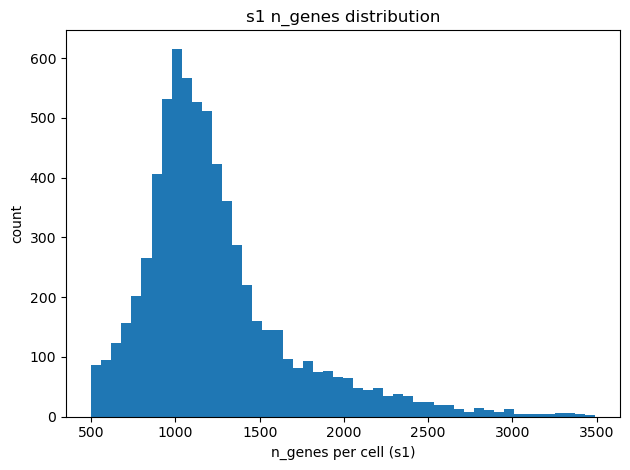

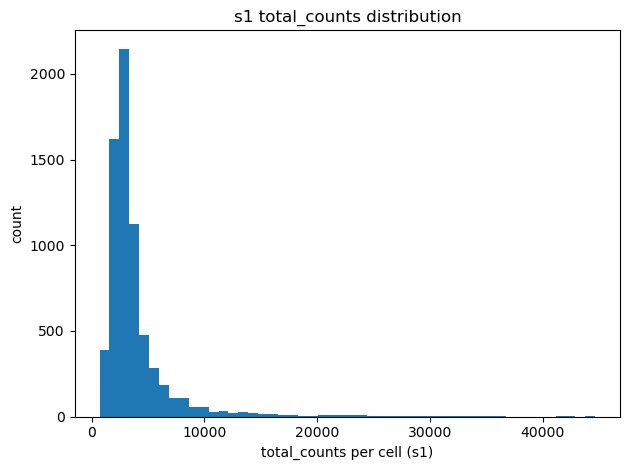


=== s1 cell-type counts ===
highLevelType
T                3934
B                1393
Myeloid           444
NK                312
Plasmablast       266
Fibroblast        200
Mast              180
Myofibroblast      58
Endothelial        34


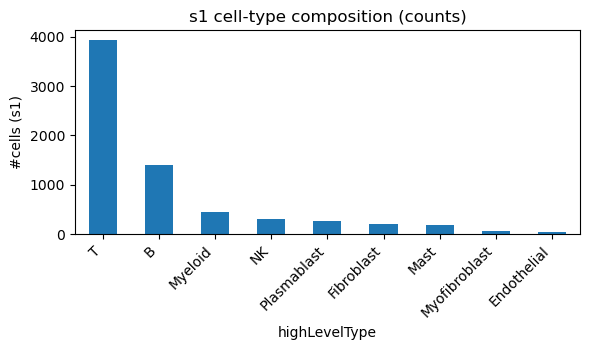


[Signature demo] genes x celltypes: (7725, 9)
cell types: ['B', 'Endothelial', 'Fibroblast', 'Mast', 'Myeloid', 'Myofibroblast', 'NK', 'Plasmablast', 'T']

=== Bulk: s1 columns ===
['s1_0', 's1_1']

[Bulk total counts for s1_*]
s1_0    5195874.0
s1_1    8718035.0


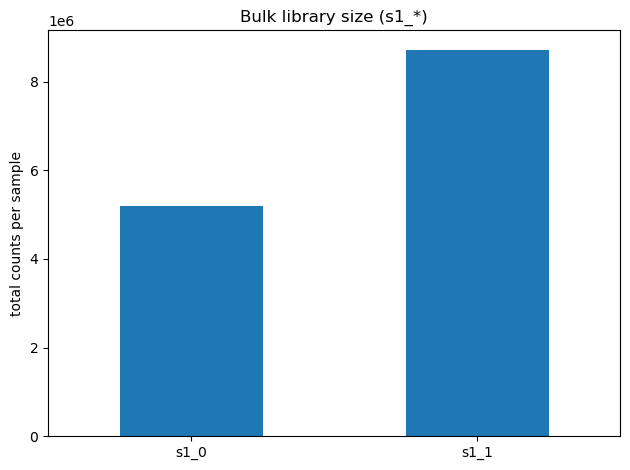


[True proportions for s1_*]
                 s1_0    s1_1
highLevelType                
T              0.5686  0.3592
Fibroblast     0.1052  0.1307
NK             0.0732  0.1366
Myeloid        0.0647  0.0210
Mast           0.0597  0.0381
B              0.0498  0.0794
Myofibroblast  0.0412  0.0381
Endothelial    0.0242  0.0223
Plasmablast    0.0135  0.1747

[Check sum per column]
s1_0    1.0
s1_1    1.0


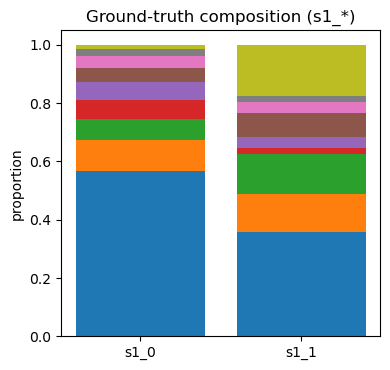

In [15]:
# Jupyter cell: What is a single-cell signature + pull everything for Sample s1 (no file saves)
AD_PATH    = r"../train_data/train_adata.h5ad"
BULK_PATH  = r"../train_data/train_bulk.csv"
TRUE_PATH  = r"../train_data/train_bulk_trueprops.csv"

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- anndata loader ---
def _load_adata(path):
    try:
        import anndata as ad
    except Exception as e:
        raise RuntimeError("請先安裝 anndata：pip install anndata scanpy scipy pandas numpy") from e
    return ad.read_h5ad(path)

adata = _load_adata(AD_PATH)
bulk  = pd.read_csv(BULK_PATH, index_col=0)
truep = pd.read_csv(TRUE_PATH, index_col=0)

print("=== Quick reminder ===")
print("Signature = mean expression per cell type (group by obs['highLevelType']) using X; genes from var_names.")
print("obs: cell-level metadata (has 'Sample', 'highLevelType'); var: gene-level metadata; X: expression matrix.\n")

# ---- pick Sample s1 (robust to 's1'/'s_1'/'S1'/'S_1') ----
sample_col = "Sample"
if sample_col not in adata.obs.columns:
    raise KeyError(f"找不到 {sample_col} 於 adata.obs")

def _is_s1(val: str) -> bool:
    v = str(val).lower()
    return v in {"s1","s_1","p1"} or bool(re.fullmatch(r"s[_\-]?1", v))

mask_s1 = adata.obs[sample_col].apply(_is_s1).values
adata_s1 = adata[mask_s1].copy()

print("=== AnnData (Sample==s1) subset ===")
print(f"cells: {adata_s1.n_obs} | genes: {adata_s1.n_vars}")
print("obs columns:", list(adata_s1.obs.columns))
print("\n[obs head - s1]")
print(adata_s1.obs.head(8).to_string())

# ---- QC plots for s1 ----
def _is_sparse(x):
    try:
        from scipy import sparse
        return sparse.issparse(x)
    except Exception:
        return False

def _sum_axis1(X):
    if _is_sparse(X): return np.asarray(X.sum(axis=1)).ravel()
    return np.sum(X, axis=1)

def _nnz_axis1(X):
    if _is_sparse(X):
        return np.diff(X.indptr) if hasattr(X, "indptr") else np.count_nonzero(X.toarray(), axis=1)
    return np.count_nonzero(X, axis=1)

print("\n=== QC (s1 cells) ===")
if {"n_genes","total_counts"}.issubset(adata_s1.obs.columns):
    n_genes = adata_s1.obs["n_genes"].to_numpy()
    total_counts = adata_s1.obs["total_counts"].to_numpy()
else:
    n_genes = _nnz_axis1(adata_s1.X)
    total_counts = _sum_axis1(adata_s1.X)
qc = pd.DataFrame({"n_genes": n_genes, "total_counts": total_counts})
print(qc.describe().round(2).to_string())

plt.figure()
plt.hist(qc["n_genes"], bins=50)
plt.xlabel("n_genes per cell (s1)"); plt.ylabel("count"); plt.title("s1 n_genes distribution")
plt.tight_layout(); plt.show()

plt.figure()
plt.hist(qc["total_counts"], bins=50)
plt.xlabel("total_counts per cell (s1)"); plt.ylabel("count"); plt.title("s1 total_counts distribution")
plt.tight_layout(); plt.show()

# ---- Cell-type composition within s1 ----
ct_col = "highLevelType" if "highLevelType" in adata_s1.obs.columns else None
if ct_col:
    ct_counts = adata_s1.obs[ct_col].value_counts().sort_values(ascending=False)
    print("\n=== s1 cell-type counts ===")
    print(ct_counts.to_string())

    plt.figure(figsize=(6,3.6))
    ct_counts.plot(kind="bar")
    plt.ylabel("#cells (s1)"); plt.title("s1 cell-type composition (counts)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout(); plt.show()

# ---- Build a small signature demo from ALL train cells (not only s1) ----
# why: signature應該用所有訓練細胞建立；這裡只示範怎麼算
if ct_col:
    cts = sorted(adata.obs[ct_col].astype(str).unique())
    cols = []
    for c in cts:
        idx = (adata.obs[ct_col].astype(str) == c).values
        m = np.asarray(adata.X[idx].mean(axis=0)).ravel()
        cols.append(pd.Series(m, index=adata.var_names.astype(str), name=c))
    S_demo = pd.concat(cols, axis=1)  # genes × celltypes
    print("\n[Signature demo] genes x celltypes:", S_demo.shape)
    print("cell types:", list(S_demo.columns))

# ---- Pull bulk columns for s1 (s1_0, s1_1) + true props ----
bulk_cols_s1 = [c for c in bulk.columns if re.match(r"^s[_\-]?1_([01]|[A-Za-z0-9]+)$", c)]
if not bulk_cols_s1:
    # fallback: any column starting with 's1'
    bulk_cols_s1 = [c for c in bulk.columns if str(c).lower().startswith("s1")]

print("\n=== Bulk: s1 columns ===")
print(bulk_cols_s1 if bulk_cols_s1 else "(none found)")

if bulk_cols_s1:
    sums = bulk[bulk_cols_s1].sum(axis=0).sort_index()
    print("\n[Bulk total counts for s1_*]")
    print(sums.to_string())

    plt.figure()
    sums.plot(kind="bar")
    plt.ylabel("total counts per sample"); plt.title("Bulk library size (s1_*)")
    plt.xticks(rotation=0)
    plt.tight_layout(); plt.show()

    # true proportions for s1_* (if present)
    true_cols = [c for c in truep.columns if c in set(bulk_cols_s1)]
    if true_cols:
        tp = truep.loc[:, true_cols]
        print("\n[True proportions for s1_*]")
        print(tp.round(4).to_string())
        # check sum=1
        print("\n[Check sum per column]")
        print((tp.sum(axis=0)).round(6).to_string())
        # simple stacked bar for visual
        plt.figure(figsize=(max(4, 1.2*len(true_cols)), 3.8))
        bottom = np.zeros(len(true_cols))
        for ct in tp.index:
            plt.bar(true_cols, tp.loc[ct].values, bottom=bottom)
            bottom += tp.loc[ct].values
        plt.ylabel("proportion"); plt.title("Ground-truth composition (s1_*)")
        plt.xticks(rotation=0)
        plt.tight_layout(); plt.show()
    else:
        print("\n(no true proportion columns for s1_* were found in train_bulk_trueprops.csv)")


=== Bulk matrix ===
path: ../train_data/train_bulk.csv
shape: genes=7725 × samples=12
samples: ['s1_0', 's1_1', 's2_0', 's2_1', 's3_0', 's3_1', 's4_0', 's4_1', 's7_0', 's7_1', 's8_0', 's8_1']

=== Total gene counts per sample (descending) ===
      total_counts  percent_of_all
s1_1     8718035.0          13.442
s7_1     6442387.0           9.934
s7_0     6304551.0           9.721
s3_0     5738087.0           8.848
s4_0     5376201.0           8.290
s1_0     5195874.0           8.012
s8_0     5099314.0           7.863
s4_1     4788627.0           7.384
s3_1     4469142.0           6.891
s2_1     4310151.0           6.646
s8_1     4286059.0           6.609
s2_0     4126009.0           6.362

[Stats of total_counts]
count         12.00
mean     5404536.42
std      1295194.03
min      4126009.00
25%      4429394.25
50%      5147594.00
75%      5879703.00
max      8718035.00


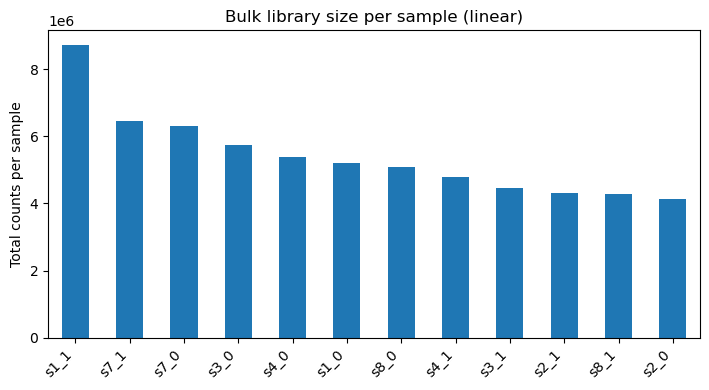

In [ ]:
# Jupyter cell: Inspect bulk counts per sample (no file saves)
BULK_PATH = r"../train_data/train_bulk.csv"  # 改成你的路徑

import numpy as np
import pandas as pd
import matplotlib.pyplot as pltq

# 1) 讀檔
bulk = pd.read_csv(BULK_PATH, index_col=0)
print("=== Bulk matrix ===")
print(f"path: {BULK_PATH}")
print(f"shape: genes={bulk.shape[0]} × samples={bulk.shape[1]}")
print("samples:", list(bulk.columns))

# 2) 數值化 + 缺值檢查
bulk_num = bulk.apply(pd.to_numeric, errors="coerce")
na_per_col = bulk_num.isna().sum()
if na_per_col.any():
    print("\n[WARN] NaNs detected per sample (top >0):")
    print(na_per_col[na_per_col > 0].sort_values(ascending=False).to_string())
    # 對加總不致命，NaN 以 0 處理
    bulk_num = bulk_num.fillna(0)

# 3) 每個 sample 的基因總計數（library size）
col_sums = bulk_num.sum(axis=0).sort_values(ascending=False)
total_all = float(col_sums.sum())

print("\n=== Total gene counts per sample (descending) ===")
summary = pd.DataFrame({
    "total_counts": col_sums,
    "percent_of_all": (col_sums / total_all * 100.0)
})
print(summary.round({"total_counts": 2, "percent_of_all": 3}).to_string())

print("\n[Stats of total_counts]")
print(col_sums.describe().round(2).to_string())

# 4) 圖：bar（線性）+ 若動態範圍很大，再補一張 log10
plt.figure(figsize=(max(6, 0.6*len(col_sums)), 4))
col_sums.plot(kind="bar")
plt.ylabel("Total counts per sample")
plt.title("Bulk library size per sample (linear)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

rng = col_sums.max() / max(col_sums.min(), 1.0)
if rng > 50:  # 動態範圍很大時，加一張 log 視圖更好讀
    plt.figure(figsize=(max(6, 0.6*len(col_sums)), 4))
    np.log10(col_sums).plot(kind="bar")
    plt.ylabel("log10(total counts)")
    plt.title("Bulk library size per sample (log10)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()



=== LOPO + inner K-fold — mean-in-simplex | ScanpyHVU (per-CT HVG) ===
HVG TopK/CT = 200 | INNER folds up to 5
Total test samples evaluated = 12
Avg RMSE = 0.0475

Per-CT RMSE:
T                0.0907
B                0.0657
Endothelial      0.0244
Fibroblast       0.0272
Plasmablast      0.0176
Myofibroblast    0.0297
NK               0.0786
Myeloid          0.0510
Mast             0.0427

=== Per-Patient × Per-CT RMSE ===
         T       B  Endothelial  Fibroblast  Plasmablast  Myofibroblast      NK  Myeloid    Mast
P1  0.0405  0.0295       0.0017      0.0465       0.0038         0.0195  0.0184   0.0289  0.0184
P2  0.0839  0.0222       0.0043      0.0121       0.0293         0.0332  0.0523   0.0611  0.0930
P3  0.0435  0.0425       0.0182      0.0203       0.0199         0.0340  0.0879   0.0301  0.0219
P4  0.1745  0.0491       0.0033      0.0346       0.0074         0.0048  0.1457   0.0778  0.0266
P7  0.0648  0.1007       0.0400      0.0163       0.0165         0.0364  0.0504   0.04

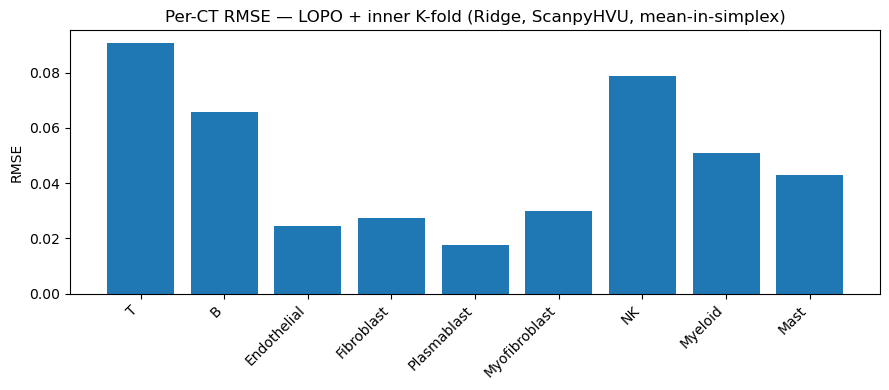

In [53]:
# Jupyter cell: LOPO (outer) + inner K-fold with Ridge(alpha=1e-2)
# 固定：ScanpyHVU (per-CT seurat_v3 HVG Top-K union) + 測試端 "mean in simplex"
AD_PATH    = r"../train_data/train_adata.h5ad"
BULK_PATH  = r"../train_data/train_bulk.csv"
TRUE_PATH  = r"../train_data/train_bulk_trueprops.csv"

CELLTYPE_COL   = "highLevelType"
TARGET_ORDER   = ["T","B","Endothelial","Fibroblast","Plasmablast","Myofibroblast","NK","Myeloid","Mast"]
HVG_TOPK_CT    = 200        # 每個 CT 的 HVG Top-K（scanpy）→ union 當特徵
INNER_N_FOLDS  = 5
SEED           = 42

import re, numpy as np, pandas as pd, matplotlib.pyplot as plt
from typing import List, Dict, Tuple
from sklearn.model_selection import KFold
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge
import warnings
warnings.filterwarnings("ignore")

# ------------ utils ------------
def need_scanpy():
    import scanpy as sc
    return sc

def preprocess_sc(ad):
    sc = need_scanpy()
    sc.pp.normalize_total(ad, target_sum=1e4)
    sc.pp.log1p(ad)

def cpm_log1p_bulk(df: pd.DataFrame) -> pd.DataFrame:
    lib = df.sum(axis=0); lib[lib==0]=1.0
    return np.log1p(df.div(lib, axis=1) * 1e4)

def parse_sample_from_bulk_col(col: str) -> str:
    m = re.match(r"^(s\d+)", str(col).lower())
    return m.group(1) if m else str(col)

def simplex_proj(v: np.ndarray) -> np.ndarray:
    # 精確投影到 simplex（sum=1, >=0）
    u = np.sort(v)[::-1]
    cssv = np.cumsum(u)
    rho = np.nonzero(u * np.arange(1, len(u)+1) > (cssv - 1))[0][-1]
    theta = (cssv[rho] - 1) / (rho + 1.0)
    return np.maximum(v - theta, 0.0)

# ILR
def helmert_basis(K: int) -> np.ndarray:
    H = np.zeros((K, K-1))
    for i in range(1, K):
        a = np.ones(i)/i
        H[:i, i-1] = a
        H[i,   i-1] = -1.0
    for j in range(K-1):
        col = H[:, j]; H[:, j] = col / (np.linalg.norm(col) + 1e-12)
    return H

def ilr(p: np.ndarray, H: np.ndarray) -> np.ndarray:
    eps = 1e-12
    p = np.maximum(p, eps)
    p = p / p.sum(axis=-1, keepdims=True)
    return np.log(p) @ H

def ilr_inv(z: np.ndarray, H: np.ndarray) -> np.ndarray:
    logp = z @ H.T
    x = np.exp(logp)
    return x / x.sum(axis=-1, keepdims=True)

# ScanpyHVU：每個 CT 子集跑 HVG，取 TopK，再 union
def hvg_union_scanpy(ad_sub, ct_col: str, topk_ct: int) -> List[str]:
    sc = need_scanpy()
    genes = set()
    ct_vals = ad_sub.obs[ct_col].astype(str)
    for c in sorted(pd.unique(ct_vals)):
        ad_ct = ad_sub[ct_vals == c].copy()
        if ad_ct.n_obs < 3:
            continue
        sc.pp.highly_variable_genes(
            ad_ct,
            n_top_genes=topk_ct,
            flavor="seurat_v3",
            inplace=True
        )
        sel = ad_ct.var.index[ad_ct.var["highly_variable"]].tolist()
        genes.update(sel)
    return list(genes)

# ------------ load ------------
sc = need_scanpy()
adata = sc.read_h5ad(AD_PATH)
bulk_raw = pd.read_csv(BULK_PATH, index_col=0).apply(pd.to_numeric, errors="coerce").fillna(0.0)
truth    = pd.read_csv(TRUE_PATH, index_col=0)
for ct in TARGET_ORDER:
    if ct not in truth.index:
        truth.loc[ct] = 0.0

if CELLTYPE_COL not in adata.obs:
    if "cell_type" in adata.obs: CELLTYPE_COL = "cell_type"
    else: raise KeyError("missing cell-type column in adata.obs")
if "Sample" not in adata.obs or "Patient" not in adata.obs:
    raise KeyError("adata.obs needs 'Sample' and 'Patient'")

preprocess_sc(adata)

# bulk transform（你已確認 gene 名一致，這裡不再額外清洗）
B_all = cpm_log1p_bulk(bulk_raw)

# sample -> patient
samples_bulk = B_all.columns.tolist()
sample_to_patient = adata.obs[["Sample","Patient"]].drop_duplicates().set_index("Sample")["Patient"].astype(str)
col_to_sample  = {c: parse_sample_from_bulk_col(c) for c in samples_bulk}
col_to_patient = {c: sample_to_patient.get(col_to_sample[c], "UNK") for c in samples_bulk}

keep_cols = [c for c in samples_bulk if col_to_patient[c]!="UNK"]
B_all = B_all[keep_cols]
T_all = truth.loc[TARGET_ORDER, keep_cols].T
patients_all = sorted({col_to_patient[c] for c in B_all.columns})

# ILR basis
Kc = len(TARGET_ORDER)
H = helmert_basis(Kc)

# ------------ LOPO (outer) + inner K-fold（固定：mean in simplex）------------
preds_by_sample: Dict[str, List[np.ndarray]] = {}
truth_by_sample: Dict[str, np.ndarray] = {}
patient_of_col: Dict[str, str] = {}

for p_test in patients_all:
    test_cols = [c for c in B_all.columns if col_to_patient[c]==p_test]
    if not test_cols: 
        continue
    others = [p for p in patients_all if p != p_test]
    if not others:
        continue

    K_inner = min(INNER_N_FOLDS, max(1, len(others)))
    kf = KFold(n_splits=K_inner, shuffle=True, random_state=SEED)
    others_arr = np.array(others)

    # 對該 test 病人的所有 inner folds 收集「已 ilr_inv」的預測，最後在 simplex 取平均
    bag_y: Dict[str, List[np.ndarray]] = {c: [] for c in test_cols}

    for in_id, (tr_mask, va_mask) in enumerate(kf.split(others_arr), 1):
        in_tr_pats = set(others_arr[tr_mask].tolist())

        # 只用 inner-train 病人的 cells 決定 HVG（避免洩漏）
        ad_tr = adata[adata.obs["Patient"].astype(str).isin(in_tr_pats)].copy()
        if ad_tr.n_obs < 10:
            continue

        genes = hvg_union_scanpy(ad_tr, CELLTYPE_COL, topk_ct=HVG_TOPK_CT)
        genes_used = B_all.index.intersection(genes)
        if len(genes_used) < 20:
            continue

        # inner-train bulk/labels
        tr_cols_inner = [c for c in B_all.columns if col_to_patient[c] in in_tr_pats]
        X_in_tr = B_all.loc[genes_used, tr_cols_inner].T
        y_in_tr = T_all.loc[tr_cols_inner].values
        z_in_tr = ilr(y_in_tr, H)

        # Ridge on ILR
        model = MultiOutputRegressor(Ridge(alpha=1e-2, random_state=SEED))
        model.fit(X_in_tr, z_in_tr)

        # 預測 outer test 病人樣本
        X_te = B_all.loc[genes_used, test_cols].T
        z_pred = model.predict(X_te)
        y_pred = ilr_inv(z_pred, H)
        y_pred = np.vstack([simplex_proj(row) for row in y_pred])

        for i, col in enumerate(test_cols):
            bag_y[col].append(y_pred[i])

    # 對此 test 病人的每個 sample 做「mean in simplex」
    for col in test_cols:
        truth_by_sample[col] = T_all.loc[col].values
        patient_of_col[col]  = p_test
        if len(bag_y[col]) > 0:
            y_mean = np.mean(np.vstack(bag_y[col]), axis=0)
            y_mean = simplex_proj(y_mean)
        else:
            y_mean = np.ones(Kc)/Kc
        preds_by_sample.setdefault(col, []).append(y_mean)

# ------------ 評估 ------------
cols_eval = sorted(truth_by_sample.keys())
Y_true = np.vstack([truth_by_sample[c] for c in cols_eval])
Y_pred = []
for c in cols_eval:
    arr = np.vstack(preds_by_sample[c])
    Y_pred.append(simplex_proj(arr.mean(axis=0)))
Y_pred = np.vstack(Y_pred)

rmse_ct = np.sqrt(((Y_pred - Y_true)**2).mean(axis=0))
avg_rmse = float(rmse_ct.mean())
per_ct = pd.Series(rmse_ct, index=TARGET_ORDER)

print("\n=== LOPO + inner K-fold — mean-in-simplex | ScanpyHVU (per-CT HVG) ===")
print(f"HVG TopK/CT = {HVG_TOPK_CT} | INNER folds up to {INNER_N_FOLDS}")
print(f"Total test samples evaluated = {len(cols_eval)}")
print(f"Avg RMSE = {avg_rmse:.4f}\n")
print("Per-CT RMSE:")
print(per_ct.round(4).to_string())

# per-patient × per-CT
df_eval = pd.DataFrame({"patient":[col_to_patient[c] for c in cols_eval],
                        "sample": cols_eval})
df_eval["y_true"] = list(Y_true)
df_eval["y_pred"] = list(Y_pred)

rows = []
for p, sub in df_eval.groupby("patient"):
    Yt = np.vstack(sub["y_true"].values)
    Yp = np.vstack(sub["y_pred"].values)
    rmse_ct_p = np.sqrt(((Yp - Yt)**2).mean(axis=0))
    rows.append(pd.Series(rmse_ct_p, index=TARGET_ORDER, name=p))
pp = pd.DataFrame(rows).sort_index()

print("\n=== Per-Patient × Per-CT RMSE ===")
print(pp.round(4).to_string())

# 圖
plt.figure(figsize=(9,4))
plt.bar(TARGET_ORDER, per_ct.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("RMSE")
plt.title("Per-CT RMSE — LOPO + inner K-fold (Ridge, ScanpyHVU, mean-in-simplex)")
plt.tight_layout(); plt.show()


[PCA] k=31, cum_var=1.0000, whiten=False, fit_on=joint
Found 3 genes with zero variance.
Found 2 genes with zero variance.
Found 2 genes with zero variance.
Found 4 genes with zero variance.
Found 2 genes with zero variance.
Found 4 genes with zero variance.
Found 3 genes with zero variance.
Found 2 genes with zero variance.

=== LOPO + inner K-fold — mean-in-simplex | PCA Denoised + ComBat-driven markers ===
PCA: fit_on=joint, n_components=200, var_ratio=0.95, whiten=False
Markers: TopK/CT=200 (ComBat batch=Sample, log2FC vs rest)
INNER folds up to 5 | Ridge α=0.01
Total test samples evaluated = 12
Avg RMSE = 0.0468
Per-CT RMSE:
T                0.0922
B                0.0651
Endothelial      0.0241
Fibroblast       0.0256
Plasmablast      0.0176
Myofibroblast    0.0291
NK               0.0789
Myeloid          0.0463
Mast             0.0418


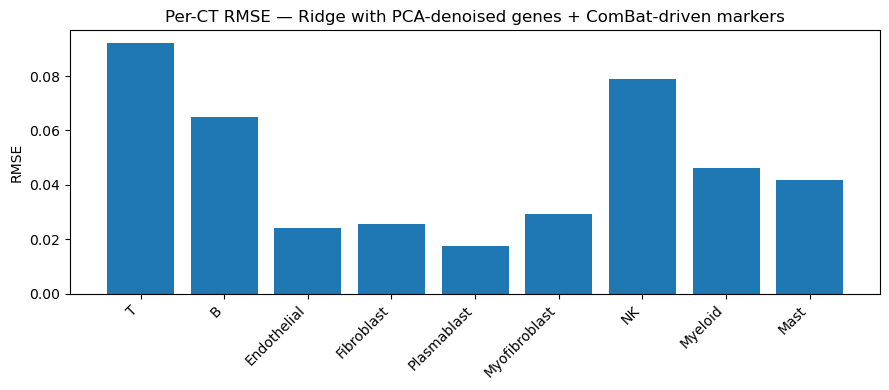

In [28]:
# Jupyter cell: PCA denoise → LOPO + inner K-fold + ILR + Ridge
from __future__ import annotations
import re, random, warnings
warnings.filterwarnings("ignore")

# ========= PATHS =========
AD_PATH        = r"../train_data/train_adata.h5ad"
BULK_PATH      = r"../train_data/train_bulk.csv"          # genes × n_train
TEST_BULK_PATH = r"../test_data/test_bulk.csv"            # genes × n_test
TRUE_PATH      = r"../train_data/train_bulk_trueprops.csv"

# ========= SETTINGS =========
CELLTYPE_COL   = "highLevelType"
TARGET_ORDER   = ["T","B","Endothelial","Fibroblast","Plasmablast","Myofibroblast","NK","Myeloid","Mast"]
MARKER_TOPK_CT = 200          # ← 用於 ComBat 後的 per-CT 標記數
INNER_N_FOLDS  = 5
RIDGE_ALPHA    = 1e-2
SEED           = 42

# PCA 去噪參數
PCA_FIT_ON       = "joint"   # "train" | "joint"
PCA_N_COMPONENTS = 200       # 若 None 則由 VAR_RATIO 自動挑 k
PCA_VAR_RATIO    = 0.95
PCA_WHITEN       = False

# 前處理
USE_WINSORIZE = True
WINSOR_Q      = 0.995
USE_ASINH     = True
ASINH_C       = 1.0

import numpy as np, pandas as pd, matplotlib.pyplot as plt
np.random.seed(SEED); random.seed(SEED)

# ---- deps
try:
    import scanpy as sc
except Exception as e:
    raise ImportError("請先安裝 scanpy：pip install scanpy") from e

from sklearn.decomposition import PCA
from sklearn.model_selection import KFold
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge

# ========= utils =========
def preprocess_sc_log1p(ad):
    sc.pp.normalize_total(ad, target_sum=1e4)
    sc.pp.log1p(ad)  # 為 pseudobulk/ComBat 的穩定性

def cpm10k(df: pd.DataFrame) -> pd.DataFrame:
    lib = df.sum(axis=0).astype(float); lib[lib==0.0] = 1.0
    return df.div(lib, axis=1) * 1e4

def winsorize_per_gene(df: pd.DataFrame, q: float) -> pd.DataFrame:
    if not (0.5 < q < 1.0): return df
    up = df.quantile(q, axis=1)
    return df.clip(lower=0.0, upper=up, axis=0)

def asinh_vst(df: pd.DataFrame, c: float = 1.0) -> pd.DataFrame:
    return np.arcsinh(df / float(c))

def parse_sample_from_bulk_col(col: str) -> str:
    m = re.match(r"^(s\d+)", str(col).lower())
    return m.group(1) if m else str(col)

def simplex_proj(v: np.ndarray) -> np.ndarray:
    u = np.sort(v)[::-1]; cssv = np.cumsum(u)
    rho = np.nonzero(u * np.arange(1, len(u)+1) > (cssv - 1))[0][-1]
    theta = (cssv[rho] - 1) / (rho + 1.0)
    return np.maximum(v - theta, 0.0)

# ILR
def helmert_basis(K: int) -> np.ndarray:
    H = np.zeros((K, K-1))
    for i in range(1, K):
        a = np.ones(i)/i; H[:i, i-1] = a; H[i, i-1] = -1.
    for j in range(K-1):
        col = H[:, j]; H[:, j] = col / (np.linalg.norm(col)+1e-12)
    return H

def ilr(p: np.ndarray, H: np.ndarray) -> np.ndarray:
    eps = 1e-12; p = np.maximum(p, eps); p = p / p.sum(axis=-1, keepdims=True)
    return np.log(p) @ H

def ilr_inv(z: np.ndarray, H: np.ndarray) -> np.ndarray:
    x = np.exp(z @ H.T); return x / x.sum(axis=-1, keepdims=True)

# ---- pseudobulk + ComBat（batch=Sample） + per-CT 標記選擇
def pseudobulk_by_sample_ct(ad, ct_col: str, sample_col: str) -> pd.DataFrame:
    obs = ad.obs[[ct_col, sample_col]].astype(str)
    groups = obs.groupby([sample_col, ct_col]).indices
    cols, names = [], []
    for (s, ct), idx in groups.items():
        Xi = ad.X[idx]
        cols.append(np.asarray(Xi.mean(axis=0)).ravel()); names.append(f"{s}|{ct}")
    return pd.DataFrame(np.column_stack(cols), index=ad.var_names.astype(str), columns=names)

def combat_on_pb(pb: pd.DataFrame) -> pd.DataFrame:
    # batch=Sample；列=基因，欄= "Sample|CT"
    ad_tmp = sc.AnnData(pb.T.copy())
    ad_tmp.obs["batch"] = pd.Categorical([c.split("|",1)[0] for c in pb.columns])
    sc.pp.combat(ad_tmp, key="batch")
    return pd.DataFrame(ad_tmp.X.T, index=pb.index, columns=pb.columns)

def stratified_marker_union_combat(pb_cb: pd.DataFrame, topk_per_ct: int, ct_order: list[str]) -> list[str]:
    """
    在 ComBat 校正後的 pseudobulk 上，以每個 CT 的平均 vs 其餘 CT 的平均計算 log2FC，取 TopK/CT。
    """
    eps = 1e-9
    cts = sorted({c.split("|",1)[1] for c in pb_cb.columns})
    order = [ct for ct in ct_order if ct in cts] + [ct for ct in cts if ct not in ct_order]
    mean_all = pb_cb.mean(axis=1) + eps
    K = len(cts)
    selected = set()
    for ct in order:
        cols_ct = [c for c in pb_cb.columns if c.split("|",1)[1]==ct]
        if not cols_ct: continue
        m_ct = pb_cb[cols_ct].mean(axis=1)
        rest = (mean_all * K - m_ct) / max(1, K-1)
        score = np.log2((m_ct+eps)/(rest+eps)).sort_values(ascending=False)
        selected.update(score.index[:topk_per_ct])
    return list(selected)

# ========= PCA denoise =========
def _cap_pca_k(n_samples: int, n_genes: int, req_k: int|None) -> int:
    return max(1, min((n_samples - 1), n_genes)) if req_k is None else max(1, min(req_k, (min(n_samples-1, n_genes))))

def fit_pca(X_samples_by_genes: pd.DataFrame,
            n_components: int|None, var_ratio: float, whiten: bool, seed: int) -> PCA:
    n_samples, n_genes = X_samples_by_genes.shape
    k_cap = max(1, min(n_samples - 1, n_genes))
    if n_components is None:
        k0 = min(k_cap, 512)
        p0 = PCA(n_components=k0, svd_solver="randomized", whiten=whiten, random_state=seed)
        p0.fit(X_samples_by_genes.values)
        cume = np.cumsum(p0.explained_variance_ratio_)
        k = int(np.searchsorted(cume, var_ratio) + 1)
        k = max(1, min(k, k0))
    else:
        k = max(1, min(int(n_components), k_cap))
    pca = PCA(n_components=k, svd_solver="randomized", whiten=whiten, random_state=seed)
    pca.fit(X_samples_by_genes.values)
    return pca

def denoise_pca(B_all_raw: pd.DataFrame, B_test_raw: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    Xtr = B_all_raw.T.copy(); Xte = B_test_raw.T.copy()
    if PCA_FIT_ON == "train":
        pca = fit_pca(Xtr, PCA_N_COMPONENTS, PCA_VAR_RATIO, PCA_WHITEN, SEED)
    else:
        Xjoint = pd.concat([Xtr, Xte], axis=0)
        pca = fit_pca(Xjoint, PCA_N_COMPONENTS, PCA_VAR_RATIO, PCA_WHITEN, SEED)
    Ztr = pca.transform(Xtr.values); Zte = pca.transform(Xte.values)
    Xtr_dn = pca.inverse_transform(Ztr); Xte_dn = pca.inverse_transform(Zte)
    B_all_dn  = pd.DataFrame(Xtr_dn, index=Xtr.index, columns=B_all_raw.index).T
    B_test_dn = pd.DataFrame(Xte_dn, index=Xte.index, columns=B_test_raw.index).T
    print(f"[PCA] k={pca.n_components_}, cum_var={pca.explained_variance_ratio_.sum():.4f}, whiten={PCA_WHITEN}, fit_on={PCA_FIT_ON}")
    return B_all_dn, B_test_dn

# ========= load & preprocess =========
sc.settings.verbosity = 0
adata = sc.read_h5ad(AD_PATH)
bulk_tr  = pd.read_csv(BULK_PATH, index_col=0).apply(pd.to_numeric, errors="coerce").fillna(0.0)
bulk_te  = pd.read_csv(
                       , index_col=0).apply(pd.to_numeric, errors="coerce").fillna(0.0)
truth    = pd.read_csv(TRUE_PATH, index_col=0)

for ct in TARGET_ORDER:
    if ct not in truth.index: truth.loc[ct] = 0.0

genes = bulk_tr.index.intersection(bulk_te.index).astype(str)
B_all_raw  = cpm10k(bulk_tr.loc[genes].astype(float))
B_test_raw = cpm10k(bulk_te.loc[genes].astype(float))
if USE_WINSORIZE:
    B_all_raw  = winsorize_per_gene(B_all_raw,  WINSOR_Q)
    B_test_raw = winsorize_per_gene(B_test_raw, WINSOR_Q)
if USE_ASINH:
    B_all_raw  = asinh_vst(B_all_raw,  ASINH_C)
    B_test_raw = asinh_vst(B_test_raw, ASINH_C)

# ========= PCA 去噪 =========
B_all_dn, B_test_dn = denoise_pca(B_all_raw, B_test_raw)

# ========= LOPO mapping =========
preprocess_sc_log1p(adata)
if CELLTYPE_COL not in adata.obs:
    if "cell_type" in adata.obs: CELLTYPE_COL = "cell_type"
    else: raise KeyError("missing cell-type column in adata.obs")
if "Sample" not in adata.obs or "Patient" not in adata.obs:
    raise KeyError("adata.obs needs 'Sample' and 'Patient'")

samples_bulk = B_all_dn.columns.tolist()
sample_to_patient = (
    adata.obs[["Sample","Patient"]]
    .drop_duplicates()
    .set_index("Sample")["Patient"].astype(str)
)
def parse_sample_from_bulk_col2(col: str) -> str:
    m = re.match(r"^(s\d+)", str(col).lower())
    return m.group(1) if m else str(col)

col_to_sample  = {c: parse_sample_from_bulk_col2(c) for c in samples_bulk}
col_to_patient = {c: sample_to_patient.get(col_to_sample[c], "UNK") for c in samples_bulk}

keep_cols = [c for c in samples_bulk if col_to_patient[c]!="UNK" and c in truth.columns]
B_all_dn = B_all_dn[keep_cols].copy()
T_all = truth.loc[TARGET_ORDER, keep_cols].T
patients_all = sorted({col_to_patient[c] for c in B_all_dn.columns})

# ========= ILR basis =========
Kc = len(TARGET_ORDER); H = helmert_basis(Kc)

# ========= LOPO + inner K-fold（marker 選擇加入 ComBat）=========
preds_by_sample: dict[str, list[np.ndarray]] = {}
truth_by_sample: dict[str, np.ndarray] = {}
patient_of_col: dict[str, str] = {}

for p_test in patients_all:
    test_cols = [c for c in B_all_dn.columns if col_to_patient[c]==p_test]
    if not test_cols: continue
    others = [p for p in patients_all if p != p_test]
    if not others: continue

    K_inner = min(INNER_N_FOLDS, max(1, len(others)))
    kf = KFold(n_splits=K_inner, shuffle=True, random_state=SEED)
    others_arr = np.array(others)

    bag_y: dict[str, list[np.ndarray]] = {c: [] for c in test_cols}

    for _, (tr_mask, _) in enumerate(kf.split(others_arr), 1):
        in_tr_pats = set(others_arr[tr_mask].tolist())
        ad_tr = adata[adata.obs["Patient"].astype(str).isin(in_tr_pats)].copy()
        if ad_tr.n_obs < 10: continue

        # --- ComBat 驅動的 marker 選擇 ---
        pb = pseudobulk_by_sample_ct(ad_tr, CELLTYPE_COL, "Sample")
        pb_cb = combat_on_pb(pb)  # batch=Sample
        markers = stratified_marker_union_combat(pb_cb, topk_per_ct=MARKER_TOPK_CT, ct_order=TARGET_ORDER)

        genes_used = B_all_dn.index.intersection(markers)
        if len(genes_used) < 20: continue

        tr_cols_inner = [c for c in B_all_dn.columns if col_to_patient[c] in in_tr_pats]
        if len(tr_cols_inner) < 2: continue

        X_in_tr = B_all_dn.loc[genes_used, tr_cols_inner].T
        y_in_tr = T_all.loc[tr_cols_inner].values
        z_in_tr = ilr(y_in_tr, H)

        model = MultiOutputRegressor(Ridge(alpha=RIDGE_ALPHA, random_state=SEED))
        model.fit(X_in_tr, z_in_tr)

        X_te = B_all_dn.loc[genes_used, test_cols].T
        z_pred = model.predict(X_te)
        y_pred = ilr_inv(z_pred, H)
        y_pred = np.vstack([simplex_proj(row) for row in y_pred])

        for i, col in enumerate(test_cols):
            bag_y[col].append(y_pred[i])

    for col in test_cols:
        truth_by_sample[col] = T_all.loc[col].values
        patient_of_col[col]  = p_test
        if len(bag_y[col]) > 0:
            y_mean = simplex_proj(np.mean(np.vstack(bag_y[col]), axis=0))
        else:
            y_mean = np.ones(Kc)/Kc
        preds_by_sample.setdefault(col, []).append(y_mean)

# ========= 評估 =========
cols_eval = sorted(truth_by_sample.keys())
Y_true = np.vstack([truth_by_sample[c] for c in cols_eval])
Y_pred = np.vstack([simplex_proj(np.vstack(preds_by_sample[c]).mean(axis=0)) for c in cols_eval])

rmse_ct = np.sqrt(((Y_pred - Y_true)**2).mean(axis=0))
avg_rmse = float(rmse_ct.mean()); per_ct = pd.Series(rmse_ct, index=TARGET_ORDER)

print(f"\n=== LOPO + inner K-fold — mean-in-simplex | PCA Denoised + ComBat-driven markers ===")
print(f"PCA: fit_on={PCA_FIT_ON}, n_components={PCA_N_COMPONENTS}, var_ratio={PCA_VAR_RATIO}, whiten={PCA_WHITEN}")
print(f"Markers: TopK/CT={MARKER_TOPK_CT} (ComBat batch=Sample, log2FC vs rest)")
print(f"INNER folds up to {INNER_N_FOLDS} | Ridge α={RIDGE_ALPHA}")
print(f"Total test samples evaluated = {len(cols_eval)}")
print(f"Avg RMSE = {avg_rmse:.4f}\nPer-CT RMSE:")
print(per_ct.round(4).to_string())

plt.figure(figsize=(9,4))
plt.bar(TARGET_ORDER, per_ct.values)
plt.xticks(rotation=45, ha="right"); plt.ylabel("RMSE")
plt.title("Per-CT RMSE — Ridge with PCA-denoised genes + ComBat-driven markers")
plt.tight_layout(); plt.show()


[PCA] k=31, cum_var=1.0000, whiten=False, fit_on=joint

=== LOPO + inner K-fold — mean-in-simplex | PCA Denoised ===
PCA: fit_on=joint, n_components=200, var_ratio=0.95, whiten=False
INNER folds up to 5 | Ridge α=0.01
Total test samples evaluated = 12
Avg RMSE = 0.0468
Per-CT RMSE:
T                0.0918
B                0.0658
Endothelial      0.0245
Fibroblast       0.0265
Plasmablast      0.0176
Myofibroblast    0.0290
NK               0.0756
Myeloid          0.0477
Mast             0.0428


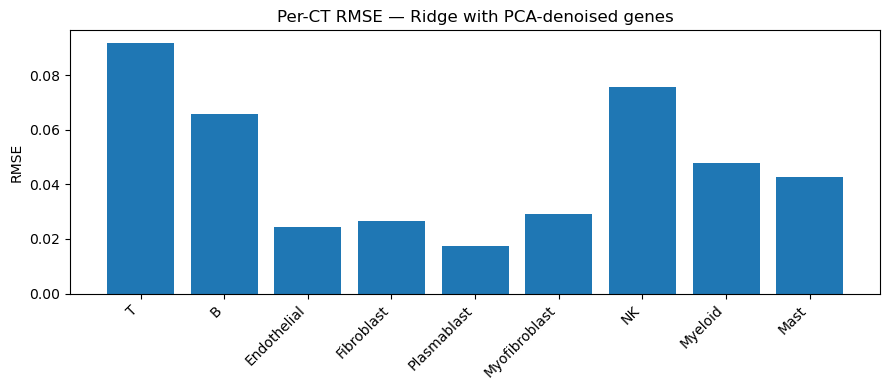

In [29]:
# Jupyter cell: PCA denoise → LOPO + inner K-fold + ILR + Ridge
from __future__ import annotations
import re, random, warnings
warnings.filterwarnings("ignore")

# ========= PATHS =========
AD_PATH        = r"../train_data/train_adata.h5ad"
BULK_PATH      = r"../train_data/train_bulk.csv"          # genes × n_train
TEST_BULK_PATH = r"../test_data/test_bulk.csv"            # genes × n_test
TRUE_PATH      = r"../train_data/train_bulk_trueprops.csv"

# ========= SETTINGS =========
CELLTYPE_COL   = "highLevelType"
TARGET_ORDER   = ["T","B","Endothelial","Fibroblast","Plasmablast","Myofibroblast","NK","Myeloid","Mast"]
HVG_TOPK_CT    = 200
INNER_N_FOLDS  = 5
RIDGE_ALPHA    = 1e-2
SEED           = 42

# PCA 去噪參數
PCA_FIT_ON       = "joint"   # "train" | "joint"（推薦 joint 可縮小 train/test shift）
PCA_N_COMPONENTS = 200       # 若 None 則由 VAR_RATIO 自動挑 k
PCA_VAR_RATIO    = 0.95      # 自動模式的累積解釋變異門檻
PCA_WHITEN       = False     # 一般建議 False；True 會改變尺度

# 前處理
USE_WINSORIZE = True
WINSOR_Q      = 0.995
USE_ASINH     = True
ASINH_C       = 1.0

import numpy as np, pandas as pd, matplotlib.pyplot as plt
np.random.seed(SEED); random.seed(SEED)

# ---- deps
try:
    import scanpy as sc
except Exception as e:
    raise ImportError("請先安裝 scanpy：pip install scanpy") from e

from sklearn.decomposition import PCA
from sklearn.model_selection import KFold
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge

# ========= utils =========
def preprocess_sc_log1p(ad):
    sc.pp.normalize_total(ad, target_sum=1e4)

def cpm10k(df: pd.DataFrame) -> pd.DataFrame:
    lib = df.sum(axis=0).astype(float); lib[lib==0.0] = 1.0
    return df.div(lib, axis=1) * 1e4

def winsorize_per_gene(df: pd.DataFrame, q: float) -> pd.DataFrame:
    if not (0.5 < q < 1.0): return df
    up = df.quantile(q, axis=1)
    return df.clip(lower=0.0, upper=up, axis=0)

def asinh_vst(df: pd.DataFrame, c: float = 1.0) -> pd.DataFrame:
    return np.arcsinh(df / float(c))

def parse_sample_from_bulk_col(col: str) -> str:
    m = re.match(r"^(s\d+)", str(col).lower())
    return m.group(1) if m else str(col)

def simplex_proj(v: np.ndarray) -> np.ndarray:
    u = np.sort(v)[::-1]; cssv = np.cumsum(u)
    rho = np.nonzero(u * np.arange(1, len(u)+1) > (cssv - 1))[0][-1]
    theta = (cssv[rho] - 1) / (rho + 1.0)
    return np.maximum(v - theta, 0.0)

# ILR
def helmert_basis(K: int) -> np.ndarray:
    H = np.zeros((K, K-1))
    for i in range(1, K):
        a = np.ones(i)/i; H[:i, i-1] = a; H[i, i-1] = -1.
    for j in range(K-1):
        col = H[:, j]; H[:, j] = col / (np.linalg.norm(col)+1e-12)
    return H

def ilr(p: np.ndarray, H: np.ndarray) -> np.ndarray:
    eps = 1e-12; p = np.maximum(p, eps); p = p / p.sum(axis=-1, keepdims=True)
    return np.log(p) @ H

def ilr_inv(z: np.ndarray, H: np.ndarray) -> np.ndarray:
    x = np.exp(z @ H.T); return x / x.sum(axis=-1, keepdims=True)

def hvg_union_scanpy(ad_sub, ct_col: str, topk_ct: int) -> list[str]:
    genes = set(); ct_vals = ad_sub.obs[ct_col].astype(str)
    for c in sorted(pd.unique(ct_vals)):
        ad_ct = ad_sub[ct_vals == c].copy()
        if ad_ct.n_obs < 3: continue
        sc.pp.highly_variable_genes(ad_ct, n_top_genes=topk_ct, flavor="seurat_v3", inplace=True)
        genes.update(ad_ct.var.index[ad_ct.var["highly_variable"]].tolist())
    return list(genes)

# ========= PCA denoise =========
def _cap_pca_k(n_samples: int, n_genes: int, req_k: int|None) -> int:
    # PCA 受限於 rank ≤ min(n_samples-1, n_genes)
    return max(1, min((n_samples - 1), n_genes)) if req_k is None else max(1, min(req_k, (min(n_samples-1, n_genes))))

def fit_pca(X_samples_by_genes: pd.DataFrame,
            n_components: int|None, var_ratio: float, whiten: bool, seed: int) -> PCA:
    n_samples, n_genes = X_samples_by_genes.shape
    k_cap = max(1, min(n_samples - 1, n_genes))
    if n_components is None:
        k0 = min(k_cap, 512)
        p0 = PCA(n_components=k0, svd_solver="randomized", whiten=whiten, random_state=seed)
        p0.fit(X_samples_by_genes.values)
        cume = np.cumsum(p0.explained_variance_ratio_)
        k = int(np.searchsorted(cume, var_ratio) + 1)
        k = max(1, min(k, k0))
    else:
        k = max(1, min(int(n_components), k_cap))
    pca = PCA(n_components=k, svd_solver="randomized", whiten=whiten, random_state=seed)
    pca.fit(X_samples_by_genes.values)
    return pca

def denoise_pca(B_all_raw: pd.DataFrame, B_test_raw: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    # genes×samples → samples×genes
    Xtr = B_all_raw.T.copy(); Xte = B_test_raw.T.copy()
    if PCA_FIT_ON == "train":
        pca = fit_pca(Xtr, PCA_N_COMPONENTS, PCA_VAR_RATIO, PCA_WHITEN, SEED)
    else:
        Xjoint = pd.concat([Xtr, Xte], axis=0)
        pca = fit_pca(Xjoint, PCA_N_COMPONENTS, PCA_VAR_RATIO, PCA_WHITEN, SEED)
    # 投影到主子空間 → 低秩重建（去噪）
    Ztr = pca.transform(Xtr.values); Zte = pca.transform(Xte.values)
    Xtr_dn = pca.inverse_transform(Ztr); Xte_dn = pca.inverse_transform(Zte)
    # 回到 genes×samples
    B_all_dn  = pd.DataFrame(Xtr_dn, index=Xtr.index, columns=B_all_raw.index).T
    B_test_dn = pd.DataFrame(Xte_dn, index=Xte.index, columns=B_test_raw.index).T
    print(f"[PCA] k={pca.n_components_}, cum_var={pca.explained_variance_ratio_.sum():.4f}, whiten={PCA_WHITEN}, fit_on={PCA_FIT_ON}")
    return B_all_dn, B_test_dn

# ========= load & preprocess =========
sc.settings.verbosity = 0
adata = sc.read_h5ad(AD_PATH)
bulk_tr  = pd.read_csv(BULK_PATH, index_col=0).apply(pd.to_numeric, errors="coerce").fillna(0.0)
bulk_te  = pd.read_csv(TEST_BULK_PATH, index_col=0).apply(pd.to_numeric, errors="coerce").fillna(0.0)
truth    = pd.read_csv(TRUE_PATH, index_col=0)

for ct in TARGET_ORDER:
    if ct not in truth.index: truth.loc[ct] = 0.0

genes = bulk_tr.index.intersection(bulk_te.index).astype(str)
B_all_raw  = cpm10k(bulk_tr.loc[genes].astype(float))
B_test_raw = cpm10k(bulk_te.loc[genes].astype(float))
if USE_WINSORIZE:
    B_all_raw  = winsorize_per_gene(B_all_raw,  WINSOR_Q)
    B_test_raw = winsorize_per_gene(B_test_raw, WINSOR_Q)
if USE_ASINH:
    B_all_raw  = asinh_vst(B_all_raw,  ASINH_C)
    B_test_raw = asinh_vst(B_test_raw, ASINH_C)

# ========= PCA 去噪 =========
B_all_dn, B_test_dn = denoise_pca(B_all_raw, B_test_raw)

# ========= LOPO mapping =========
preprocess_sc_log1p(adata)
if CELLTYPE_COL not in adata.obs:
    if "cell_type" in adata.obs: CELLTYPE_COL = "cell_type"
    else: raise KeyError("missing cell-type column in adata.obs")
if "Sample" not in adata.obs or "Patient" not in adata.obs:
    raise KeyError("adata.obs needs 'Sample' and 'Patient'")

samples_bulk = B_all_dn.columns.tolist()
sample_to_patient = (
    adata.obs[["Sample","Patient"]]
    .drop_duplicates()
    .set_index("Sample")["Patient"].astype(str)
)
def parse_sample_from_bulk_col2(col: str) -> str:
    m = re.match(r"^(s\d+)", str(col).lower())
    return m.group(1) if m else str(col)

col_to_sample  = {c: parse_sample_from_bulk_col2(c) for c in samples_bulk}
col_to_patient = {c: sample_to_patient.get(col_to_sample[c], "UNK") for c in samples_bulk}

keep_cols = [c for c in samples_bulk if col_to_patient[c]!="UNK" and c in truth.columns]
B_all_dn = B_all_dn[keep_cols].copy()
T_all = truth.loc[TARGET_ORDER, keep_cols].T
patients_all = sorted({col_to_patient[c] for c in B_all_dn.columns})

# ========= ILR basis =========
Kc = len(TARGET_ORDER); H = helmert_basis(Kc)

# ========= LOPO + inner K-fold =========
preds_by_sample: dict[str, list[np.ndarray]] = {}
truth_by_sample: dict[str, np.ndarray] = {}
patient_of_col: dict[str, str] = {}

for p_test in patients_all:
    test_cols = [c for c in B_all_dn.columns if col_to_patient[c]==p_test]
    if not test_cols: continue
    others = [p for p in patients_all if p != p_test]
    if not others: continue

    K_inner = min(INNER_N_FOLDS, max(1, len(others)))
    kf = KFold(n_splits=K_inner, shuffle=True, random_state=SEED)
    others_arr = np.array(others)

    bag_y: dict[str, list[np.ndarray]] = {c: [] for c in test_cols}

    for _, (tr_mask, _) in enumerate(kf.split(others_arr), 1):
        in_tr_pats = set(others_arr[tr_mask].tolist())
        ad_tr = adata[adata.obs["Patient"].astype(str).isin(in_tr_pats)].copy()
        if ad_tr.n_obs < 10: continue

        genes_hvg = hvg_union_scanpy(ad_tr, CELLTYPE_COL, topk_ct=HVG_TOPK_CT)
        genes_used = B_all_dn.index.intersection(genes_hvg)
        if len(genes_used) < 20: continue

        tr_cols_inner = [c for c in B_all_dn.columns if col_to_patient[c] in in_tr_pats]
        if len(tr_cols_inner) < 2: continue

        X_in_tr = B_all_dn.loc[genes_used, tr_cols_inner].T
        y_in_tr = T_all.loc[tr_cols_inner].values
        z_in_tr = ilr(y_in_tr, H)

        model = MultiOutputRegressor(Ridge(alpha=RIDGE_ALPHA, random_state=SEED))
        model.fit(X_in_tr, z_in_tr)

        X_te = B_all_dn.loc[genes_used, test_cols].T
        z_pred = model.predict(X_te)
        y_pred = ilr_inv(z_pred, H)
        y_pred = np.vstack([simplex_proj(row) for row in y_pred])

        for i, col in enumerate(test_cols):
            bag_y[col].append(y_pred[i])

    for col in test_cols:
        truth_by_sample[col] = T_all.loc[col].values
        patient_of_col[col]  = p_test
        if len(bag_y[col]) > 0:
            y_mean = simplex_proj(np.mean(np.vstack(bag_y[col]), axis=0))
        else:
            y_mean = np.ones(Kc)/Kc
        preds_by_sample.setdefault(col, []).append(y_mean)

# ========= 評估 =========
cols_eval = sorted(truth_by_sample.keys())
Y_true = np.vstack([truth_by_sample[c] for c in cols_eval])
Y_pred = np.vstack([simplex_proj(np.vstack(preds_by_sample[c]).mean(axis=0)) for c in cols_eval])

rmse_ct = np.sqrt(((Y_pred - Y_true)**2).mean(axis=0))
avg_rmse = float(rmse_ct.mean()); per_ct = pd.Series(rmse_ct, index=TARGET_ORDER)

print(f"\n=== LOPO + inner K-fold — mean-in-simplex | PCA Denoised ===")
print(f"PCA: fit_on={PCA_FIT_ON}, n_components={PCA_N_COMPONENTS}, var_ratio={PCA_VAR_RATIO}, whiten={PCA_WHITEN}")
print(f"INNER folds up to {INNER_N_FOLDS} | Ridge α={RIDGE_ALPHA}")
print(f"Total test samples evaluated = {len(cols_eval)}")
print(f"Avg RMSE = {avg_rmse:.4f}\nPer-CT RMSE:")
print(per_ct.round(4).to_string())

plt.figure(figsize=(9,4))
plt.bar(TARGET_ORDER, per_ct.values)
plt.xticks(rotation=45, ha="right"); plt.ylabel("RMSE")
plt.title("Per-CT RMSE — Ridge with PCA-denoised genes")
plt.tight_layout(); plt.show()



=== Outer-level jitter（每個 outer：baseline vs. 移除單一訓練病人）===
outer_patient removed_patient  n_test_samples  avg_rmse  RMSE_T  RMSE_B  RMSE_Endothelial  RMSE_Fibroblast  RMSE_Plasmablast  RMSE_Myofibroblast  RMSE_NK  RMSE_Myeloid  RMSE_Mast   d_avg     d_T     d_B  d_Endothelial  d_Fibroblast  d_Plasmablast  d_Myofibroblast    d_NK  d_Myeloid  d_Mast
           P1             ALL               2    0.0341  0.0549  0.0455            0.0029           0.0457            0.0148              0.0088   0.0499        0.0679     0.0166  0.0000  0.0000  0.0000         0.0000        0.0000         0.0000           0.0000  0.0000     0.0000  0.0000
           P1              P2               2    0.0300  0.0355  0.0434            0.0027           0.0466            0.0039              0.0188   0.0367        0.0593     0.0238 -0.0041 -0.0194 -0.0022        -0.0002        0.0009        -0.0109           0.0100 -0.0132    -0.0086  0.0072
           P1              P3               2    0.0298  0.0577  0.0

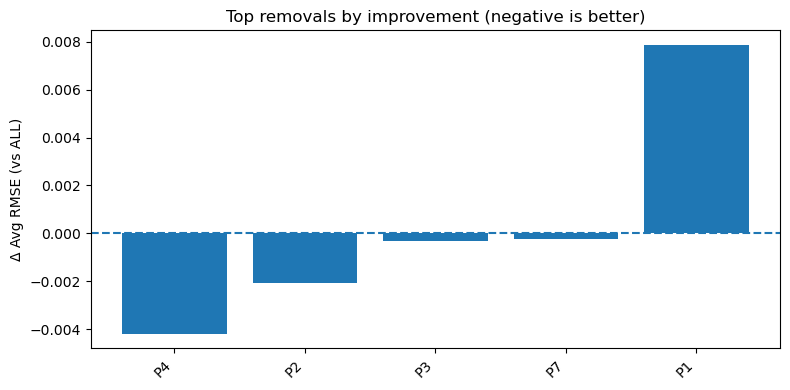

In [57]:
# Jupyter cell: LOPO(train_outer jitter) — 移除單一訓練病人的影響評估
# 固定：ScanpyHVU (per-CT seurat_v3 HVG Top-K union) + Ridge(ILR)

AD_PATH    = r"../train_data/train_adata.h5ad"
BULK_PATH  = r"../train_data/train_bulk.csv"
TRUE_PATH  = r"../train_data/train_bulk_trueprops.csv"

CELLTYPE_COL   = "highLevelType"
TARGET_ORDER   = ["T","B","Endothelial","Fibroblast","Plasmablast","Myofibroblast","NK","Myeloid","Mast"]
HVG_TOPK_CT    = 200
SEED           = 42

import re, numpy as np, pandas as pd, matplotlib.pyplot as plt
from typing import List, Dict, Tuple
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge
import warnings
warnings.filterwarnings("ignore")

# ------------ utils ------------
def need_scanpy():
    import scanpy as sc
    return sc

def preprocess_sc(ad):
    sc = need_scanpy()
    sc.pp.normalize_total(ad, target_sum=1e4)
    sc.pp.log1p(ad)

def cpm_log1p_bulk(df: pd.DataFrame) -> pd.DataFrame:
    lib = df.sum(axis=0); lib[lib==0]=1.0
    return np.log1p(df.div(lib, axis=1) * 1e4)

def parse_sample_from_bulk_col(col: str) -> str:
    m = re.match(r"^(s\d+)", str(col).lower())
    return m.group(1) if m else str(col)

def simplex_proj(v: np.ndarray) -> np.ndarray:
    u = np.sort(v)[::-1]
    cssv = np.cumsum(u)
    rho = np.nonzero(u * np.arange(1, len(u)+1) > (cssv - 1))[0][-1]
    theta = (cssv[rho] - 1) / (rho + 1.0)
    return np.maximum(v - theta, 0.0)

# ILR
def helmert_basis(K: int) -> np.ndarray:
    H = np.zeros((K, K-1))
    for i in range(1, K):
        a = np.ones(i)/i
        H[:i, i-1] = a
        H[i,   i-1] = -1.0
    for j in range(K-1):
        col = H[:, j]; H[:, j] = col / (np.linalg.norm(col) + 1e-12)
    return H

def ilr(p: np.ndarray, H: np.ndarray) -> np.ndarray:
    eps = 1e-12
    p = np.maximum(p, eps)
    p = p / p.sum(axis=-1, keepdims=True)
    return np.log(p) @ H

def ilr_inv(z: np.ndarray, H: np.ndarray) -> np.ndarray:
    logp = z @ H.T
    x = np.exp(logp)
    return x / x.sum(axis=-1, keepdims=True)

# ScanpyHVU：每個 CT 子集跑 HVG，取 TopK，再 union
def hvg_union_scanpy(ad_sub, ct_col: str, topk_ct: int) -> List[str]:
    sc = need_scanpy()
    genes = set()
    ct_vals = ad_sub.obs[ct_col].astype(str)
    for c in sorted(pd.unique(ct_vals)):
        ad_ct = ad_sub[ct_vals == c].copy()
        if ad_ct.n_obs < 3:  # why: 低樣本避免不穩定 HVG
            continue
        sc.pp.highly_variable_genes(
            ad_ct,
            n_top_genes=topk_ct,
            flavor="seurat_v3",
            inplace=True
        )
        sel = ad_ct.var.index[ad_ct.var["highly_variable"]].tolist()
        genes.update(sel)
    return list(genes)

# ------------ load & align ------------
sc = need_scanpy()
adata = sc.read_h5ad(AD_PATH)
bulk_raw = pd.read_csv(BULK_PATH, index_col=0).apply(pd.to_numeric, errors="coerce").fillna(0.0)
truth    = pd.read_csv(TRUE_PATH, index_col=0)

for ct in TARGET_ORDER:
    if ct not in truth.index:
        truth.loc[ct] = 0.0

if CELLTYPE_COL not in adata.obs:
    if "cell_type" in adata.obs: CELLTYPE_COL = "cell_type"
    else: raise KeyError("missing cell-type column in adata.obs")
if "Sample" not in adata.obs or "Patient" not in adata.obs:
    raise KeyError("adata.obs needs 'Sample' and 'Patient'")

preprocess_sc(adata)

B_all = cpm_log1p_bulk(bulk_raw)  # genes × samples

# sample -> patient
samples_bulk = B_all.columns.tolist()
sample_to_patient = adata.obs[["Sample","Patient"]].drop_duplicates().set_index("Sample")["Patient"].astype(str)
col_to_sample  = {c: parse_sample_from_bulk_col(c) for c in samples_bulk}
col_to_patient = {c: sample_to_patient.get(col_to_sample[c], "UNK") for c in samples_bulk}

keep_cols = [c for c in samples_bulk if col_to_patient[c]!="UNK"]
B_all = B_all[keep_cols]
T_all = truth.loc[TARGET_ORDER, keep_cols].T
patients_all = sorted({col_to_patient[c] for c in B_all.columns})

# ILR basis
Kc = len(TARGET_ORDER)
H = helmert_basis(Kc)

# --------- core: train & predict for a given outer and a given train set ----------
def train_and_predict_for_outer(train_patients: set[str], test_cols: List[str]) -> Tuple[np.ndarray, List[str]]:
    """
    回傳：Y_pred_test (len(test_cols) × K), genes_used(list)
    為避免洩漏：HVG 只用 train_patients 的 cells；訓練集用 train_patients 的所有 bulk 樣本。
    """
    ad_tr = adata[adata.obs["Patient"].astype(str).isin(train_patients)].copy()
    if ad_tr.n_obs < 10:
        return None, []
    genes = hvg_union_scanpy(ad_tr, CELLTYPE_COL, topk_ct=HVG_TOPK_CT)
    genes_used = B_all.index.intersection(genes)
    if len(genes_used) < 20:
        return None, []
    # assemble train bulk/labels
    tr_cols_all = [c for c in B_all.columns if col_to_patient[c] in train_patients]
    X_tr = B_all.loc[genes_used, tr_cols_all].T
    y_tr = T_all.loc[tr_cols_all].values
    z_tr = ilr(y_tr, H)

    model = MultiOutputRegressor(Ridge(alpha=1e-2, random_state=SEED))
    model.fit(X_tr, z_tr)

    X_te = B_all.loc[genes_used, test_cols].T
    z_pred = model.predict(X_te)
    y_pred = ilr_inv(z_pred, H)
    y_pred = np.vstack([simplex_proj(row) for row in y_pred])
    return y_pred, list(genes_used)

def rmse_mat(Yp: np.ndarray, Yt: np.ndarray) -> Tuple[float, np.ndarray]:
    """回傳 Avg RMSE 與 per-CT RMSE"""
    diff = (Yp - Yt)
    per_ct = np.sqrt((diff**2).mean(axis=0))
    return float(per_ct.mean()), per_ct

# ----------------- Outer loop with jitter -----------------
records_outer = []      # 每個 outer×(removed患者或ALL) 的指標
agg_baseline = []       # baseline 的 (Yt,Yp) 累積
agg_removed: Dict[str, list] = {}  # removed_patient -> list of (Yt,Yp)

for p_test in patients_all:
    test_cols = [c for c in B_all.columns if col_to_patient[c]==p_test]
    if not test_cols: 
        continue
    train_patients_full = set(patients_all) - {p_test}

    # baseline：全 train_outer
    Yp_base, genes_used = train_and_predict_for_outer(train_patients_full, test_cols)
    if Yp_base is None:
        continue
    Yt = T_all.loc[test_cols].values
    avg_base, perct_base = rmse_mat(Yp_base, Yt)

    records_outer.append({
        "outer_patient": p_test,
        "removed_patient": "ALL",  # ALL=baseline(無移除)
        "n_test_samples": len(test_cols),
        "avg_rmse": avg_base,
        **{f"RMSE_{ct}": v for ct, v in zip(TARGET_ORDER, perct_base)}
    })
    # 累積 baseline
    agg_baseline.append((Yt, Yp_base))

    # jitter：逐一移除單一訓練病人
    for q in sorted(train_patients_full):
        train_minus = train_patients_full - {q}
        Yp_minus, _ = train_and_predict_for_outer(train_minus, test_cols)
        if Yp_minus is None:
            continue
        avg_minus, perct_minus = rmse_mat(Yp_minus, Yt)

        # 記錄 outer 層結果
        records_outer.append({
            "outer_patient": p_test,
            "removed_patient": q,
            "n_test_samples": len(test_cols),
            "avg_rmse": avg_minus,
            **{f"RMSE_{ct}": v for ct, v in zip(TARGET_ORDER, perct_minus)}
        })

        # 累積全域評估：按 q 收集
        agg_removed.setdefault(q, []).append((Yt, Yp_minus))

# ---- 匯總成表（outer-level）並加上與 baseline 的差異 ----
df_outer = pd.DataFrame(records_outer)
# 找出每個 outer 的 baseline
base_per_outer = df_outer[df_outer["removed_patient"]=="ALL"][["outer_patient","avg_rmse"] + [f"RMSE_{ct}" for ct in TARGET_ORDER]].set_index("outer_patient")
def attach_delta(row):
    op = row["outer_patient"]
    if row["removed_patient"]=="ALL":
        return pd.Series({"d_avg": 0.0, **{f"d_{ct}":0.0 for ct in TARGET_ORDER}})
    b = base_per_outer.loc[op]
    d = {
        "d_avg": row["avg_rmse"] - float(b["avg_rmse"])
    }
    for ct in TARGET_ORDER:
        d[f"d_{ct}"] = row[f"RMSE_{ct}"] - float(b[f"RMSE_{ct}"])
    return pd.Series(d)
df_outer = pd.concat([df_outer, df_outer.apply(attach_delta, axis=1)], axis=1)

print("\n=== Outer-level jitter（每個 outer：baseline vs. 移除單一訓練病人）===")
print(df_outer.sort_values(["outer_patient","removed_patient"]).round(4).to_string(index=False))

# ---- 全域彙總：baseline overall vs. 移除各患者 overall ----
# baseline overall
Yt_all = np.vstack([yt for yt, yp in agg_baseline])
Yp_all = np.vstack([yp for yt, yp in agg_baseline])
avg_base_all, perct_base_all = rmse_mat(Yp_all, Yt_all)

rows_global = []
for q, lst in agg_removed.items():
    Yt_q = np.vstack([yt for yt, yp in lst])
    Yp_q = np.vstack([yp for yt, yp in lst])
    avg_q, perct_q = rmse_mat(Yp_q, Yt_q)
    rows_global.append({
        "removed_patient": q,
        "avg_rmse": avg_q,
        "d_avg_vs_all": avg_q - avg_base_all,
        **{f"RMSE_{ct}": v for ct, v in zip(TARGET_ORDER, perct_q)},
        **{f"d_{ct}": (v - pb) for (ct, v), pb in zip(zip(TARGET_ORDER, perct_q), perct_base_all)}
    })

df_global = pd.DataFrame(rows_global).sort_values("avg_rmse")
print("\n=== Global aggregation（移除某患者 vs. baseline ALL）===")
print(f"Baseline(ALL)  avg_rmse={avg_base_all:.4f} | " +
      " ".join([f"{ct}={v:.4f}" for ct, v in zip(TARGET_ORDER, perct_base_all)]))
print(df_global.round(4).to_string(index=False))

# ---- 找出「拿掉誰 overall 最好」 ----
best_row = df_global.iloc[0] if len(df_global)>0 else None
if best_row is not None:
    print("\n*** 最佳：移除患者 =", best_row['removed_patient'],
          f"| avg_rmse={best_row['avg_rmse']:.4f} (Δ={best_row['d_avg_vs_all']:.4f} vs ALL) ***")
else:
    print("\n(無可用的移除結果可彙總)")

# ---- 視覺化（全域 Top-N 改善，Δ<0越好）----
if len(df_global) > 0:
    df_sorted = df_global.sort_values("d_avg_vs_all").head(min(10, len(df_global)))
    plt.figure(figsize=(8,4))
    plt.bar(df_sorted["removed_patient"].astype(str), df_sorted["d_avg_vs_all"])
    plt.axhline(0, linestyle="--")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Δ Avg RMSE (vs ALL)")
    plt.title("Top removals by improvement (negative is better)")
    plt.tight_layout(); plt.show()


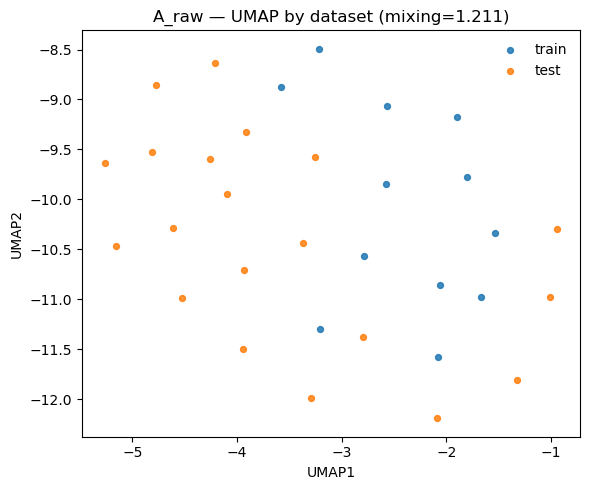

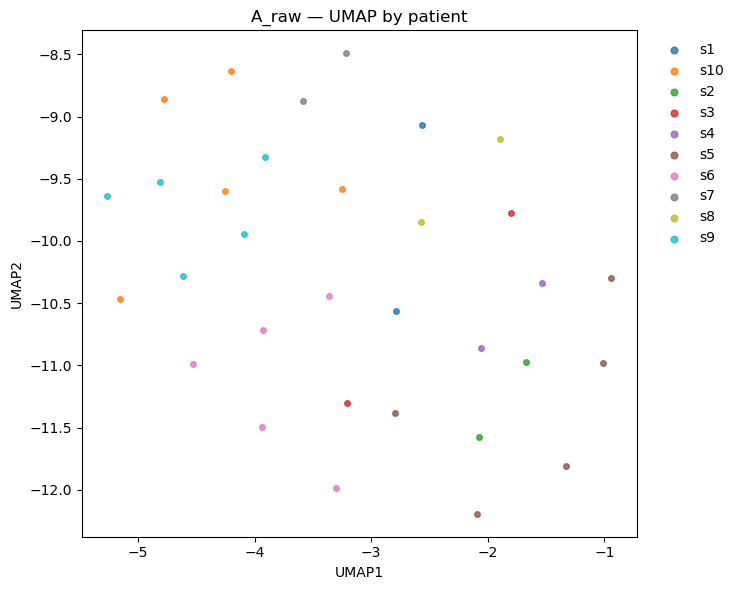

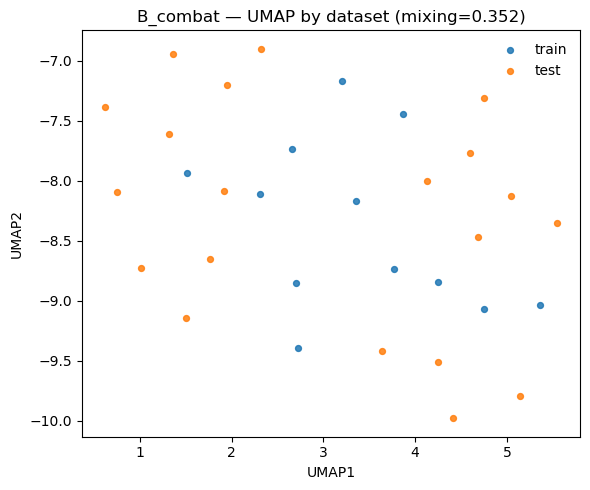

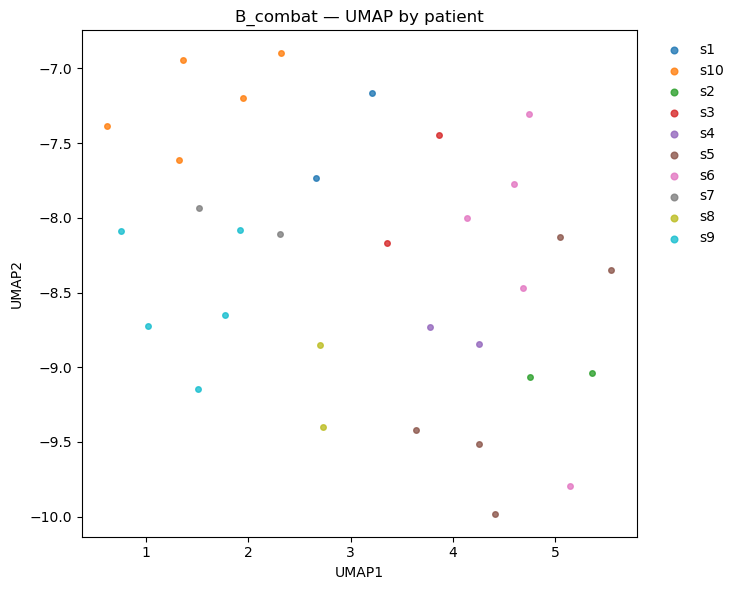

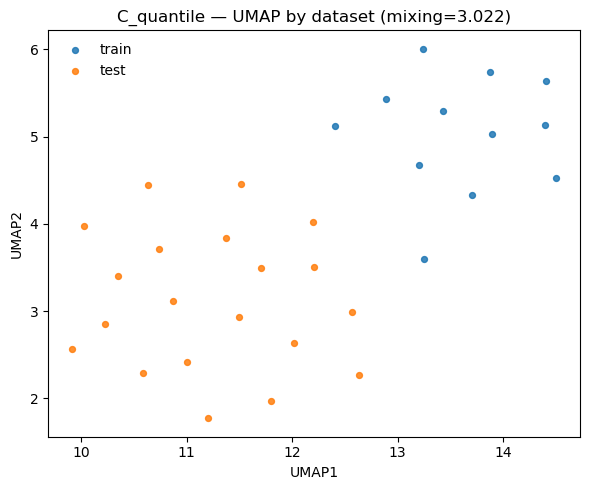

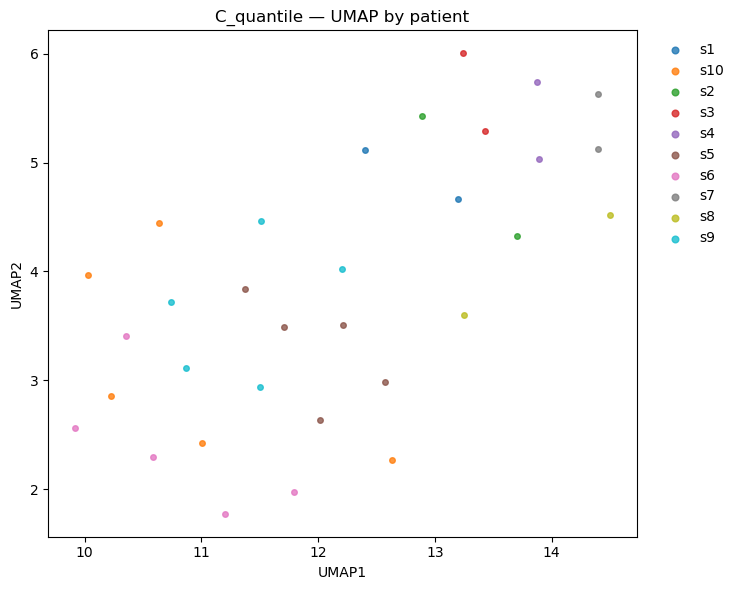

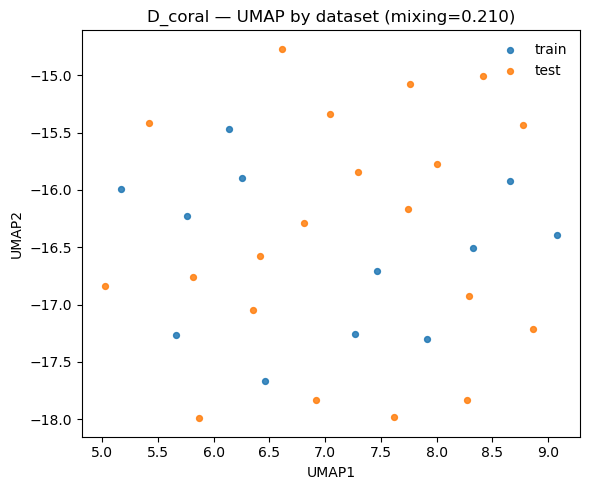

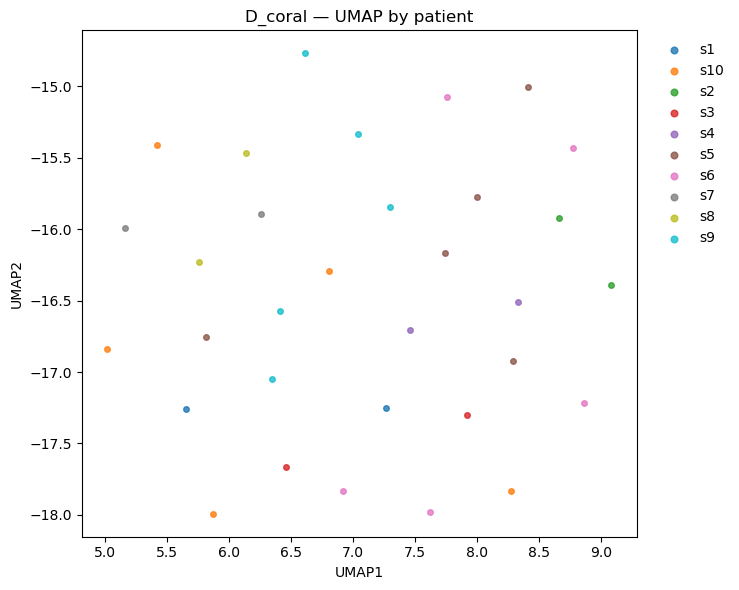

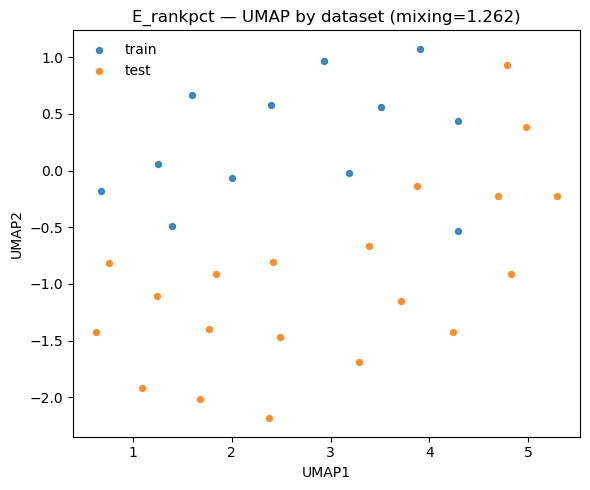

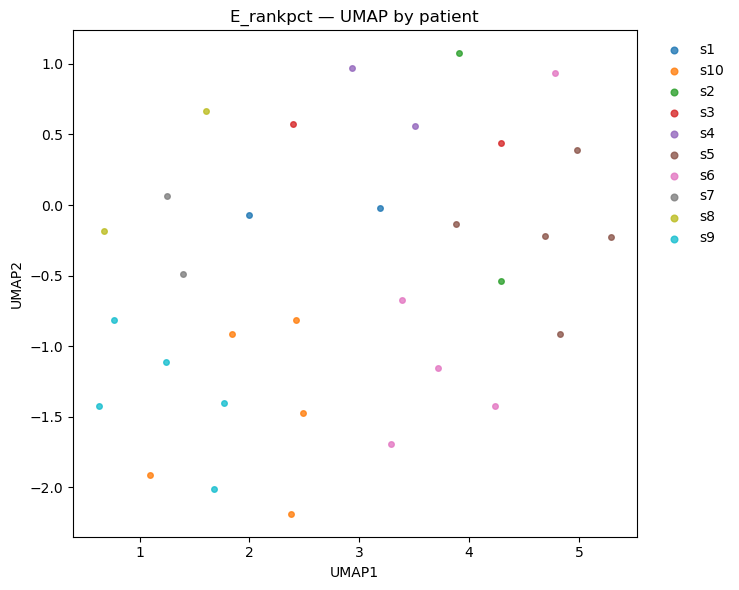


[Mixing score (centroid distance, lower=better)]
   D_coral: 0.2095
  B_combat: 0.3524
     A_raw: 1.2114
 E_rankpct: 1.2616
C_quantile: 3.0215


In [14]:
# ===== Train/Test mixing for visualization: batch alignment + UMAP =====
# 前提：你已經有 B_all, B_test, patient_from_bulk_col 變數（任意前處理：log1p 或 asinh_vst 皆可）

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# --------- Embedding ---------
def compute_2d_embedding(X: pd.DataFrame, use_umap: bool = True, random_state: int = 42) -> np.ndarray:
    try:
        if use_umap:
            import umap.umap_ as umap
            reducer = umap.UMAP(n_neighbors=15, min_dist=0.3, n_components=2, random_state=random_state)
            return reducer.fit_transform(X.values)
    except Exception:
        pass
    pca = PCA(n_components=2, random_state=random_state)
    return pca.fit_transform(X.values)

# --------- ComBat (sample-level, batch = dataset) ---------
def combat_samples(X: pd.DataFrame, batches: pd.Series) -> pd.DataFrame:
    sc = need_scanpy()
    ad = sc.AnnData(X.copy())
    ad.obs["batch"] = pd.Categorical(batches.astype(str))
    sc.pp.combat(ad, key="batch")
    return pd.DataFrame(ad.X, index=X.index, columns=X.columns)

# --------- Quantile normalization (columns = samples) ---------
def quantile_normalize_columns(X: pd.DataFrame) -> pd.DataFrame:
    # 經典 microarray quantile norm：每列排序取平均，再依原本秩回填
    ranked = np.argsort(np.argsort(X.values, axis=0), axis=0)
    X_sorted = np.sort(X.values, axis=0)
    mean_sorted = X_sorted.mean(axis=1, keepdims=True)  # across samples
    out = np.empty_like(X.values)
    for j in range(X.shape[1]):
        out[ranked[:, j], j] = mean_sorted[:, 0]
    return pd.DataFrame(out, index=X.index, columns=X.columns)

# --------- CORAL: align target(test) to source(train) ---------
def _sym_sqrt_inv(cov: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    w, V = np.linalg.eigh(cov)
    w = np.clip(w, eps, None)
    return V @ np.diag(1.0 / np.sqrt(w)) @ V.T

def _sym_sqrt(cov: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    w, V = np.linalg.eigh(cov)
    w = np.clip(w, eps, None)
    return V @ np.diag(np.sqrt(w)) @ V.T

def coral_align_train_test(X_train: pd.DataFrame, X_test: pd.DataFrame) -> pd.DataFrame:
    # X*: samples × genes
    Xt = X_test.values
    Xs = X_train.values
    mu_s = Xs.mean(axis=0, keepdims=True)
    mu_t = Xt.mean(axis=0, keepdims=True)
    Cs = np.cov(Xs, rowvar=False)
    Ct = np.cov(Xt, rowvar=False)
    At = _sym_sqrt_inv(Ct)
    As = _sym_sqrt(Cs)
    Xt_center = Xt - mu_t
    Xt_aligned = Xt_center @ At @ As + mu_s
    return pd.DataFrame(Xt_aligned, index=X_test.index, columns=X_test.columns)

# --------- Rank-percentile (per sample) ---------
def rank_percentile_per_sample(X: pd.DataFrame) -> pd.DataFrame:
    # 對每個樣本欄位把值→百分位（0..1），非常穩健
    out = X.copy()
    n = X.shape[0]
    for c in X.columns:
        vals = X[c].values
        ranks = pd.Series(vals).rank(method="average").values
        out[c] = (ranks - 1) / max(1, n - 1)
    return out

# --------- Optional: z-score for embedding only (train stats) ---------
def zscore_by_train_stats_for_embedding(X_train: pd.DataFrame, X_all: pd.DataFrame):
    mu = X_train.mean(axis=0)
    sd = X_train.std(axis=0).replace(0.0, 1.0)
    Z = (X_all - mu) / sd
    return Z

# --------- Prepare data ---------
genes_common = B_all.index.intersection(B_test.index)
X_tr = B_all.loc[genes_common].T.copy()
X_te = B_test.loc[genes_common].T.copy()
X_all_raw = pd.concat([X_tr, X_te], axis=0)

meta = pd.DataFrame({
    "sample": list(X_all_raw.index),
    "dataset": ["train"] * len(X_tr) + ["test"] * len(X_te),
})
meta["patient"] = meta["sample"].map(patient_from_bulk_col)
meta = meta.set_index("sample")

# --------- Build aligned matrices (A~E) ---------
aligs: Dict[str, pd.DataFrame] = {}

# (A) Raw
aligs["A_raw"] = X_all_raw

# (B) ComBat on samples (batch = dataset)
aligs["B_combat"] = combat_samples(X_all_raw, batches=meta["dataset"])

# (C) Quantile normalization across columns (samples)
aligs["C_quantile"] = quantile_normalize_columns(X_all_raw)

# (D) CORAL: align test to train, then concat回來
X_te_coral = coral_align_train_test(X_tr, X_te)
aligs["D_coral"] = pd.concat([X_tr, X_te_coral], axis=0)

# (E) Rank-percentile per sample
aligs["E_rankpct"] = rank_percentile_per_sample(X_all_raw)

# 可選：再疊一層「只為嵌入」的 train-統計 z-score
APPLY_ZSCORE_FOR_EMBEDDING = False
if APPLY_ZSCORE_FOR_EMBEDDING:
    for k in list(aligs.keys()):
        aligs[k] = zscore_by_train_stats_for_embedding(X_tr, aligs[k])

# --------- Quick mixing score (centroid distance of train/test in embedding) ---------
def mixing_score(emb: np.ndarray, meta_df: pd.DataFrame) -> float:
    A = emb[meta_df["dataset"].values == "train"]
    B = emb[meta_df["dataset"].values == "test"]
    if len(A)==0 or len(B)==0:
        return np.nan
    muA = A.mean(axis=0); muB = B.mean(axis=0)
    return float(np.linalg.norm(muA - muB))

# --------- Plot embeddings (dataset / patient) ---------
for name, X in aligs.items():
    Z = compute_2d_embedding(X, use_umap=True, random_state=SEED)
    ms = mixing_score(Z, meta)
    # A) by dataset
    plt.figure(figsize=(6,5))
    for ds in ["train", "test"]:
        idx = (meta["dataset"]==ds).values
        plt.scatter(Z[idx,0], Z[idx,1], s=18, alpha=0.85, label=f"{ds}")
    plt.xlabel("UMAP1"); plt.ylabel("UMAP2")
    plt.title(f"{name} — UMAP by dataset (mixing={ms:.3f})")
    plt.legend(frameon=False)
    plt.tight_layout(); plt.show()

    # B) by patient
    plt.figure(figsize=(7.5,6))
    for pid, idx in meta.groupby("patient").indices.items():
        idx = np.array(list(idx))
        plt.scatter(Z[idx,0], Z[idx,1], s=16, alpha=0.8, label=str(pid))
    plt.xlabel("UMAP1"); plt.ylabel("UMAP2")
    plt.title(f"{name} — UMAP by patient")
    plt.legend(frameon=False, markerscale=1.2, bbox_to_anchor=(1.02, 1.0), loc="upper left")
    plt.tight_layout(); plt.show()

# --------- 小結：哪種對齊混得最好？（mixing 越小越好）---------
scores = {}
for name, X in aligs.items():
    Z = compute_2d_embedding(X, use_umap=True, random_state=SEED)
    scores[name] = mixing_score(Z, meta)
print("\n[Mixing score (centroid distance, lower=better)]")
for k,v in sorted(scores.items(), key=lambda kv: kv[1]):
    print(f"{k:>10s}: {v:.4f}")


In [15]:
from scripts.save import save_props_as_index_wide_fixed

# -------- (B) 真測試集最終輸出：跨 outer 的 ILR mean → ilr_inv → simplex --------
test_pred_final: Dict[str, np.ndarray] = {}
for col in test_cols:
    bags = test_ilr_outer_means_per_outer.get(col, [])
    if len(bags) == 0:
        # 若完全沒有可用 outer，給均勻分布
        y_uniform = np.ones(Kc)/Kc
        test_pred_final[col] = y_uniform
        continue
    z_outer = np.vstack(bags)            # shape: (n_outers_used, K-1)
    z_final = z_outer.mean(axis=0)       # 跨 outer 的 ILR mean
    y_final = ilr_inv(z_final[None, :], H)[0]
    y_final = simplex_proj(y_final)
    test_pred_final[col] = y_final

# 轉為 DataFrame（index=cell types；columns=樣本名）
df_test_pred = pd.DataFrame({c: test_pred_final[c] for c in test_cols}, index=TARGET_ORDER)

# 使用方式（沿用你原本的變數）
out_path = "outputs/pred_props_pca_denoised.csv"
_ = save_props_as_index_wide_fixed(
    df_test_pred=df_test_pred,
    out_path=out_path,
)

# （可選）檢視前幾列/欄
print("\n(saved preview)")
print(pd.read_csv(out_path, nrows=5).iloc[:, :8])


NameError: name 'test_ilr_outer_means_per_outer' is not defined

Found 3 genes with zero variance.
Found 2 genes with zero variance.
Found 2 genes with zero variance.
Found 4 genes with zero variance.
Found 2 genes with zero variance.
Found 4 genes with zero variance.
Found 3 genes with zero variance.
Found 2 genes with zero variance.

=== LOPO + inner K-fold (test averaged) — Summary ===
Marker per CT = 120 | INNER folds up to 5
Total test samples evaluated = 12
[A] mean-in-ILR  → ilr_inv : Avg RMSE = 0.0475
[B] ilr_inv-per-fold → mean: Avg RMSE = 0.0467

Per-CT RMSE — Strategy A (mean in ILR):
T                0.0965
B                0.0652
Endothelial      0.0243
Fibroblast       0.0269
Plasmablast      0.0167
Myofibroblast    0.0293
NK               0.0762
Myeloid          0.0499
Mast             0.0429

Per-CT RMSE — Strategy B (mean in simplex):
T                0.0908
B                0.0660
Endothelial      0.0241
Fibroblast       0.0277
Plasmablast      0.0180
Myofibroblast    0.0288
NK               0.0763
Myeloid          0.0466
Mast     

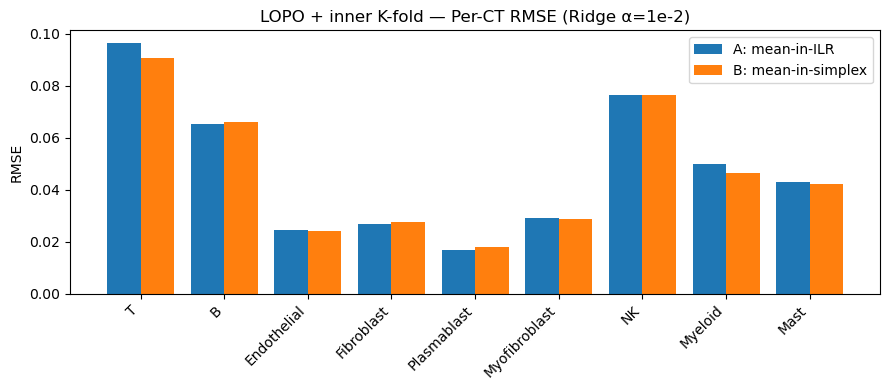

In [23]:
# Jupyter cell: LOPO (outer) + inner K-fold (~20% val) with Ridge(alpha=1e-2)
# Compare two test-time averaging strategies:
#   (A) mean in ILR → ilr_inv  vs  (B) ilr_inv per fold → mean in simplex
AD_PATH    = r"../train_data/train_adata.h5ad"
BULK_PATH  = r"../train_data/train_bulk.csv"
TRUE_PATH  = r"../train_data/train_bulk_trueprops.csv"

CELLTYPE_COL   = "highLevelType"
TARGET_ORDER   = ["T","B","Endothelial","Fibroblast","Plasmablast","Myofibroblast","NK","Myeloid","Mast"]
MARKER_TOPK_CT = 120         # 每個 cell type 取 Top-50 marker（ComBat-first，僅用 inner-train 病人）
INNER_N_FOLDS  = 5          # 內圈 K（若其餘病人太少會自動縮小）
SEED           = 42

import re, numpy as np, pandas as pd, matplotlib.pyplot as plt
from typing import List, Dict, Tuple
from sklearn.model_selection import KFold
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge

# -------- utils --------
def need_scanpy():
    import scanpy as sc
    return sc

def preprocess_sc(ad):
    sc = need_scanpy()
    sc.pp.filter_cells(ad, min_genes=200)
    sc.pp.filter_genes(ad, min_cells=3)
    sc.pp.normalize_total(ad, target_sum=1e4)
    sc.pp.log1p(ad)

def pseudobulk_by_sample_ct(ad, ct_col: str, sample_col: str) -> pd.DataFrame:
    obs = ad.obs[[ct_col, sample_col]].astype(str)
    groups = obs.groupby([sample_col, ct_col]).indices
    cols, names = [], []
    for (s, ct), idx in groups.items():
        Xi = ad.X[idx]
        cols.append(np.asarray(Xi.mean(axis=0)).ravel()); names.append(f"{s}|{ct}")
    return pd.DataFrame(np.column_stack(cols), index=ad.var_names.astype(str), columns=names)

def combat_on_pb(pb: pd.DataFrame) -> pd.DataFrame:
    sc = need_scanpy()
    ad = sc.AnnData(pb.T.copy())
    ad.obs["batch"] = pd.Categorical([c.split("|",1)[0] for c in pb.columns])  # batch=Sample
    sc.pp.combat(ad, key="batch")
    return pd.DataFrame(ad.X.T, index=pb.index, columns=pb.columns)

def stratified_marker_union(pb: pd.DataFrame, topk_per_ct: int, ct_order: List[str]) -> List[str]:
    cts = sorted({c.split("|",1)[1] for c in pb.columns})
    order = [ct for ct in ct_order if ct in cts] + [ct for ct in cts if ct not in ct_order]
    mean_all = pb.mean(axis=1) + 1e-9
    sel = set()
    for ct in order:
        cols = [c for c in pb.columns if c.split("|",1)[1]==ct]
        if not cols: continue
        m_ct = pb[cols].mean(axis=1)
        rest = (mean_all * len(cts) - m_ct) / max(1e-12, (len(cts)-1))
        score = np.log2((m_ct+1e-9)/(rest+1e-9)).sort_values(ascending=False)
        sel.update(score.index[:topk_per_ct])
    return list(sel)

def cpm_log1p_bulk(df: pd.DataFrame) -> pd.DataFrame:
    lib = df.sum(axis=0); lib[lib==0]=1.0
    return np.log1p(df.div(lib, axis=1) * 1e4)

def parse_sample_from_bulk_col(col: str) -> str:
    # 's1_0' -> 's1'
    m = re.match(r"^(s\d+)", str(col).lower())
    return m.group(1) if m else str(col)

def simplex_proj(v: np.ndarray) -> np.ndarray:
    # 精確投影到 simplex（sum=1, >=0）
    u = np.sort(v)[::-1]
    cssv = np.cumsum(u)
    rho = np.nonzero(u * np.arange(1, len(u)+1) > (cssv - 1))[0][-1]
    theta = (cssv[rho] - 1) / (rho + 1.0)
    return np.maximum(v - theta, 0.0)

# ILR transforms
def helmert_basis(K: int) -> np.ndarray:
    H = np.zeros((K, K-1))
    for i in range(1, K):
        a = np.ones(i)/i
        H[:i, i-1] = a
        H[i,   i-1] = -1.0
    for j in range(K-1):
        col = H[:, j]; H[:, j] = col / (np.linalg.norm(col) + 1e-12)
    return H

def ilr(p: np.ndarray, H: np.ndarray) -> np.ndarray:
    eps = 1e-12
    p = np.maximum(p, eps)
    p = p / p.sum(axis=-1, keepdims=True)
    return np.log(p) @ H

def ilr_inv(z: np.ndarray, H: np.ndarray) -> np.ndarray:
    logp = z @ H.T
    x = np.exp(logp)
    return x / x.sum(axis=-1, keepdims=True)

# -------- load --------
sc = need_scanpy()
adata = sc.read_h5ad(AD_PATH)
bulk_raw = pd.read_csv(BULK_PATH, index_col=0).apply(pd.to_numeric, errors="coerce").fillna(0.0)
truth    = pd.read_csv(TRUE_PATH, index_col=0)
for ct in TARGET_ORDER:
    if ct not in truth.index:
        truth.loc[ct] = 0.0

if CELLTYPE_COL not in adata.obs:
    if "cell_type" in adata.obs: CELLTYPE_COL = "cell_type"
    else: raise KeyError("missing cell-type column in adata.obs")
if "Sample" not in adata.obs or "Patient" not in adata.obs:
    raise KeyError("adata.obs needs 'Sample' and 'Patient'")

# sc preprocess
preprocess_sc(adata)

# bulk transform（你之前已確認 gene 名一致，這裡仍做清洗以保險）
B_all = cpm_log1p_bulk(bulk_raw)

# 映射 sample -> patient（由 adata.obs 提供）
samples_bulk = B_all.columns.tolist()
sample_to_patient = adata.obs[["Sample","Patient"]].drop_duplicates().set_index("Sample")["Patient"].astype(str)
col_to_sample  = {c: parse_sample_from_bulk_col(c) for c in samples_bulk}
col_to_patient = {c: sample_to_patient.get(col_to_sample[c], "UNK") for c in samples_bulk}

# 僅保留能對應到病人的樣本
keep_cols = [c for c in samples_bulk if col_to_patient[c]!="UNK"]
B_all = B_all[keep_cols]
T_all = truth.loc[TARGET_ORDER, keep_cols].T  # (n_samples × K)
patients_all = sorted({col_to_patient[c] for c in B_all.columns})

# ILR basis
Kc = len(TARGET_ORDER)
H = helmert_basis(Kc)

# -------- LOPO (outer) + inner K-fold --------
# 兩種平均策略的容器
predsA_by_sample: Dict[str, List[np.ndarray]] = {}  # strategy A: collect z_pred (ILR) for each test sample
predsB_by_sample: Dict[str, List[np.ndarray]] = {}  # strategy B: collect y_pred (simplex) for each test sample
truth_by_sample:  Dict[str, np.ndarray]      = {}  # ground truth per sample
patient_of_col:   Dict[str, str]             = {}  # sample -> patient

for p_test in patients_all:
    test_cols = [c for c in B_all.columns if col_to_patient[c]==p_test]
    if len(test_cols) == 0:
        continue

    others = [p for p in patients_all if p != p_test]
    if len(others) == 0:
        continue

    # inner folds ≈ 20% val → K=5；如果其餘病人太少，自動縮小
    K_inner = min(INNER_N_FOLDS, max(1, len(others)))
    kf = KFold(n_splits=K_inner, shuffle=True, random_state=SEED)
    others_arr = np.array(others)

    # 對此 test 病人的所有 inner folds 收集預測
    bagA_z: Dict[str, List[np.ndarray]] = {c: [] for c in test_cols}
    bagB_y: Dict[str, List[np.ndarray]] = {c: [] for c in test_cols}

    for in_id, (tr_mask, va_mask) in enumerate(kf.split(others_arr), 1):
        in_tr_pats = set(others_arr[tr_mask].tolist())
        # 用 inner-train 病人決定 markers（避免洩漏 test）
        ad_tr = adata[adata.obs["Patient"].astype(str).isin(in_tr_pats)].copy()
        
        pb_all = pseudobulk_by_sample_ct(ad_tr, CELLTYPE_COL, "Sample")
        pb_all = combat_on_pb(pb_all)  # ComBat-first for marker selection
        markers = stratified_marker_union(pb_all, topk_per_ct=MARKER_TOPK_CT, ct_order=TARGET_ORDER)

        genes_used = B_all.index.intersection(markers)

        # inner-train bulk/labels
        tr_cols_inner = [c for c in B_all.columns if col_to_patient[c] in in_tr_pats]
        X_in_tr = B_all.loc[genes_used, tr_cols_inner].T
        y_in_tr = T_all.loc[tr_cols_inner].values
        z_in_tr = ilr(y_in_tr, H)

        # ridge multi-output
        model = MultiOutputRegressor(Ridge(alpha=1e-2, random_state=SEED))
        model.fit(X_in_tr, z_in_tr)

        # 對本 outer test 病人的樣本做預測
        X_te = B_all.loc[genes_used, test_cols].T
        z_pred = model.predict(X_te)      # (n_test_for_patient × K-1)
        y_pred = ilr_inv(z_pred, H)       # 回到比例
        y_pred = np.vstack([simplex_proj(row) for row in y_pred])

        # 收集到兩個袋子：A=ILR袋、B=Simplex袋
        for i, col in enumerate(test_cols):
            bagA_z[col].append(z_pred[i])
            bagB_y[col].append(y_pred[i])

    # 對此 test 病人的每個 sample 做聚合 & 存入全域結果
    for col in test_cols:
        # ground truth
        truth_by_sample[col] = T_all.loc[col].values
        patient_of_col[col]  = p_test

        # Strategy A: mean in ILR
        if len(bagA_z[col]) > 0:
            z_mean = np.mean(np.vstack(bagA_z[col]), axis=0)
            yA = ilr_inv(z_mean[None, :], H)[0]
            yA = simplex_proj(yA)
        else:
            yA = np.ones(Kc)/Kc
        predsA_by_sample.setdefault(col, []).append(yA)

        # Strategy B: ilr_inv per fold → mean in simplex
        if len(bagB_y[col]) > 0:
            y_mean = np.mean(np.vstack(bagB_y[col]), axis=0)
            y_mean = simplex_proj(y_mean)
        else:
            y_mean = np.ones(Kc)/Kc
        predsB_by_sample.setdefault(col, []).append(y_mean)

# -------- 評估：聚合（其實每個 sample 已是一個均值；保留架構以便擴充） --------
def stack_preds(d: Dict[str, List[np.ndarray]]) -> Tuple[np.ndarray, List[str]]:
    cols = sorted(d.keys())
    Y = []
    for c in cols:
        arr = np.vstack(d[c])
        y = arr.mean(axis=0)     # 若未來你想對不同 inner 給不同權重，可在這裡改
        y = simplex_proj(y)
        Y.append(y)
    return np.vstack(Y), cols

Y_true = np.vstack([truth_by_sample[c] for c in sorted(truth_by_sample.keys())])
Y_predA, colsA = stack_preds(predsA_by_sample)
Y_predB, colsB = stack_preds(predsB_by_sample)

# 對齊（理論上兩者 key 應一致）
assert colsA == colsB
cols_eval = colsA
patients_eval = [patient_of_col[c] for c in cols_eval]

def rmse_by_axis(Yp: np.ndarray, Yt: np.ndarray) -> Tuple[float, pd.Series]:
    rmse_ct = np.sqrt(((Yp - Yt)**2).mean(axis=0))
    return float(rmse_ct.mean()), pd.Series(rmse_ct, index=TARGET_ORDER)

avgA, perctA = rmse_by_axis(Y_predA, Y_true)
avgB, perctB = rmse_by_axis(Y_predB, Y_true)

print("\n=== LOPO + inner K-fold (test averaged) — Summary ===")
print(f"Marker per CT = {MARKER_TOPK_CT} | INNER folds up to {INNER_N_FOLDS}")
print(f"Total test samples evaluated = {len(cols_eval)}")
print(f"[A] mean-in-ILR  → ilr_inv : Avg RMSE = {avgA:.4f}")
print(f"[B] ilr_inv-per-fold → mean: Avg RMSE = {avgB:.4f}")

print("\nPer-CT RMSE — Strategy A (mean in ILR):")
print(perctA.round(4).to_string())
print("\nPer-CT RMSE — Strategy B (mean in simplex):")
print(perctB.round(4).to_string())

# -------- per-patient × per-CT RMSE --------
df_eval = pd.DataFrame({
    "patient": patients_eval,
    "sample": cols_eval
})
df_eval["y_true"]  = list(Y_true)
df_eval["y_predA"] = list(Y_predA)
df_eval["y_predB"] = list(Y_predB)

def per_patient_ct_rmse(df: pd.DataFrame, which: str) -> pd.DataFrame:
    rows = []
    for p, sub in df.groupby("patient"):
        Yt = np.vstack(sub["y_true"].values)
        Yp = np.vstack(sub[which].values)
        rmse_ct = np.sqrt(((Yp - Yt)**2).mean(axis=0))
        rows.append(pd.Series(rmse_ct, index=TARGET_ORDER, name=p))
    out = pd.DataFrame(rows)
    return out.sort_index()

ppA = per_patient_ct_rmse(df_eval, "y_predA")
ppB = per_patient_ct_rmse(df_eval, "y_predB")

print("\n=== Per-Patient × Per-CT RMSE — Strategy A (mean in ILR) ===")
print(ppA.round(4).to_string())
print("\n=== Per-Patient × Per-CT RMSE — Strategy B (mean in simplex) ===")
print(ppB.round(4).to_string())

# -------- 可視化（兩種策略的 per-CT 對比） --------
x = np.arange(len(TARGET_ORDER))
plt.figure(figsize=(9,4))
w = 0.4
plt.bar(x - w/2, perctA.values, w, label="A: mean-in-ILR")
plt.bar(x + w/2, perctB.values, w, label="B: mean-in-simplex")
plt.xticks(x, TARGET_ORDER, rotation=45, ha="right")
plt.ylabel("RMSE")
plt.title("LOPO + inner K-fold — Per-CT RMSE (Ridge α=1e-2)")
plt.legend()
plt.tight_layout(); plt.show()


Found 3 genes with zero variance.
Found 2 genes with zero variance.
Found 2 genes with zero variance.
Found 4 genes with zero variance.
Found 2 genes with zero variance.
Found 4 genes with zero variance.
Found 3 genes with zero variance.
Found 2 genes with zero variance.

=== TRAIN EVAL — LOPO + inner K-fold | ilr_inv-per-fold → mean (simplex) | NO PCA ===
Joint preprocess: CP10k + winsor(True, q=0.995) + asinh(True, c=1.0)
INNER folds up to 5 | Ridge α=0.01
Total train samples evaluated = 12
Avg RMSE = 0.0463
Per-CT RMSE:
T                0.0905
B                0.0650
Endothelial      0.0242
Fibroblast       0.0268
Plasmablast      0.0180
Myofibroblast    0.0290
NK               0.0764
Myeloid          0.0449
Mast             0.0423


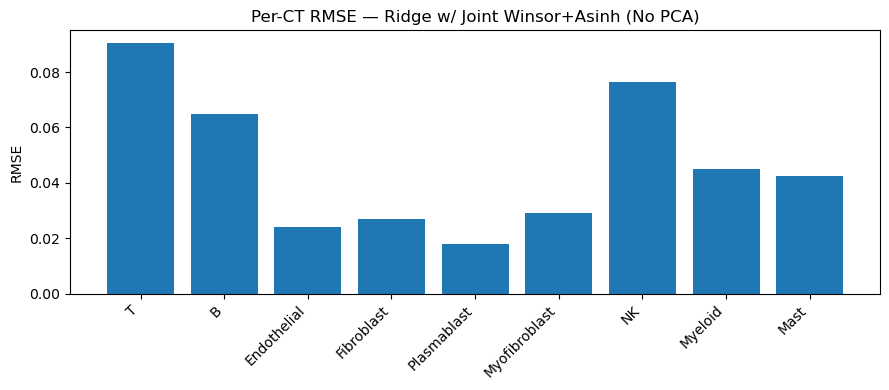


=== TEST PREDICTIONS (simplex, sum=1 per sample) ===
             T         B  Endothelial  Fibroblast  Plasmablast  Myofibroblast  \
s5_0  0.459365  0.134252     0.029378    0.061448     0.043832       0.077522   
s5_1  0.494905  0.134238     0.029411    0.078450     0.005863       0.058986   
s5_2  0.477760  0.176160     0.033438    0.044023     0.017971       0.075701   
s5_3  0.492408  0.125346     0.030041    0.075275     0.013532       0.065657   
s5_4  0.490713  0.161515     0.031516    0.064147     0.008664       0.063676   

            NK   Myeloid      Mast  
s5_0  0.141169  0.039044  0.013991  
s5_1  0.154464  0.026794  0.016890  
s5_2  0.102704  0.061122  0.011123  
s5_3  0.144140  0.034026  0.019573  
s5_4  0.118547  0.044730  0.016493  


In [30]:
# Jupyter cell: Joint-preproc bulk (train+test, no PCA) + LOPO(inner K) Ridge(ILR)
# Strategy: ilr_inv-per-fold → mean in simplex
from __future__ import annotations
import re, numpy as np, pandas as pd, matplotlib.pyplot as plt, random, warnings
warnings.filterwarnings("ignore")

# ===== PATHS =====
AD_TRAIN_PATH   = r"../train_data/train_adata.h5ad"
AD_TEST_PATH    = r"../test_data/test_adata.h5ad"         # 不參與 marker（僅保留以備擴充）
BULK_TRAIN_PATH = r"../train_data/train_bulk.csv"         # genes × n_train
BULK_TEST_PATH  = r"../test_data/test_bulk.csv"           # genes × n_test
TRUE_PATH       = r"../train_data/train_bulk_trueprops.csv"

# ===== SETTINGS =====
CELLTYPE_COL   = "highLevelType"
TARGET_ORDER   = ["T","B","Endothelial","Fibroblast","Plasmablast","Myofibroblast","NK","Myeloid","Mast"]
MARKER_TOPK_CT = 120
INNER_N_FOLDS  = 5
RIDGE_ALPHA    = 1e-2
SEED           = 42

# ---- Joint bulk preprocess (train+test together; NO PCA) ----
GLOBAL_WINSORIZE = True
GLOBAL_WINSOR_Q  = 0.995
GLOBAL_ASINH     = True
GLOBAL_ASINH_C   = 1.0

np.random.seed(SEED); random.seed(SEED)

# ===== utils =====
def need_scanpy():
    import scanpy as sc
    return sc

def preprocess_sc(ad):
    sc = need_scanpy()
    sc.pp.filter_cells(ad, min_genes=200)
    sc.pp.filter_genes(ad, min_cells=3)
    sc.pp.normalize_total(ad, target_sum=1e4)
    sc.pp.log1p(ad)

def pseudobulk_by_sample_ct(ad, ct_col: str, sample_col: str) -> pd.DataFrame:
    obs = ad.obs[[ct_col, sample_col]].astype(str)
    groups = obs.groupby([sample_col, ct_col]).indices
    cols, names = [], []
    for (s, ct), idx in groups.items():
        Xi = ad.X[idx]
        cols.append(np.asarray(Xi.mean(axis=0)).ravel()); names.append(f"{s}|{ct}")
    return pd.DataFrame(np.column_stack(cols), index=ad.var_names.astype(str), columns=names)

def combat_on_pb(pb: pd.DataFrame) -> pd.DataFrame:
    sc = need_scanpy()
    ad = sc.AnnData(pb.T.copy())
    ad.obs["batch"] = pd.Categorical([c.split("|",1)[0] for c in pb.columns])  # batch = Sample
    sc.pp.combat(ad, key="batch")
    return pd.DataFrame(ad.X.T, index=pb.index, columns=pb.columns)

def stratified_marker_union(pb: pd.DataFrame, topk_per_ct: int, ct_order: list[str]) -> list[str]:
    cts = sorted({c.split("|",1)[1] for c in pb.columns})
    order = [ct for ct in ct_order if ct in cts] + [ct for ct in cts if ct not in ct_order]
    mean_all = pb.mean(axis=1) + 1e-9
    sel = set()
    for ct in order:
        cols = [c for c in pb.columns if c.split("|",1)[1]==ct]
        if not cols: continue
        m_ct = pb[cols].mean(axis=1)
        rest = (mean_all * len(cts) - m_ct) / max(1e-12, (len(cts)-1))
        score = np.log2((m_ct+1e-9)/(rest+1e-9)).sort_values(ascending=False)
        sel.update(score.index[:topk_per_ct])
    return list(sel)

def cpm10k(df: pd.DataFrame) -> pd.DataFrame:
    lib = df.sum(axis=0).astype(float); lib[lib==0.0] = 1.0
    return df.div(lib, axis=1) * 1e4

def winsorize_per_gene_pairwise(Btr: pd.DataFrame, Bte: pd.DataFrame, q: float) -> tuple[pd.DataFrame, pd.DataFrame]:
    joint = pd.concat([Btr, Bte], axis=1)
    up = joint.quantile(q, axis=1)
    return Btr.clip(lower=0.0, upper=up, axis=0), Bte.clip(lower=0.0, upper=up, axis=0)

def asinh_vst(df: pd.DataFrame, c: float = 1.0) -> pd.DataFrame:
    return np.arcsinh(df / float(c))

def parse_sample_from_bulk_col(col: str) -> str:
    m = re.match(r"^(s\d+)", str(col).lower())
    return m.group(1) if m else str(col)

def simplex_proj(v: np.ndarray) -> np.ndarray:
    u = np.sort(v)[::-1]; cssv = np.cumsum(u)
    rho = np.nonzero(u * np.arange(1, len(u)+1) > (cssv - 1))[0][-1]
    theta = (cssv[rho] - 1) / (rho + 1.0)
    return np.maximum(v - theta, 0.0)

# ILR
def helmert_basis(K: int) -> np.ndarray:
    H = np.zeros((K, K-1))
    for i in range(1, K):
        a = np.ones(i)/i
        H[:i, i-1] = a
        H[i,   i-1] = -1.0
    for j in range(K-1):
        col = H[:, j]; H[:, j] = col / (np.linalg.norm(col) + 1e-12)
    return H

def ilr(p: np.ndarray, H: np.ndarray) -> np.ndarray:
    eps = 1e-12
    p = np.maximum(p, eps)
    p = p / p.sum(axis=-1, keepdims=True)
    return np.log(p) @ H

def ilr_inv(z: np.ndarray, H: np.ndarray) -> np.ndarray:
    logp = z @ H.T
    x = np.exp(logp)
    return x / x.sum(axis=-1, keepdims=True)

# ===== load =====
sc = need_scanpy()
ad_tr = need_scanpy().read_h5ad(AD_TRAIN_PATH)
ad_te = need_scanpy().read_h5ad(AD_TEST_PATH)  # 不參與 marker；保留以備擴充
bulk_tr_raw = pd.read_csv(BULK_TRAIN_PATH, index_col=0).apply(pd.to_numeric, errors="coerce").fillna(0.0)
bulk_te_raw = pd.read_csv(BULK_TEST_PATH,  index_col=0).apply(pd.to_numeric, errors="coerce").fillna(0.0)
truth       = pd.read_csv(TRUE_PATH, index_col=0)

# genes 對齊
genes = bulk_tr_raw.index.intersection(bulk_te_raw.index).astype(str)
bulk_tr_raw = bulk_tr_raw.loc[genes].astype(float)
bulk_te_raw = bulk_te_raw.loc[genes].astype(float)

# train sc preprocess（只用它選 marker）
preprocess_sc(ad_tr)

# ---- Joint bulk preprocess（CP10k + joint winsor + joint asinh；無 PCA）----
Btr = cpm10k(bulk_tr_raw.copy())
Bte = cpm10k(bulk_te_raw.copy())
if GLOBAL_WINSORIZE:
    Btr, Bte = winsorize_per_gene_pairwise(Btr, Bte, GLOBAL_WINSOR_Q)
if GLOBAL_ASINH:
    Btr = asinh_vst(Btr, GLOBAL_ASINH_C)
    Bte = asinh_vst(Bte, GLOBAL_ASINH_C)

B_all  = Btr   # genes × n_train
B_test = Bte   # genes × n_test

# train truth 對齊
for ct in TARGET_ORDER:
    if ct not in truth.index: truth.loc[ct] = 0.0
T_all = truth.loc[TARGET_ORDER, B_all.columns].T  # (n_train × K)

# sample -> patient（train）
if CELLTYPE_COL not in ad_tr.obs:
    if "cell_type" in ad_tr.obs: CELLTYPE_COL = "cell_type"
    else: raise KeyError("missing cell-type column in train adata.obs")
if "Sample" not in ad_tr.obs or "Patient" not in ad_tr.obs:
    raise KeyError("train adata.obs needs 'Sample' and 'Patient'")

sample_to_patient = ad_tr.obs[["Sample","Patient"]].drop_duplicates().set_index("Sample")["Patient"].astype(str)
col_to_sample_train  = {c: parse_sample_from_bulk_col(c) for c in B_all.columns}
col_to_patient_train = {c: sample_to_patient.get(col_to_sample_train[c], "UNK") for c in B_all.columns}

keep_cols = [c for c in B_all.columns if col_to_patient_train[c]!="UNK" and c in T_all.index]
B_all = B_all[keep_cols]
T_all = T_all.loc[keep_cols]
patients_all = sorted({col_to_patient_train[c] for c in keep_cols})

# ILR basis
Kc = len(TARGET_ORDER); H = helmert_basis(Kc)

# ===== LOPO + inner K-fold（ilr_inv per fold → mean in simplex）=====
from sklearn.model_selection import KFold
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge

# containers（train eval）
preds_by_sample_train: dict[str, list[np.ndarray]] = {}
truth_by_sample_train: dict[str, np.ndarray] = {}
patient_of_col_train: dict[str, str] = {}

# containers（real test）
bag_y_test_allfolds: dict[str, list[np.ndarray]] = {c: [] for c in B_test.columns}

for p_test in patients_all:
    test_cols_train_outer = [c for c in B_all.columns if col_to_patient_train[c]==p_test]
    if not test_cols_train_outer: continue

    others = [p for p in patients_all if p != p_test]
    if not others: continue

    K_inner = min(INNER_N_FOLDS, max(1, len(others)))
    kf = KFold(n_splits=K_inner, shuffle=True, random_state=SEED)
    others_arr = np.array(others)

    bag_y_train_outer: dict[str, list[np.ndarray]] = {c: [] for c in test_cols_train_outer}

    for in_id, (tr_mask, _) in enumerate(kf.split(others_arr), 1):
        in_tr_pats = set(others_arr[tr_mask].tolist())

        # 只用 inner-train 病人的 train 單細胞選 marker
        ad_inner = ad_tr[ad_tr.obs["Patient"].astype(str).isin(in_tr_pats)].copy()
        if ad_inner.n_obs < 10: continue

        # pseudobulk → ComBat（batch=Sample）
        pb_all = pseudobulk_by_sample_ct(ad_inner, CELLTYPE_COL, "Sample")
        pb_all = combat_on_pb(pb_all)

        # per-CT TopK union markers
        markers = stratified_marker_union(pb_all, topk_per_ct=MARKER_TOPK_CT, ct_order=TARGET_ORDER)

        # genes_used：落在 joint 前處理後的 train/test 交集
        genes_used = pd.Index(markers, dtype=str).intersection(B_all.index).intersection(B_test.index)
        if len(genes_used) < 20: continue

        # 準備矩陣（samples×genes_used），**不做 PCA**
        tr_cols_inner = [c for c in B_all.columns if col_to_patient_train[c] in in_tr_pats]
        if len(tr_cols_inner) < 2: continue

        X_tr_sg    = B_all.loc[genes_used, tr_cols_inner].T
        X_te_train = B_all.loc[genes_used, test_cols_train_outer].T
        X_te_real  = B_test.loc[genes_used, B_test.columns].T

        # Ridge on ILR
        y_in_tr = T_all.loc[tr_cols_inner].values
        z_in_tr = ilr(y_in_tr, H)
        model = MultiOutputRegressor(Ridge(alpha=RIDGE_ALPHA, random_state=SEED))
        model.fit(X_tr_sg, z_in_tr)

        # train outer-test
        z_pred_train = model.predict(X_te_train)
        y_pred_train = ilr_inv(z_pred_train, H)
        y_pred_train = np.vstack([simplex_proj(row) for row in y_pred_train])
        for i, col in enumerate(test_cols_train_outer):
            bag_y_train_outer[col].append(y_pred_train[i])

        # real test
        z_pred_real = model.predict(X_te_real)
        y_pred_real = ilr_inv(z_pred_real, H)
        y_pred_real = np.vstack([simplex_proj(row) for row in y_pred_real])
        for i, col in enumerate(B_test.columns):
            bag_y_test_allfolds[col].append(y_pred_real[i])

    # 此 outer 的 train 外測聚合
    for col in test_cols_train_outer:
        truth_by_sample_train[col] = T_all.loc[col].values
        patient_of_col_train[col]  = p_test
        if len(bag_y_train_outer[col]) > 0:
            y_mean = simplex_proj(np.mean(np.vstack(bag_y_train_outer[col]), axis=0))
        else:
            y_mean = np.ones(Kc)/Kc
        preds_by_sample_train.setdefault(col, []).append(y_mean)

# ===== 訓練集評估（train outer-test）=====
cols_eval = sorted(truth_by_sample_train.keys())
Y_true = np.vstack([truth_by_sample_train[c] for c in cols_eval])
Y_pred = np.vstack([simplex_proj(np.vstack(preds_by_sample_train[c]).mean(axis=0)) for c in cols_eval])

rmse_ct = np.sqrt(((Y_pred - Y_true)**2).mean(axis=0))
avg_rmse = float(rmse_ct.mean()); per_ct = pd.Series(rmse_ct, index=TARGET_ORDER)

print("\n=== TRAIN EVAL — LOPO + inner K-fold | ilr_inv-per-fold → mean (simplex) | NO PCA ===")
print(f"Joint preprocess: CP10k + winsor({GLOBAL_WINSORIZE}, q={GLOBAL_WINSOR_Q}) + asinh({GLOBAL_ASINH}, c={GLOBAL_ASINH_C})")
print(f"INNER folds up to {INNER_N_FOLDS} | Ridge α={RIDGE_ALPHA}")
print(f"Total train samples evaluated = {len(cols_eval)}")
print(f"Avg RMSE = {avg_rmse:.4f}\nPer-CT RMSE:")
print(per_ct.round(4).to_string())

plt.figure(figsize=(9,4))
plt.bar(TARGET_ORDER, per_ct.values)
plt.xticks(rotation=45, ha="right"); plt.ylabel("RMSE")
plt.title("Per-CT RMSE — Ridge w/ Joint Winsor+Asinh (No PCA)")
plt.tight_layout(); plt.show()

# ===== 真 TEST 聚合：ilr_inv-per-fold → mean in simplex（跨所有 outer×inner）=====
Y_test_final = []
for col in B_test.columns:
    if len(bag_y_test_allfolds[col]) > 0:
        y_mean = simplex_proj(np.mean(np.vstack(bag_y_test_allfolds[col]), axis=0))
    else:
        y_mean = np.ones(Kc)/Kc
    Y_test_final.append(y_mean)
Y_test_final = np.vstack(Y_test_final)

df_test_pred = pd.DataFrame(Y_test_final, index=B_test.columns, columns=TARGET_ORDER)
print("\n=== TEST PREDICTIONS (simplex, sum=1 per sample) ===")
print(df_test_pred.head())

# 可選：存檔
# df_test_pred.to_csv("../predictions/test_props_joint_noPCA_ridge.csv")


Found 3 genes with zero variance.
Found 2 genes with zero variance.
Found 2 genes with zero variance.
Found 4 genes with zero variance.
Found 2 genes with zero variance.
Found 4 genes with zero variance.
Found 3 genes with zero variance.
Found 2 genes with zero variance.

=== LOPO + inner K-fold — mean-in-simplex | A/B: HVG4000→ComBat vs AllGenes→ComBat ===
    HVG4000→ComBat | Avg RMSE = 0.0477
T                0.0931
B                0.0651
Endothelial      0.0240
Fibroblast       0.0270
Plasmablast      0.0188
Myofibroblast    0.0291
NK               0.0783
Myeloid          0.0513
Mast             0.0422
----------------------------------------------------------------------
   AllGenes→ComBat | Avg RMSE = 0.0467
T                0.0908
B                0.0660
Endothelial      0.0241
Fibroblast       0.0277
Plasmablast      0.0180
Myofibroblast    0.0288
NK               0.0763
Myeloid          0.0466
Mast             0.0423
-----------------------------------------------------------

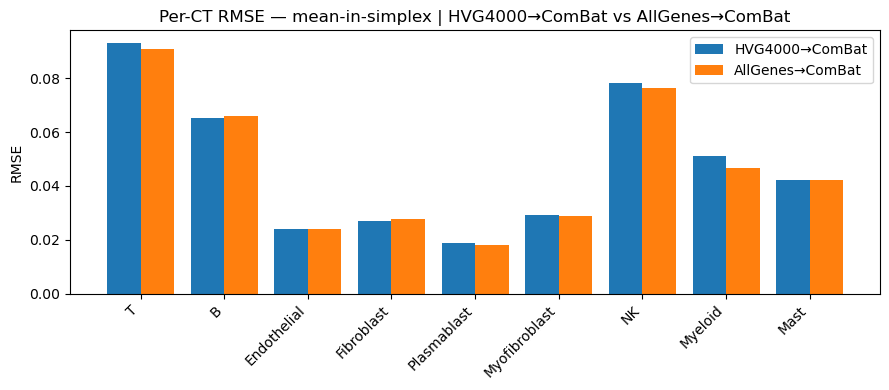


=== Per-Patient × Per-CT RMSE — HVG4000→ComBat ===
         T       B  Endothelial  Fibroblast  Plasmablast  Myofibroblast      NK  Myeloid    Mast
P1  0.0457  0.0302       0.0023      0.0463       0.0044         0.0148  0.0139   0.0206  0.0216
P2  0.0860  0.0248       0.0040      0.0111       0.0295         0.0317  0.0514   0.0672  0.0923
P3  0.0393  0.0402       0.0186      0.0202       0.0242         0.0361  0.0862   0.0298  0.0217
P4  0.1788  0.0487       0.0042      0.0340       0.0086         0.0070  0.1472   0.0780  0.0222
P7  0.0673  0.0998       0.0391      0.0166       0.0170         0.0353  0.0491   0.0440  0.0190

=== Per-Patient × Per-CT RMSE — AllGenes→ComBat ===
         T       B  Endothelial  Fibroblast  Plasmablast  Myofibroblast      NK  Myeloid    Mast
P1  0.0610  0.0292       0.0035      0.0463       0.0047         0.0133  0.0099   0.0144  0.0248
P2  0.0745  0.0267       0.0031      0.0136       0.0289         0.0301  0.0452   0.0424  0.0920
P3  0.0430  0.0418    

In [67]:
# Jupyter cell: LOPO (outer) + inner K-fold (~20% val) with Ridge(alpha=1e-2)
# 固定測試端：mean in simplex（ilr_inv per fold → 平均）
# A/B 變數：marker 來源
#   A = HVG4000→ComBat（inner-train 病人的 sc 先取 HVG 4000 後做 pseudo-bulk+ComBat）
#   B = AllGenes→ComBat（inner-train 病人全基因 pseudo-bulk+ComBat）
AD_PATH    = r"../train_data/train_adata.h5ad"
BULK_PATH  = r"../train_data/train_bulk.csv"
TRUE_PATH  = r"../train_data/train_bulk_trueprops.csv"

CELLTYPE_COL   = "highLevelType"
TARGET_ORDER   = ["T","B","Endothelial","Fibroblast","Plasmablast","Myofibroblast","NK","Myeloid","Mast"]
MARKER_TOPK_CT = 120
INNER_N_FOLDS  = 5
SEED           = 42

import re, numpy as np, pandas as pd, matplotlib.pyplot as plt
from typing import List, Dict, Tuple
from sklearn.model_selection import KFold
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge
import warnings
warnings.filterwarnings("ignore")

# -------- utils --------
def need_scanpy():
    import scanpy as sc
    return sc

def preprocess_sc(ad):
    sc = need_scanpy()
    sc.pp.filter_cells(ad, min_genes=200)
    sc.pp.filter_genes(ad, min_cells=3)
    sc.pp.normalize_total(ad, target_sum=1e4)
    sc.pp.log1p(ad)

def select_hvg_view(ad, n_top=4000, flavor="seurat_v3"):
    """回傳 ad[:, HVG] 的 *view*（不複製 X），供 pseudo-bulk 使用。"""
    sc = need_scanpy()
    ad = ad.copy()  # 需要在 ad.var 上標記 HVG
    sc.pp.highly_variable_genes(ad, n_top_genes=n_top, flavor=flavor)
    hvg_mask = ad.var["highly_variable"].values
    return ad[:, hvg_mask]

def pseudobulk_by_sample_ct(ad, ct_col: str, sample_col: str) -> pd.DataFrame:
    obs = ad.obs[[ct_col, sample_col]].astype(str)
    groups = obs.groupby([sample_col, ct_col]).indices
    cols, names = [], []
    for (s, ct), idx in groups.items():
        Xi = ad.X[idx]
        cols.append(np.asarray(Xi.mean(axis=0)).ravel()); names.append(f"{s}|{ct}")
    return pd.DataFrame(np.column_stack(cols), index=ad.var_names.astype(str), columns=names)

def combat_on_pb(pb: pd.DataFrame) -> pd.DataFrame:
    sc = need_scanpy()
    ad = sc.AnnData(pb.T.copy())
    ad.obs["batch"] = pd.Categorical([c.split("|",1)[0] for c in pb.columns])  # batch=Sample
    sc.pp.combat(ad, key="batch")
    return pd.DataFrame(ad.X.T, index=pb.index, columns=pb.columns)

def stratified_marker_union(pb: pd.DataFrame, topk_per_ct: int, ct_order: List[str]) -> List[str]:
    cts = sorted({c.split("|",1)[1] for c in pb.columns})
    order = [ct for ct in ct_order if ct in cts] + [ct for ct in cts if ct not in ct_order]
    mean_all = pb.mean(axis=1) + 1e-9
    sel = set()
    for ct in order:
        cols = [c for c in pb.columns if c.split("|",1)[1]==ct]
        if not cols: continue
        m_ct = pb[cols].mean(axis=1)
        rest = (mean_all * len(cts) - m_ct) / max(1e-12, (len(cts)-1))
        score = np.log2((m_ct+1e-9)/(rest+1e-9)).sort_values(ascending=False)
        sel.update(score.index[:topk_per_ct])
    return list(sel)

def cpm_log1p_bulk(df: pd.DataFrame) -> pd.DataFrame:
    lib = df.sum(axis=0); lib[lib==0]=1.0
    return np.log1p(df.div(lib, axis=1) * 1e4)

def parse_sample_from_bulk_col(col: str) -> str:
    m = re.match(r"^(s\d+)", str(col).lower())
    return m.group(1) if m else str(col)

def simplex_proj(v: np.ndarray) -> np.ndarray:
    # 精確投影到 simplex（sum=1, >=0）
    u = np.sort(v)[::-1]
    cssv = np.cumsum(u)
    rho = np.nonzero(u * np.arange(1, len(u)+1) > (cssv - 1))[0][-1]
    theta = (cssv[rho] - 1) / (rho + 1.0)
    return np.maximum(v - theta, 0.0)

# ILR transforms
def helmert_basis(K: int) -> np.ndarray:
    H = np.zeros((K, K-1))
    for i in range(1, K):
        a = np.ones(i)/i
        H[:i, i-1] = a
        H[i,   i-1] = -1.0
    for j in range(K-1):
        col = H[:, j]; H[:, j] = col / (np.linalg.norm(col) + 1e-12)
    return H

def ilr(p: np.ndarray, H: np.ndarray) -> np.ndarray:
    eps = 1e-12
    p = np.maximum(p, eps)
    p = p / p.sum(axis=-1, keepdims=True)
    return np.log(p) @ H

def ilr_inv(z: np.ndarray, H: np.ndarray) -> np.ndarray:
    logp = z @ H.T
    x = np.exp(logp)
    return x / x.sum(axis=-1, keepdims=True)

# -------- load --------
sc = need_scanpy()
adata = sc.read_h5ad(AD_PATH)
bulk_raw = pd.read_csv(BULK_PATH, index_col=0).apply(pd.to_numeric, errors="coerce").fillna(0.0)
truth    = pd.read_csv(TRUE_PATH, index_col=0)
for ct in TARGET_ORDER:
    if ct not in truth.index:
        truth.loc[ct] = 0.0

if CELLTYPE_COL not in adata.obs:
    if "cell_type" in adata.obs: CELLTYPE_COL = "cell_type"
    else: raise KeyError("missing cell-type column in adata.obs")
if "Sample" not in adata.obs or "Patient" not in adata.obs:
    raise KeyError("adata.obs needs 'Sample' and 'Patient'")

# sc preprocess
preprocess_sc(adata)

# bulk transform
B_all = cpm_log1p_bulk(bulk_raw)

# sample -> patient
samples_bulk = B_all.columns.tolist()
sample_to_patient = adata.obs[["Sample","Patient"]].drop_duplicates().set_index("Sample")["Patient"].astype(str)
col_to_sample  = {c: parse_sample_from_bulk_col(c) for c in samples_bulk}
col_to_patient = {c: sample_to_patient.get(col_to_sample[c], "UNK") for c in samples_bulk}

keep_cols = [c for c in samples_bulk if col_to_patient[c]!="UNK"]
B_all = B_all[keep_cols]
T_all = truth.loc[TARGET_ORDER, keep_cols].T
patients_all = sorted({col_to_patient[c] for c in B_all.columns})

# ILR basis
Kc = len(TARGET_ORDER)
H = helmert_basis(Kc)

def build_markers_from_inner(ad_inner, mode: str) -> List[str]:
    """
    mode: 'HVG4000' or 'AllGenes'
    - HVG4000: 先在 inner-train 病人的 sc 上用 scanpy 抓 HVG=4000，再 pseudo-bulk+ComBat
    - AllGenes: 不限基因，直接 pseudo-bulk+ComBat
    接著在對應的 pseudo-bulk 上用 stratified_marker_union 取每 CT Top-K，回傳 union。
    """
    if mode == "HVG4000":
        ad_sel = select_hvg_view(ad_inner, n_top=1000, flavor="seurat_v3")
        pb = pseudobulk_by_sample_ct(ad_sel, CELLTYPE_COL, "Sample")
    elif mode == "AllGenes":
        pb = pseudobulk_by_sample_ct(ad_inner, CELLTYPE_COL, "Sample")
    else:
        raise ValueError("mode must be 'HVG4000' or 'AllGenes'")
    pb = combat_on_pb(pb)
    markers = stratified_marker_union(pb, topk_per_ct=MARKER_TOPK_CT, ct_order=TARGET_ORDER)
    return markers

# -------- LOPO (outer) + inner K-fold, 固定 mean-in-simplex --------
def run_lopo_compare_modes():
    out = {}
    for mode in ["HVG4000", "AllGenes"]:
        preds_by_sample: Dict[str, List[np.ndarray]] = {}
        truth_by_sample: Dict[str, np.ndarray] = {}
        patient_of_col: Dict[str, str] = {}

        for p_test in patients_all:
            test_cols = [c for c in B_all.columns if col_to_patient[c]==p_test]
            if not test_cols:
                continue

            others = [p for p in patients_all if p != p_test]
            if not others:
                continue

            K_inner = min(INNER_N_FOLDS, max(1, len(others)))
            kf = KFold(n_splits=K_inner, shuffle=True, random_state=SEED)
            others_arr = np.array(others)

            # 對此 test 病人的 inner folds 收集 y_pred（simplex）
            bag_y: Dict[str, List[np.ndarray]] = {c: [] for c in test_cols}

            for _, (tr_mask, va_mask) in enumerate(kf.split(others_arr), 1):
                in_tr_pats = set(others_arr[tr_mask].tolist())
                ad_tr = adata[adata.obs["Patient"].astype(str).isin(in_tr_pats)].copy()
                if ad_tr.n_obs < 10:
                    continue

                # --- 依 mode 建立 markers（僅用 inner-train 病人） ---
                markers = build_markers_from_inner(ad_tr, mode=mode)
                genes_used = B_all.index.intersection(markers)
                if len(genes_used) < 20:
                    continue

                # --- inner-train ---
                tr_cols_inner = [c for c in B_all.columns if col_to_patient[c] in in_tr_pats]
                X_in_tr = B_all.loc[genes_used, tr_cols_inner].T
                y_in_tr = T_all.loc[tr_cols_inner].values
                z_in_tr = ilr(y_in_tr, H)

                model = MultiOutputRegressor(Ridge(alpha=1e-2, random_state=SEED))
                model.fit(X_in_tr, z_in_tr)

                # --- predict outer test ---
                X_te = B_all.loc[genes_used, test_cols].T
                z_pred = model.predict(X_te)
                y_pred = ilr_inv(z_pred, H)
                y_pred = np.vstack([simplex_proj(row) for row in y_pred])

                for i, col in enumerate(test_cols):
                    bag_y[col].append(y_pred[i])

            # 對此 test 病人的每個 sample 做 mean in simplex
            for col in test_cols:
                truth_by_sample[col] = T_all.loc[col].values
                patient_of_col[col]  = p_test
                if len(bag_y[col]) > 0:
                    y_mean = np.mean(np.vstack(bag_y[col]), axis=0)
                    y_mean = simplex_proj(y_mean)
                else:
                    y_mean = np.ones(Kc)/Kc
                preds_by_sample.setdefault(col, []).append(y_mean)

        # 堆疊與評估
        cols_eval = sorted(truth_by_sample.keys())
        Y_true = np.vstack([truth_by_sample[c] for c in cols_eval])
        Y_pred = []
        for c in cols_eval:
            arr = np.vstack(preds_by_sample[c])
            y = simplex_proj(arr.mean(axis=0))
            Y_pred.append(y)
        Y_pred = np.vstack(Y_pred)

        rmse_ct = np.sqrt(((Y_pred - Y_true)**2).mean(axis=0))
        avg_rmse = float(rmse_ct.mean())
        per_ct = pd.Series(rmse_ct, index=TARGET_ORDER)

        # per-patient × per-CT
        df_eval = pd.DataFrame({"patient":[col_to_patient[c] for c in cols_eval],
                                "sample": cols_eval})
        df_eval["y_true"] = list(Y_true)
        df_eval["y_pred"] = list(Y_pred)

        rows = []
        for p, sub in df_eval.groupby("patient"):
            Yt = np.vstack(sub["y_true"].values)
            Yp = np.vstack(sub["y_pred"].values)
            rmse_ct_p = np.sqrt(((Yp - Yt)**2).mean(axis=0))
            rows.append(pd.Series(rmse_ct_p, index=TARGET_ORDER, name=p))
        pp = pd.DataFrame(rows).sort_index()

        out[mode] = (avg_rmse, per_ct, pp)
    return out

# ---------------- Run & report ----------------
results = run_lopo_compare_modes()

print("\n=== LOPO + inner K-fold — mean-in-simplex | A/B: HVG4000→ComBat vs AllGenes→ComBat ===")
tag_map = {"HVG4000":"HVG4000→ComBat", "AllGenes":"AllGenes→ComBat"}
for mode in ["HVG4000", "AllGenes"]:
    avg_rmse, perct, _ = results[mode]
    print(f"{tag_map[mode]:>18} | Avg RMSE = {avg_rmse:.4f}")
    print(perct.round(4).to_string())
    print("-"*70)

# 視覺化：per-CT 對比
perA = results["HVG4000"][1]
perB = results["AllGenes"][1]
x = np.arange(len(TARGET_ORDER))
plt.figure(figsize=(9,4))
w = 0.4
plt.bar(x - w/2, perA.values, w, label="HVG4000→ComBat")
plt.bar(x + w/2, perB.values, w, label="AllGenes→ComBat")
plt.xticks(x, TARGET_ORDER, rotation=45, ha="right")
plt.ylabel("RMSE")
plt.title("Per-CT RMSE — mean-in-simplex | HVG4000→ComBat vs AllGenes→ComBat")
plt.legend()
plt.tight_layout(); plt.show()

print("\n=== Per-Patient × Per-CT RMSE — HVG4000→ComBat ===")
print(results["HVG4000"][2].round(4).to_string())
print("\n=== Per-Patient × Per-CT RMSE — AllGenes→ComBat ===")
print(results["AllGenes"][2].round(4).to_string())


Found 3 genes with zero variance.
Found 2 genes with zero variance.
Found 2 genes with zero variance.
Found 4 genes with zero variance.
Found 2 genes with zero variance.
Found 4 genes with zero variance.
Found 3 genes with zero variance.
Found 2 genes with zero variance.

=== LOPO + inner K-fold — mean-in-simplex | A/B: marker selection scope ===
       InnerTrainMarkers | Avg RMSE = 0.0468
T                0.0912
B                0.0663
Endothelial      0.0242
Fibroblast       0.0281
Plasmablast      0.0182
Myofibroblast    0.0290
NK               0.0759
Myeloid          0.0460
Mast             0.0425
----------------------------------------------------------------------
AllPatientsMarkers (leaky) | Avg RMSE = 0.0469
T                0.0918
B                0.0670
Endothelial      0.0241
Fibroblast       0.0270
Plasmablast      0.0185
Myofibroblast    0.0283
NK               0.0766
Myeloid          0.0463
Mast             0.0423
--------------------------------------------------------

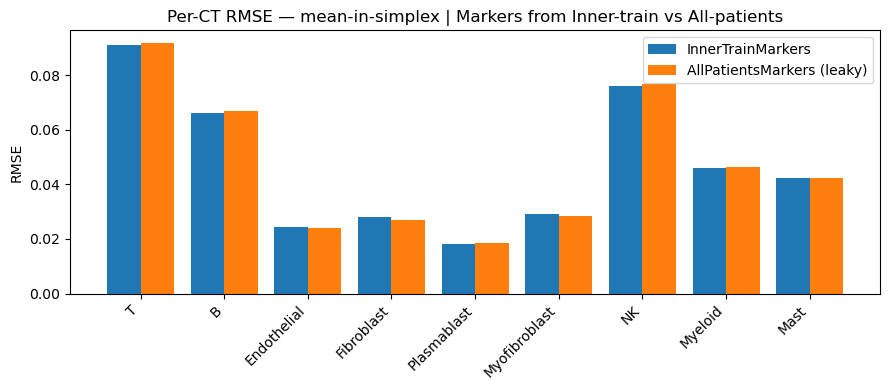


=== Per-Patient × Per-CT RMSE — InnerTrainMarkers ===
         T       B  Endothelial  Fibroblast  Plasmablast  Myofibroblast      NK  Myeloid    Mast
P1  0.0648  0.0292       0.0031      0.0466       0.0079         0.0146  0.0098   0.0154  0.0251
P2  0.0755  0.0249       0.0040      0.0146       0.0290         0.0321  0.0445   0.0402  0.0919
P3  0.0435  0.0437       0.0185      0.0214       0.0234         0.0351  0.0855   0.0296  0.0215
P4  0.1694  0.0520       0.0039      0.0336       0.0084         0.0092  0.1415   0.0799  0.0223
P7  0.0684  0.1007       0.0397      0.0194       0.0154         0.0352  0.0510   0.0424  0.0198

=== Per-Patient × Per-CT RMSE — AllPatientsMarkers (leaky) ===
         T       B  Endothelial  Fibroblast  Plasmablast  Myofibroblast      NK  Myeloid    Mast
P1  0.0636  0.0307       0.0020      0.0461       0.0104         0.0150  0.0112   0.0204  0.0252
P2  0.0756  0.0246       0.0024      0.0151       0.0286         0.0287  0.0449   0.0361  0.0923
P3  0.04

In [65]:
# Jupyter cell: LOPO (outer) + inner K-fold (~20% val) with Ridge(alpha=1e-2)
# 固定測試端平均策略：mean in simplex（先 ilr_inv，每 fold 出一個比例 → 對比例做平均）
# A/B 變數：markers 由 inner-train 病人決定 (no leakage) vs 由所有病人決定 (可能洩漏)
AD_PATH    = r"../train_data/train_adata.h5ad"
BULK_PATH  = r"../train_data/train_bulk.csv"
TRUE_PATH  = r"../train_data/train_bulk_trueprops.csv"

CELLTYPE_COL   = "highLevelType"
TARGET_ORDER   = ["T","B","Endothelial","Fibroblast","Plasmablast","Myofibroblast","NK","Myeloid","Mast"]
MARKER_TOPK_CT = 100
INNER_N_FOLDS  = 5
SEED           = 42

import re, numpy as np, pandas as pd, matplotlib.pyplot as plt
from typing import List, Dict, Tuple
from sklearn.model_selection import KFold
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge
import warnings
warnings.filterwarnings("ignore")

# ---------------- utils ----------------
def need_scanpy():
    import scanpy as sc
    return sc

def preprocess_sc(ad):
    sc = need_scanpy()
    sc.pp.filter_cells(ad, min_genes=200)
    sc.pp.filter_genes(ad, min_cells=3)
    sc.pp.normalize_total(ad, target_sum=1e4)
    sc.pp.log1p(ad)

def pseudobulk_by_sample_ct(ad, ct_col: str, sample_col: str) -> pd.DataFrame:
    obs = ad.obs[[ct_col, sample_col]].astype(str)
    groups = obs.groupby([sample_col, ct_col]).indices
    cols, names = [], []
    for (s, ct), idx in groups.items():
        Xi = ad.X[idx]
        cols.append(np.asarray(Xi.mean(axis=0)).ravel()); names.append(f"{s}|{ct}")
    return pd.DataFrame(np.column_stack(cols), index=ad.var_names.astype(str), columns=names)

def combat_on_pb(pb: pd.DataFrame) -> pd.DataFrame:
    sc = need_scanpy()
    ad = sc.AnnData(pb.T.copy())
    ad.obs["batch"] = pd.Categorical([c.split("|",1)[0] for c in pb.columns])  # Sample 作 batch
    sc.pp.combat(ad, key="batch")
    return pd.DataFrame(ad.X.T, index=pb.index, columns=pb.columns)

def stratified_marker_union(pb: pd.DataFrame, topk_per_ct: int, ct_order: List[str]) -> List[str]:
    cts = sorted({c.split("|",1)[1] for c in pb.columns})
    order = [ct for ct in ct_order if ct in cts] + [ct for ct in cts if ct not in ct_order]
    mean_all = pb.mean(axis=1) + 1e-9
    sel = set()
    for ct in order:
        cols = [c for c in pb.columns if c.split("|",1)[1]==ct]
        if not cols: continue
        m_ct = pb[cols].mean(axis=1)
        rest = (mean_all * len(cts) - m_ct) / max(1e-12, (len(cts)-1))
        score = np.log2((m_ct+1e-9)/(rest+1e-9)).sort_values(ascending=False)
        sel.update(score.index[:topk_per_ct])
    return list(sel)

def cpm_log1p_bulk(df: pd.DataFrame) -> pd.DataFrame:
    lib = df.sum(axis=0); lib[lib==0]=1.0
    return np.log1p(df.div(lib, axis=1) * 1e4)

def parse_sample_from_bulk_col(col: str) -> str:
    m = re.match(r"^(s\d+)", str(col).lower())
    return m.group(1) if m else str(col)

def simplex_proj(v: np.ndarray) -> np.ndarray:
    # 精確投影到 simplex（sum=1, >=0）
    u = np.sort(v)[::-1]
    cssv = np.cumsum(u)
    rho = np.nonzero(u * np.arange(1, len(u)+1) > (cssv - 1))[0][-1]
    theta = (cssv[rho] - 1) / (rho + 1.0)
    return np.maximum(v - theta, 0.0)

# ILR transforms
def helmert_basis(K: int) -> np.ndarray:
    H = np.zeros((K, K-1))
    for i in range(1, K):
        a = np.ones(i)/i
        H[:i, i-1] = a
        H[i,   i-1] = -1.0
    for j in range(K-1):
        col = H[:, j]; H[:, j] = col / (np.linalg.norm(col) + 1e-12)
    return H

def ilr(p: np.ndarray, H: np.ndarray) -> np.ndarray:
    eps = 1e-12
    p = np.maximum(p, eps)
    p = p / p.sum(axis=-1, keepdims=True)
    return np.log(p) @ H

def ilr_inv(z: np.ndarray, H: np.ndarray) -> np.ndarray:
    logp = z @ H.T
    x = np.exp(logp)
    return x / x.sum(axis=-1, keepdims=True)

# ---------------- load ----------------
sc = need_scanpy()
adata = sc.read_h5ad(AD_PATH)
bulk_raw = pd.read_csv(BULK_PATH, index_col=0).apply(pd.to_numeric, errors="coerce").fillna(0.0)
truth    = pd.read_csv(TRUE_PATH, index_col=0)

if CELLTYPE_COL not in adata.obs:
    if "cell_type" in adata.obs: CELLTYPE_COL = "cell_type"
    else: raise KeyError("missing cell-type column in adata.obs")
if "Sample" not in adata.obs or "Patient" not in adata.obs:
    raise KeyError("adata.obs needs 'Sample' and 'Patient'")

preprocess_sc(adata)

# bulk transform（你已確認 gene 名一致，這裡直接用）
B_all = cpm_log1p_bulk(bulk_raw)

# sample -> patient
samples_bulk = B_all.columns.tolist()
sample_to_patient = adata.obs[["Sample","Patient"]].drop_duplicates().set_index("Sample")["Patient"].astype(str)
col_to_sample  = {c: parse_sample_from_bulk_col(c) for c in samples_bulk}
col_to_patient = {c: sample_to_patient.get(col_to_sample[c], "UNK") for c in samples_bulk}

keep_cols = [c for c in samples_bulk if col_to_patient[c]!="UNK"]
B_all = B_all[keep_cols]
for ct in TARGET_ORDER:
    if ct not in truth.index: truth.loc[ct] = 0.0
T_all = truth.loc[TARGET_ORDER, keep_cols].T
patients_all = sorted({col_to_patient[c] for c in B_all.columns})

# ILR basis
Kc = len(TARGET_ORDER)
H = helmert_basis(Kc)

# 預先計好「全病人」一組 markers（會用到 test 病人，可能有洩漏；僅作比較）
pb_all_patients = pseudobulk_by_sample_ct(adata, CELLTYPE_COL, "Sample")
pb_all_patients = combat_on_pb(pb_all_patients)
GLOBAL_MARKERS = stratified_marker_union(pb_all_patients, topk_per_ct=MARKER_TOPK_CT, ct_order=TARGET_ORDER)

def run_lopo_marker_mode(marker_mode: str) -> Tuple[float, pd.Series, pd.DataFrame]:
    """
    marker_mode ∈ {"inner_train", "all_patients"}
      inner_train : 每個外圈在 inner-train 病人上決定 markers（無洩漏）
      all_patients: 直接用全病人預先算好的 GLOBAL_MARKERS（可能洩漏）
    固定 test-time 聚合為：mean in simplex（ilr_inv per fold → mean）
    """
    preds_by_sample: Dict[str, List[np.ndarray]] = {}
    truth_by_sample: Dict[str, np.ndarray] = {}
    patient_of_col: Dict[str, str] = {}

    for p_test in patients_all:
        test_cols = [c for c in B_all.columns if col_to_patient[c]==p_test]
        if not test_cols:
            continue

        others = [p for p in patients_all if p != p_test]
        if not others:
            continue

        K_inner = min(INNER_N_FOLDS, max(1, len(others)))
        kf = KFold(n_splits=K_inner, shuffle=True, random_state=SEED)
        others_arr = np.array(others)

        # 收集此 test 病人的所有 inner-fold 預測（simplex）
        bag_y: Dict[str, List[np.ndarray]] = {c: [] for c in test_cols}

        for in_id, (tr_mask, va_mask) in enumerate(kf.split(others_arr), 1):
            in_tr_pats = set(others_arr[tr_mask].tolist())

            # --- 決定 markers ---
            if marker_mode == "inner_train":
                ad_tr = adata[adata.obs["Patient"].astype(str).isin(in_tr_pats)].copy()
                if ad_tr.n_obs < 10:
                    continue
                pb_tr = pseudobulk_by_sample_ct(ad_tr, CELLTYPE_COL, "Sample")
                pb_tr = combat_on_pb(pb_tr)
                markers = stratified_marker_union(pb_tr, topk_per_ct=MARKER_TOPK_CT, ct_order=TARGET_ORDER)
            elif marker_mode == "all_patients":
                markers = GLOBAL_MARKERS
            else:
                raise ValueError("marker_mode must be 'inner_train' or 'all_patients'")

            genes_used = B_all.index.intersection(markers)
            if len(genes_used) < 20:
                continue

            # --- inner-train bulk/labels ---
            tr_cols_inner = [c for c in B_all.columns if col_to_patient[c] in in_tr_pats]
            X_in_tr = B_all.loc[genes_used, tr_cols_inner].T
            y_in_tr = T_all.loc[tr_cols_inner].values
            z_in_tr = ilr(y_in_tr, H)

            # --- ridge multi-output on ILR ---
            model = MultiOutputRegressor(Ridge(alpha=1e-2, random_state=SEED))
            model.fit(X_in_tr, z_in_tr)

            # --- 預測 outer test 病人的樣本 ---
            X_te = B_all.loc[genes_used, test_cols].T
            z_pred = model.predict(X_te)
            y_pred = ilr_inv(z_pred, H)
            y_pred = np.vstack([simplex_proj(row) for row in y_pred])

            for i, col in enumerate(test_cols):
                bag_y[col].append(y_pred[i])

        # 對此 test 病人的每個 sample 做 mean in simplex
        for col in test_cols:
            truth_by_sample[col] = T_all.loc[col].values
            patient_of_col[col]  = p_test
            if len(bag_y[col]) > 0:
                y_mean = np.mean(np.vstack(bag_y[col]), axis=0)
                y_mean = simplex_proj(y_mean)
            else:
                y_mean = np.ones(Kc)/Kc
            preds_by_sample.setdefault(col, []).append(y_mean)

    # 堆疊與評估
    cols_eval = sorted(truth_by_sample.keys())
    Y_true = np.vstack([truth_by_sample[c] for c in cols_eval])
    Y_pred = []
    for c in cols_eval:
        arr = np.vstack(preds_by_sample[c])
        y = simplex_proj(arr.mean(axis=0))
        Y_pred.append(y)
    Y_pred = np.vstack(Y_pred)

    rmse_ct = np.sqrt(((Y_pred - Y_true)**2).mean(axis=0))
    avg_rmse = float(rmse_ct.mean())
    per_ct = pd.Series(rmse_ct, index=TARGET_ORDER)

    # per-patient × per-CT
    df_eval = pd.DataFrame({"patient":[col_to_patient[c] for c in cols_eval],
                            "sample": cols_eval})
    df_eval["y_true"] = list(Y_true)
    df_eval["y_pred"] = list(Y_pred)

    rows = []
    for p, sub in df_eval.groupby("patient"):
        Yt = np.vstack(sub["y_true"].values)
        Yp = np.vstack(sub["y_pred"].values)
        rmse_ct_p = np.sqrt(((Yp - Yt)**2).mean(axis=0))
        rows.append(pd.Series(rmse_ct_p, index=TARGET_ORDER, name=p))
    pp = pd.DataFrame(rows).sort_index()

    return avg_rmse, per_ct, pp

# ---------------- Run A/B ----------------
results = []
for mode in ["inner_train", "all_patients"]:
    avg_rmse, perct, pp = run_lopo_marker_mode(mode)
    tag = "InnerTrainMarkers" if mode=="inner_train" else "AllPatientsMarkers (leaky)"
    results.append((tag, avg_rmse, perct, pp))

# ---------------- Report ----------------
print("\n=== LOPO + inner K-fold — mean-in-simplex | A/B: marker selection scope ===")
for tag, avg_rmse, perct, _ in results:
    print(f"{tag:>24} | Avg RMSE = {avg_rmse:.4f}")
    print(perct.round(4).to_string())
    print("-"*70)

# 圖：per-CT 對比
plt.figure(figsize=(9,4))
x = np.arange(len(TARGET_ORDER))
w = 0.4
plt.bar(x - w/2, results[0][2].values, w, label=results[0][0])
plt.bar(x + w/2, results[1][2].values, w, label=results[1][0])
plt.xticks(x, TARGET_ORDER, rotation=45, ha="right")
plt.ylabel("RMSE")
plt.title("Per-CT RMSE — mean-in-simplex | Markers from Inner-train vs All-patients")
plt.legend()
plt.tight_layout(); plt.show()

print("\n=== Per-Patient × Per-CT RMSE — InnerTrainMarkers ===")
print(results[0][3].round(4).to_string())
print("\n=== Per-Patient × Per-CT RMSE — AllPatientsMarkers (leaky) ===")
print(results[1][3].round(4).to_string())


Found 3 genes with zero variance.
Found 2 genes with zero variance.
Found 2 genes with zero variance.
Found 4 genes with zero variance.
Found 2 genes with zero variance.
Found 4 genes with zero variance.
Found 3 genes with zero variance.
Found 2 genes with zero variance.
Found 3 genes with zero variance.
Found 2 genes with zero variance.
Found 2 genes with zero variance.
Found 4 genes with zero variance.
Found 2 genes with zero variance.
Found 4 genes with zero variance.
Found 3 genes with zero variance.
Found 2 genes with zero variance.

=== LOPO + inner K-fold — Strategy fixed: mean-in-simplex ===
  NoSampleStd | Avg RMSE = 0.0468
T                0.0912
B                0.0663
Endothelial      0.0242
Fibroblast       0.0281
Plasmablast      0.0182
Myofibroblast    0.0290
NK               0.0759
Myeloid          0.0460
Mast             0.0425
------------------------------------------------------------
 PerSampleStd | Avg RMSE = 0.0506
T                0.0964
B                0.0698


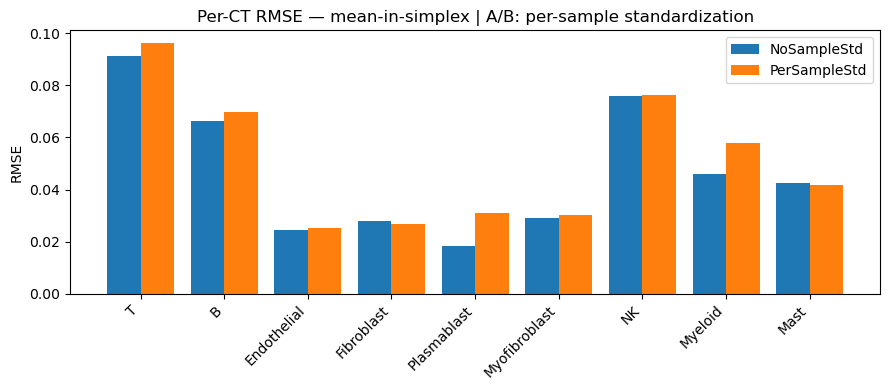


=== Per-Patient × Per-CT RMSE — NoSampleStd ===
         T       B  Endothelial  Fibroblast  Plasmablast  Myofibroblast      NK  Myeloid    Mast
P1  0.0648  0.0292       0.0031      0.0466       0.0079         0.0146  0.0098   0.0154  0.0251
P2  0.0755  0.0249       0.0040      0.0146       0.0290         0.0321  0.0445   0.0402  0.0919
P3  0.0435  0.0437       0.0185      0.0214       0.0234         0.0351  0.0855   0.0296  0.0215
P4  0.1694  0.0520       0.0039      0.0336       0.0084         0.0092  0.1415   0.0799  0.0223
P7  0.0684  0.1007       0.0397      0.0194       0.0154         0.0352  0.0510   0.0424  0.0198

=== Per-Patient × Per-CT RMSE — PerSampleStd ===
         T       B  Endothelial  Fibroblast  Plasmablast  Myofibroblast      NK  Myeloid    Mast
P1  0.0613  0.0294       0.0019      0.0474       0.0104         0.0151  0.0095   0.0273  0.0236
P2  0.0876  0.0111       0.0087      0.0119       0.0239         0.0359  0.0449   0.0815  0.0899
P3  0.0567  0.0488       0.0

In [61]:
# Jupyter cell: LOPO (outer) + inner K-fold (~20% val), fixed Strategy=B (mean in simplex)
# A/B 比較：不做 per-sample 標準化 vs 做 per-sample 標準化（每個樣本用自己的 mean/std）
AD_PATH    = r"../train_data/train_adata.h5ad"
BULK_PATH  = r"../train_data/train_bulk.csv"
TRUE_PATH  = r"../train_data/train_bulk_trueprops.csv"

CELLTYPE_COL   = "highLevelType"
TARGET_ORDER   = ["T","B","Endothelial","Fibroblast","Plasmablast","Myofibroblast","NK","Myeloid","Mast"]
MARKER_TOPK_CT = 100         # ComBat-first marker：每個 CT 取 Top-K，union 為特徵
INNER_N_FOLDS  = 5           # 內圈 K（其餘病人太少會縮小）
SEED           = 42

import re, numpy as np, pandas as pd, matplotlib.pyplot as plt
from typing import List, Dict, Tuple
from sklearn.model_selection import KFold
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge
import warnings
warnings.filterwarnings("ignore")

# -------- utils --------
def need_scanpy():
    import scanpy as sc
    return sc

def preprocess_sc(ad):
    sc = need_scanpy()
    sc.pp.filter_cells(ad, min_genes=200)
    sc.pp.filter_genes(ad, min_cells=3)
    sc.pp.normalize_total(ad, target_sum=1e4)
    sc.pp.log1p(ad)

def pseudobulk_by_sample_ct(ad, ct_col: str, sample_col: str) -> pd.DataFrame:
    obs = ad.obs[[ct_col, sample_col]].astype(str)
    groups = obs.groupby([sample_col, ct_col]).indices
    cols, names = [], []
    for (s, ct), idx in groups.items():
        Xi = ad.X[idx]
        cols.append(np.asarray(Xi.mean(axis=0)).ravel()); names.append(f"{s}|{ct}")
    return pd.DataFrame(np.column_stack(cols), index=ad.var_names.astype(str), columns=names)

def combat_on_pb(pb: pd.DataFrame) -> pd.DataFrame:
    sc = need_scanpy()
    ad = sc.AnnData(pb.T.copy())
    ad.obs["batch"] = pd.Categorical([c.split("|",1)[0] for c in pb.columns])  # batch=Sample
    sc.pp.combat(ad, key="batch")
    return pd.DataFrame(ad.X.T, index=pb.index, columns=pb.columns)

def stratified_marker_union(pb: pd.DataFrame, topk_per_ct: int, ct_order: List[str]) -> List[str]:
    cts = sorted({c.split("|",1)[1] for c in pb.columns})
    order = [ct for ct in ct_order if ct in cts] + [ct for ct in cts if ct not in ct_order]
    mean_all = pb.mean(axis=1) + 1e-9
    sel = set()
    for ct in order:
        cols = [c for c in pb.columns if c.split("|",1)[1]==ct]
        if not cols: continue
        m_ct = pb[cols].mean(axis=1)
        rest = (mean_all * len(cts) - m_ct) / max(1e-12, (len(cts)-1))
        score = np.log2((m_ct+1e-9)/(rest+1e-9)).sort_values(ascending=False)
        sel.update(score.index[:topk_per_ct])
    return list(sel)

def cpm_log1p_bulk(df: pd.DataFrame) -> pd.DataFrame:
    lib = df.sum(axis=0); lib[lib==0]=1.0
    return np.log1p(df.div(lib, axis=1) * 1e4)

def clean_genes(idx: pd.Index) -> pd.Index:
    def f(s: str):
        s = str(s).strip()
        s = re.sub(r"\.\d+$", "", s)
        return s.upper()
    return pd.Index([f(x) for x in idx], name=idx.name)

def parse_sample_from_bulk_col(col: str) -> str:
    m = re.match(r"^(s\d+)", str(col).lower())
    return m.group(1) if m else str(col)

def simplex_proj(v: np.ndarray) -> np.ndarray:
    # 投影到 simplex（sum=1, >=0）
    u = np.sort(v)[::-1]
    cssv = np.cumsum(u)
    rho = np.nonzero(u * np.arange(1, len(u)+1) > (cssv - 1))[0][-1]
    theta = (cssv[rho] - 1) / (rho + 1.0)
    return np.maximum(v - theta, 0.0)

# ILR transforms
def helmert_basis(K: int) -> np.ndarray:
    H = np.zeros((K, K-1))
    for i in range(1, K):
        a = np.ones(i)/i
        H[:i, i-1] = a
        H[i,   i-1] = -1.0
    for j in range(K-1):
        col = H[:, j]; H[:, j] = col / (np.linalg.norm(col) + 1e-12)
    return H

def ilr(p: np.ndarray, H: np.ndarray) -> np.ndarray:
    eps = 1e-12
    p = np.maximum(p, eps)
    p = p / p.sum(axis=-1, keepdims=True)
    return np.log(p) @ H

def ilr_inv(z: np.ndarray, H: np.ndarray) -> np.ndarray:
    logp = z @ H.T
    x = np.exp(logp)
    return x / x.sum(axis=-1, keepdims=True)

# per-sample 標準化：對 X（n_samples × n_genes）按列向量逐列做 z-score
def samplewise_zscore(X_df: pd.DataFrame) -> pd.DataFrame:
    X = X_df.values
    mu = X.mean(axis=1, keepdims=True)
    sd = X.std(axis=1, keepdims=True)
    sd[sd == 0] = 1.0
    Z = (X - mu) / sd
    return pd.DataFrame(Z, index=X_df.index, columns=X_df.columns)

# -------- load --------
sc = need_scanpy()
adata = sc.read_h5ad(AD_PATH)
bulk_raw = pd.read_csv(BULK_PATH, index_col=0).apply(pd.to_numeric, errors="coerce").fillna(0.0)
truth    = pd.read_csv(TRUE_PATH, index_col=0)
for ct in TARGET_ORDER:
    if ct not in truth.index:
        truth.loc[ct] = 0.0

if CELLTYPE_COL not in adata.obs:
    if "cell_type" in adata.obs: CELLTYPE_COL = "cell_type"
    else: raise KeyError("missing cell-type column in adata.obs")
if "Sample" not in adata.obs or "Patient" not in adata.obs:
    raise KeyError("adata.obs needs 'Sample' and 'Patient'")

# sc preprocess
preprocess_sc(adata)

# bulk transform（保守清洗）
bulk_raw.index = clean_genes(bulk_raw.index)
B_all = cpm_log1p_bulk(bulk_raw)

# sample -> patient 映射
samples_bulk = B_all.columns.tolist()
sample_to_patient = adata.obs[["Sample","Patient"]].drop_duplicates().set_index("Sample")["Patient"].astype(str)
col_to_sample  = {c: parse_sample_from_bulk_col(c) for c in samples_bulk}
col_to_patient = {c: sample_to_patient.get(col_to_sample[c], "UNK") for c in samples_bulk}

# 僅保留能對應到病人的樣本
keep_cols = [c for c in samples_bulk if col_to_patient[c]!="UNK"]
B_all = B_all[keep_cols]
T_all = truth.loc[TARGET_ORDER, keep_cols].T  # (n_samples × K)
patients_all = sorted({col_to_patient[c] for c in B_all.columns})

# ILR basis
Kc = len(TARGET_ORDER)
H = helmert_basis(Kc)

# -------- 主要函式：在「是否做 per-sample 標準化」下，跑 LOPO+inner K 並用 mean-in-simplex 聚合 --------
def run_lopo_with_option(use_sample_std: bool) -> Tuple[float, pd.Series, pd.DataFrame]:
    preds_by_sample: Dict[str, List[np.ndarray]] = {}   # 收集每個 test sample 的多次 y_pred（simplex）
    truth_by_sample: Dict[str, np.ndarray] = {}
    patient_of_col: Dict[str, str] = {}

    for p_test in patients_all:
        test_cols = [c for c in B_all.columns if col_to_patient[c]==p_test]
        if len(test_cols) == 0:
            continue

        others = [p for p in patients_all if p != p_test]
        if len(others) == 0:
            continue

        K_inner = min(INNER_N_FOLDS, max(1, len(others)))
        kf = KFold(n_splits=K_inner, shuffle=True, random_state=SEED)
        others_arr = np.array(others)

        # 針對這位 test 病人，收集各 inner-fold 的 y_pred
        bag_y: Dict[str, List[np.ndarray]] = {c: [] for c in test_cols}

        for in_id, (tr_mask, va_mask) in enumerate(kf.split(others_arr), 1):
            in_tr_pats = set(others_arr[tr_mask].tolist())

            # 用 inner-train 病人決定 markers（避免洩漏）
            ad_tr = adata[adata.obs["Patient"].astype(str).isin(in_tr_pats)].copy()
            if ad_tr.n_obs < 10:
                continue

            pb_all = pseudobulk_by_sample_ct(ad_tr, CELLTYPE_COL, "Sample")
            pb_all = combat_on_pb(pb_all)  # ComBat-first for marker selection
            markers = stratified_marker_union(pb_all, topk_per_ct=MARKER_TOPK_CT, ct_order=TARGET_ORDER)
            markers = clean_genes(pd.Index(markers))

            genes_used = B_all.index.intersection(markers)
            if len(genes_used) < 20:
                continue

            # inner-train bulk/labels（samples × genes）
            tr_cols_inner = [c for c in B_all.columns if col_to_patient[c] in in_tr_pats]
            X_in_tr = B_all.loc[genes_used, tr_cols_inner].T
            y_in_tr = T_all.loc[tr_cols_inner].values
            z_in_tr = ilr(y_in_tr, H)

            # per-sample 標準化（A/B 變數）：每一列（樣本）用自己的 mean/std 做 z-score
            if use_sample_std:
                X_in_tr_std = samplewise_zscore(X_in_tr)
            else:
                X_in_tr_std = X_in_tr

            # Ridge(α=1e-2) 多輸出（回歸 ILR）
            model = MultiOutputRegressor(Ridge(alpha=1e-2, random_state=SEED))
            model.fit(X_in_tr_std, z_in_tr)

            # 對本 outer test 病人的樣本做預測
            X_te = B_all.loc[genes_used, test_cols].T
            if use_sample_std:
                X_te = samplewise_zscore(X_te)

            z_pred = model.predict(X_te)          # (n_test_for_patient × K-1)
            y_pred = ilr_inv(z_pred, H)           # 回到比例
            y_pred = np.vstack([simplex_proj(row) for row in y_pred])  # safety

            for i, col in enumerate(test_cols):
                bag_y[col].append(y_pred[i])

        # 對此 test 病人的每個 sample 做聚合（固定策略：mean in simplex）
        for col in test_cols:
            patient_of_col[col]  = p_test
            truth_by_sample[col] = T_all.loc[col].values
            if len(bag_y[col]) > 0:
                y_mean = np.mean(np.vstack(bag_y[col]), axis=0)
                y_mean = simplex_proj(y_mean)
            else:
                y_mean = np.ones(Kc)/Kc
            preds_by_sample.setdefault(col, []).append(y_mean)

    # 堆疊結果
    cols_eval = sorted(truth_by_sample.keys())
    Y_true = np.vstack([truth_by_sample[c] for c in cols_eval])

    # 理論上每個 sample 只有一組均值，但保留彈性
    Y_pred = []
    for c in cols_eval:
        arr = np.vstack(preds_by_sample[c])
        y = simplex_proj(arr.mean(axis=0))
        Y_pred.append(y)
    Y_pred = np.vstack(Y_pred)

    # RMSE
    rmse_ct = np.sqrt(((Y_pred - Y_true)**2).mean(axis=0))
    avg_rmse = float(rmse_ct.mean())
    per_ct = pd.Series(rmse_ct, index=TARGET_ORDER)

    # per-patient × per-CT RMSE
    df_eval = pd.DataFrame({"patient":[col_to_patient[c] for c in cols_eval],
                            "sample": cols_eval})
    df_eval["y_true"] = list(Y_true)
    df_eval["y_pred"] = list(Y_pred)

    rows = []
    for p, sub in df_eval.groupby("patient"):
        Yt = np.vstack(sub["y_true"].values)
        Yp = np.vstack(sub["y_pred"].values)
        rmse_ct_p = np.sqrt(((Yp - Yt)**2).mean(axis=0))
        rows.append(pd.Series(rmse_ct_p, index=TARGET_ORDER, name=p))
    pp = pd.DataFrame(rows).sort_index()

    return avg_rmse, per_ct, pp

# -------- 跑 A/B：不標準化 vs per-sample 標準化 --------
results = []
for use_std in [False, True]:
    tag = "NoSampleStd" if not use_std else "PerSampleStd"
    avg_rmse, perct, pp = run_lopo_with_option(use_std)
    results.append((tag, avg_rmse, perct, pp))

# -------- 輸出 --------
print("\n=== LOPO + inner K-fold — Strategy fixed: mean-in-simplex ===")
for tag, avg_rmse, perct, _ in results:
    print(f"{tag:>13} | Avg RMSE = {avg_rmse:.4f}")
    print(perct.round(4).to_string())
    print("-"*60)

# 視覺化（per-CT 對比）
plt.figure(figsize=(9,4))
x = np.arange(len(TARGET_ORDER))
w = 0.4
plt.bar(x - w/2, results[0][2].values, w, label=results[0][0])
plt.bar(x + w/2, results[1][2].values, w, label=results[1][0])
plt.xticks(x, TARGET_ORDER, rotation=45, ha="right")
plt.ylabel("RMSE")
plt.title("Per-CT RMSE — mean-in-simplex | A/B: per-sample standardization")
plt.legend()
plt.tight_layout(); plt.show()

# 顯示 per-patient × per-CT（兩設定）
print("\n=== Per-Patient × Per-CT RMSE — NoSampleStd ===")
print(results[0][3].round(4).to_string())
print("\n=== Per-Patient × Per-CT RMSE — PerSampleStd ===")
print(results[1][3].round(4).to_string())


Found 3 genes with zero variance.
Found 2 genes with zero variance.
Found 2 genes with zero variance.
Found 4 genes with zero variance.
Found 2 genes with zero variance.
Found 4 genes with zero variance.
Found 3 genes with zero variance.
Found 2 genes with zero variance.
Found 3 genes with zero variance.
Found 2 genes with zero variance.
Found 2 genes with zero variance.
Found 4 genes with zero variance.
Found 2 genes with zero variance.
Found 4 genes with zero variance.
Found 3 genes with zero variance.
Found 2 genes with zero variance.

=== LOPO + inner K-fold — Fixed 'mean-in-simplex' (Ridge α=1e-2) ===
 Bulk-NoComBat | Avg RMSE = 0.0468
T                0.0912
B                0.0663
Endothelial      0.0242
Fibroblast       0.0281
Plasmablast      0.0182
Myofibroblast    0.0290
NK               0.0759
Myeloid          0.0460
Mast             0.0425
------------------------------------------------------------
   Bulk+ComBat | Avg RMSE = 0.0582
T                0.1091
B              

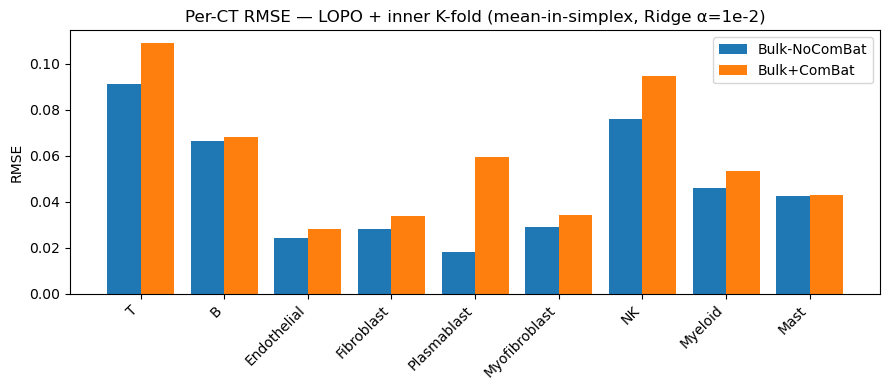


=== Per-Patient × Per-CT RMSE — Bulk-NoComBat ===
         T       B  Endothelial  Fibroblast  Plasmablast  Myofibroblast      NK  Myeloid    Mast
P1  0.0648  0.0292       0.0031      0.0466       0.0079         0.0146  0.0098   0.0154  0.0251
P2  0.0755  0.0249       0.0040      0.0146       0.0290         0.0321  0.0445   0.0402  0.0919
P3  0.0435  0.0437       0.0185      0.0214       0.0234         0.0351  0.0855   0.0296  0.0215
P4  0.1694  0.0520       0.0039      0.0336       0.0084         0.0092  0.1415   0.0799  0.0223
P7  0.0684  0.1007       0.0397      0.0194       0.0154         0.0352  0.0510   0.0424  0.0198

=== Per-Patient × Per-CT RMSE — Bulk+ComBat ===
         T       B  Endothelial  Fibroblast  Plasmablast  Myofibroblast      NK  Myeloid    Mast
P1  0.1516  0.0241       0.0107      0.0605       0.0610         0.0150  0.0424   0.0041  0.0288
P2  0.0967  0.0113       0.0029      0.0380       0.0937         0.0453  0.0449   0.0407  0.0946
P3  0.0639  0.0720       0.

In [54]:
# Jupyter cell: LOPO (outer) + inner K-fold (~20% val), fixed "mean-in-simplex" test averaging
# A/B: whether to ComBat-correct the *bulk* matrix before training/prediction.
AD_PATH    = r"../train_data/train_adata.h5ad"
BULK_PATH  = r"../train_data/train_bulk.csv"
TRUE_PATH  = r"../train_data/train_bulk_trueprops.csv"

CELLTYPE_COL   = "highLevelType"
TARGET_ORDER   = ["T","B","Endothelial","Fibroblast","Plasmablast","Myofibroblast","NK","Myeloid","Mast"]
MARKER_TOPK_CT = 100         # per-CT markers (決定於 inner-train 的 pseudo-bulk + ComBat)
INNER_N_FOLDS  = 5
SEED           = 42

import re, numpy as np, pandas as pd, matplotlib.pyplot as plt
from typing import Dict, List
from sklearn.model_selection import KFold
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge
import warnings
warnings.filterwarnings("ignore")

# ---------------- utils ----------------
def need_scanpy():
    import scanpy as sc
    return sc

def preprocess_sc(ad):
    sc = need_scanpy()
    sc.pp.filter_cells(ad, min_genes=200)
    sc.pp.filter_genes(ad, min_cells=3)
    sc.pp.normalize_total(ad, target_sum=1e4)
    sc.pp.log1p(ad)

def pseudobulk_by_sample_ct(ad, ct_col: str, sample_col: str) -> pd.DataFrame:
    # genes × (sample|ct)
    obs = ad.obs[[ct_col, sample_col]].astype(str)
    groups = obs.groupby([sample_col, ct_col]).indices
    cols, names = [], []
    for (s, ct), idx in groups.items():
        Xi = ad.X[idx]
        cols.append(np.asarray(Xi.mean(axis=0)).ravel()); names.append(f"{s}|{ct}")
    return pd.DataFrame(np.column_stack(cols), index=ad.var_names.astype(str), columns=names)

def combat_on_pb(pb: pd.DataFrame) -> pd.DataFrame:
    sc = need_scanpy()
    ad = sc.AnnData(pb.T.copy())
    # batch = Sample（同一個 sample 的不同 CT 視為同一批）
    ad.obs["batch"] = pd.Categorical([c.split("|",1)[0] for c in pb.columns])
    sc.pp.combat(ad, key="batch")
    return pd.DataFrame(ad.X.T, index=pb.index, columns=pb.columns)

def combat_on_bulk(B: pd.DataFrame, batch: List[str]) -> pd.DataFrame:
    """對 bulk（genes×samples）做 ComBat；batch 需至少每組 ≥2 才有意義。"""
    sc = need_scanpy()
    ad = sc.AnnData(B.T.copy())
    ad.obs["batch"] = pd.Categorical(batch)
    # 若 batch 都是獨一無二，ComBat 不會改變數值；scanpy 仍允許運行
    sc.pp.combat(ad, key="batch")
    return pd.DataFrame(ad.X.T, index=B.index, columns=B.columns)

def stratified_marker_union(pb: pd.DataFrame, topk_per_ct: int, ct_order: List[str]) -> List[str]:
    # 每類相對其它類的 logFC 排名，取 TopK，最後做 union
    cts = sorted({c.split("|",1)[1] for c in pb.columns})
    order = [ct for ct in ct_order if ct in cts] + [ct for ct in cts if ct not in ct_order]
    mean_all = pb.mean(axis=1) + 1e-9
    sel = set()
    for ct in order:
        cols = [c for c in pb.columns if c.split("|",1)[1]==ct]
        if not cols: 
            continue
        m_ct = pb[cols].mean(axis=1)
        rest = (mean_all * len(cts) - m_ct) / max(1e-12, (len(cts)-1))
        score = np.log2((m_ct+1e-9)/(rest+1e-9)).sort_values(ascending=False)
        sel.update(score.index[:topk_per_ct])
    return list(sel)

def cpm_log1p_bulk(df: pd.DataFrame) -> pd.DataFrame:
    lib = df.sum(axis=0); lib[lib==0]=1.0
    return np.log1p(df.div(lib, axis=1) * 1e4)

def clean_genes(idx: pd.Index) -> pd.Index:
    def f(s: str):
        s = str(s).strip()
        s = re.sub(r"\.\d+$", "", s)
        return s.upper()
    return pd.Index([f(x) for x in idx], name=idx.name)

def parse_sample_from_bulk_col(col: str) -> str:
    # 's1_0' -> 's1'
    m = re.match(r"^(s\d+)", str(col).lower())
    return m.group(1) if m else str(col)

def simplex_proj(v: np.ndarray) -> np.ndarray:
    # 精確投影到 simplex（sum=1, >=0）
    u = np.sort(v)[::-1]
    cssv = np.cumsum(u)
    rho = np.nonzero(u * np.arange(1, len(u)+1) > (cssv - 1))[0][-1]
    theta = (cssv[rho] - 1) / (rho + 1.0)
    return np.maximum(v - theta, 0.0)

# ILR transforms
def helmert_basis(K: int) -> np.ndarray:
    H = np.zeros((K, K-1))
    for i in range(1, K):
        a = np.ones(i)/i
        H[:i, i-1] = a
        H[i,   i-1] = -1.0
    for j in range(K-1):
        col = H[:, j]; H[:, j] = col / (np.linalg.norm(col) + 1e-12)
    return H

def ilr(p: np.ndarray, H: np.ndarray) -> np.ndarray:
    eps = 1e-12
    p = np.maximum(p, eps)
    p = p / p.sum(axis=-1, keepdims=True)
    return np.log(p) @ H

def ilr_inv(z: np.ndarray, H: np.ndarray) -> np.ndarray:
    logp = z @ H.T
    x = np.exp(logp)
    return x / x.sum(axis=-1, keepdims=True)

# ---------------- load ----------------
sc = need_scanpy()
adata = sc.read_h5ad(AD_PATH)
bulk_raw = pd.read_csv(BULK_PATH, index_col=0).apply(pd.to_numeric, errors="coerce").fillna(0.0)
truth    = pd.read_csv(TRUE_PATH, index_col=0)
for ct in TARGET_ORDER:
    if ct not in truth.index:
        truth.loc[ct] = 0.0

if CELLTYPE_COL not in adata.obs:
    if "cell_type" in adata.obs: CELLTYPE_COL = "cell_type"
    else: raise KeyError("missing cell-type column in adata.obs")
if "Sample" not in adata.obs or "Patient" not in adata.obs:
    raise KeyError("adata.obs needs 'Sample' and 'Patient'")

preprocess_sc(adata)

# bulk base transform
bulk_raw.index = clean_genes(bulk_raw.index)
B_base = cpm_log1p_bulk(bulk_raw)

# 建立 sample → patient 對應（由 adata 提供）
samples_bulk = B_base.columns.tolist()
sample_to_patient = adata.obs[["Sample","Patient"]].drop_duplicates().set_index("Sample")["Patient"].astype(str)
col_to_sample  = {c: parse_sample_from_bulk_col(c) for c in samples_bulk}
col_to_patient = {c: sample_to_patient.get(col_to_sample[c], "UNK") for c in samples_bulk}

# 只保留能對應到病人的樣本
keep_cols = [c for c in samples_bulk if col_to_patient[c]!="UNK"]
B_base = B_base[keep_cols]
T_all  = truth.loc[TARGET_ORDER, keep_cols].T
patients_all = sorted({col_to_patient[c] for c in B_base.columns})

if len(patients_all) < 2:
    raise ValueError("Need ≥2 patients for LOPO.")

# 準備 bulk 的 batch（用「患者ID」作 batch，比較合理；若每病人只有1樣本，ComBat影響很小）
bulk_batch = [col_to_patient[c] for c in B_base.columns]

# ILR basis
Kc = len(TARGET_ORDER)
H  = helmert_basis(Kc)

def run_experiment(bulk_do_combat: bool) -> Dict[str, any]:
    """
    固定 test time averaging = mean in simplex
    bulk_do_combat=False/True：對 bulk（全體）是否先做一次 ComBat（以 patient 為 batch）。
    """
    # 依設定準備 bulk 矩陣
    if bulk_do_combat:
        B = combat_on_bulk(B_base, bulk_batch)
        tag = "Bulk+ComBat"
    else:
        B = B_base.copy()
        tag = "Bulk-NoComBat"

    preds_by_sample: Dict[str, List[np.ndarray]] = {}
    truth_by_sample: Dict[str, np.ndarray] = {}
    patient_of_col:  Dict[str, str] = {}

    for p_test in patients_all:
        test_cols = [c for c in B.columns if col_to_patient[c]==p_test]
        if not test_cols: 
            continue
        others = [p for p in patients_all if p != p_test]
        if not others:
            continue

        # inner ~20% val
        K_inner = min(INNER_N_FOLDS, max(1, len(others)))
        kf = KFold(n_splits=K_inner, shuffle=True, random_state=SEED)
        others_arr = np.array(others)

        # 針對此 test 病人，蒐集所有 inner-fold 的 y_pred（在 simplex）
        bag_y: Dict[str, List[np.ndarray]] = {c: [] for c in test_cols}

        for in_id, (tr_mask, va_mask) in enumerate(kf.split(others_arr), 1):
            in_tr_pats = set(others_arr[tr_mask].tolist())

            # inner-train 的單細胞 → pseudo-bulk → ComBat → 取 markers（避免洩漏）
            ad_tr = adata[adata.obs["Patient"].astype(str).isin(in_tr_pats)].copy()
            if ad_tr.n_obs < 10:
                continue
            pb_all = pseudobulk_by_sample_ct(ad_tr, CELLTYPE_COL, "Sample")
            pb_all = combat_on_pb(pb_all)  # ComBat-first for marker selection
            markers = stratified_marker_union(pb_all, topk_per_ct=MARKER_TOPK_CT, ct_order=TARGET_ORDER)
            markers = clean_genes(pd.Index(markers))

            genes_used = B.index.intersection(markers)
            if len(genes_used) < 20:
                continue

            # inner-train / test 的 X, y
            tr_cols_inner = [c for c in B.columns if col_to_patient[c] in in_tr_pats]
            X_in_tr = B.loc[genes_used, tr_cols_inner].T
            y_in_tr = T_all.loc[tr_cols_inner].values
            z_in_tr = ilr(y_in_tr, H)

            # Ridge multi-output
            model = MultiOutputRegressor(Ridge(alpha=1e-2, random_state=SEED))
            model.fit(X_in_tr, z_in_tr)

            # 預測 outer-test 病人的樣本，並**直接在 simplex 收集**
            X_te = B.loc[genes_used, test_cols].T
            z_pred = model.predict(X_te)
            y_pred = ilr_inv(z_pred, H)
            y_pred = np.vstack([simplex_proj(row) for row in y_pred])

            for i, col in enumerate(test_cols):
                bag_y[col].append(y_pred[i])

        # 對此 test 病人的每個 sample 做平均（simplex），寫入全域容器
        for col in test_cols:
            if col not in truth_by_sample:
                truth_by_sample[col] = T_all.loc[col].values
                patient_of_col[col]  = p_test
            if len(bag_y[col]) > 0:
                y_mean = np.mean(np.vstack(bag_y[col]), axis=0)
                y_mean = simplex_proj(y_mean)
            else:
                y_mean = np.ones(Kc)/Kc
            preds_by_sample.setdefault(col, []).append(y_mean)

    # 彙整
    cols_eval = sorted(preds_by_sample.keys())
    Y_true = np.vstack([truth_by_sample[c] for c in cols_eval])
    Y_pred = np.vstack([np.vstack(preds_by_sample[c]).mean(axis=0) for c in cols_eval])
    Y_pred = np.vstack([simplex_proj(r) for r in Y_pred])

    rmse_ct = np.sqrt(((Y_pred - Y_true)**2).mean(axis=0))
    avg_rmse = float(rmse_ct.mean())
    perct = pd.Series(rmse_ct, index=TARGET_ORDER)
    patients_eval = [patient_of_col[c] for c in cols_eval]

    # per-patient × per-CT RMSE
    df_eval = pd.DataFrame({"patient": patients_eval, "sample": cols_eval})
    df_eval["y_true"] = list(Y_true)
    df_eval["y_pred"] = list(Y_pred)

    rows = []
    for p, sub in df_eval.groupby("patient"):
        Yt = np.vstack(sub["y_true"].values)
        Yp = np.vstack(sub["y_pred"].values)
        rows.append(pd.Series(np.sqrt(((Yp - Yt)**2).mean(axis=0)), index=TARGET_ORDER, name=p))
    pp = pd.DataFrame(rows).sort_index()

    return {
        "tag": tag,
        "avg_rmse": avg_rmse,
        "perct": perct,
        "per_patient_ct": pp
    }

# ---------------- run A/B ----------------
resA = run_experiment(bulk_do_combat=False)  # Bulk-NoComBat
resB = run_experiment(bulk_do_combat=True)   # Bulk+ComBat

print("\n=== LOPO + inner K-fold — Fixed 'mean-in-simplex' (Ridge α=1e-2) ===")
for r in (resA, resB):
    print(f"{r['tag']:>14} | Avg RMSE = {r['avg_rmse']:.4f}")
    print(r["perct"].round(4).to_string())
    print("-"*60)

# 圖：兩種 bulk 設定的 per-CT 對比
x = np.arange(len(TARGET_ORDER))
plt.figure(figsize=(9,4))
w = 0.4
plt.bar(x - w/2, resA["perct"].values, w, label=resA["tag"])
plt.bar(x + w/2, resB["perct"].values, w, label=resB["tag"])
plt.xticks(x, TARGET_ORDER, rotation=45, ha="right")
plt.ylabel("RMSE")
plt.title("Per-CT RMSE — LOPO + inner K-fold (mean-in-simplex, Ridge α=1e-2)")
plt.legend()
plt.tight_layout(); plt.show()

print("\n=== Per-Patient × Per-CT RMSE — Bulk-NoComBat ===")
print(resA["per_patient_ct"].round(4).to_string())
print("\n=== Per-Patient × Per-CT RMSE — Bulk+ComBat ===")
print(resB["per_patient_ct"].round(4).to_string())


Found 3 genes with zero variance.
Found 2 genes with zero variance.
Found 2 genes with zero variance.
Found 4 genes with zero variance.
Found 2 genes with zero variance.
Found 4 genes with zero variance.
Found 3 genes with zero variance.
Found 2 genes with zero variance.

=== LOPO + inner K-fold — Ridge vs LGBM vs Combo; Strategy A & B ===
 B-Simplexmean Ridge | Avg RMSE = 0.0468
T                0.0912
B                0.0663
Endothelial      0.0242
Fibroblast       0.0281
Plasmablast      0.0182
Myofibroblast    0.0290
NK               0.0759
Myeloid          0.0460
Mast             0.0425
------------------------------------------------------------
     A-ILRmean Ridge | Avg RMSE = 0.0477
T                0.0974
B                0.0655
Endothelial      0.0244
Fibroblast       0.0272
Plasmablast      0.0170
Myofibroblast    0.0293
NK               0.0759
Myeloid          0.0496
Mast             0.0431
------------------------------------------------------------
 B-Simplexmean Combo |

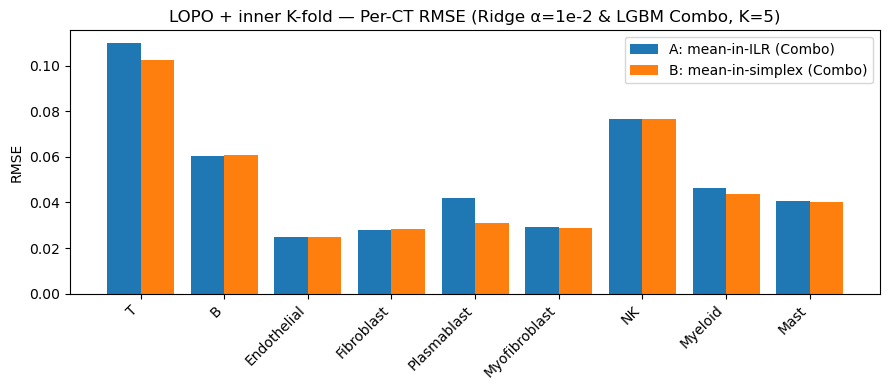

In [49]:
# Jupyter cell: LOPO (outer) + inner K-fold (~20% val) with Ridge(alpha=1e-2) & LightGBM
# Compare two test-time averaging strategies (for Ridge, LGBM, and Combo):
#   (A) mean in ILR → ilr_inv
#   (B) ilr_inv per fold → mean in simplex

AD_PATH    = r"../train_data/train_adata.h5ad"
BULK_PATH  = r"../train_data/train_bulk.csv"
TRUE_PATH  = r"../train_data/train_bulk_trueprops.csv"

CELLTYPE_COL   = "highLevelType"
TARGET_ORDER   = ["T","B","Endothelial","Fibroblast","Plasmablast","Myofibroblast","NK","Myeloid","Mast"]
MARKER_TOPK_CT = 100         # 每 CT Top-K markers（ComBat-first，僅用 inner-train 病人）
INNER_N_FOLDS  = 5           # 內圈 K（其餘病人太少時自動縮小）
SEED           = 42

import re, numpy as np, pandas as pd, matplotlib.pyplot as plt, warnings
from typing import List, Dict, Tuple
from sklearn.model_selection import KFold
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge
warnings.filterwarnings("ignore")

# ---- optional LightGBM
try:
    import lightgbm as lgb
    HAVE_LGBM = True
except Exception:
    HAVE_LGBM = False
    print("[Warn] lightgbm not installed; will run Ridge only.")

# -------- utils --------
def need_scanpy():
    import scanpy as sc
    return sc

def preprocess_sc(ad):
    sc = need_scanpy()
    sc.pp.filter_cells(ad, min_genes=200)
    sc.pp.filter_genes(ad, min_cells=3)
    sc.pp.normalize_total(ad, target_sum=1e4)
    sc.pp.log1p(ad)

def pseudobulk_by_sample_ct(ad, ct_col: str, sample_col: str) -> pd.DataFrame:
    obs = ad.obs[[ct_col, sample_col]].astype(str)
    groups = obs.groupby([sample_col, ct_col]).indices
    cols, names = [], []
    for (s, ct), idx in groups.items():
        Xi = ad.X[idx]
        cols.append(np.asarray(Xi.mean(axis=0)).ravel()); names.append(f"{s}|{ct}")
    return pd.DataFrame(np.column_stack(cols), index=ad.var_names.astype(str), columns=names)

def combat_on_pb(pb: pd.DataFrame) -> pd.DataFrame:
    sc = need_scanpy()
    ad = sc.AnnData(pb.T.copy())
    ad.obs["batch"] = pd.Categorical([c.split("|",1)[0] for c in pb.columns])  # batch=Sample
    sc.pp.combat(ad, key="batch")
    return pd.DataFrame(ad.X.T, index=pb.index, columns=pb.columns)

def stratified_marker_union(pb: pd.DataFrame, topk_per_ct: int, ct_order: List[str]) -> List[str]:
    cts = sorted({c.split("|",1)[1] for c in pb.columns})
    order = [ct for ct in ct_order if ct in cts] + [ct for ct in cts if ct not in ct_order]
    mean_all = pb.mean(axis=1) + 1e-9
    sel = set()
    for ct in order:
        cols = [c for c in pb.columns if c.split("|",1)[1]==ct]
        if not cols: continue
        m_ct = pb[cols].mean(axis=1)
        rest = (mean_all * len(cts) - m_ct) / max(1e-12, (len(cts)-1))
        score = np.log2((m_ct+1e-9)/(rest+1e-9)).sort_values(ascending=False)
        sel.update(score.index[:topk_per_ct])
    return list(sel)

def cpm_log1p_bulk(df: pd.DataFrame) -> pd.DataFrame:
    lib = df.sum(axis=0); lib[lib==0]=1.0
    return np.log1p(df.div(lib, axis=1) * 1e4)

def clean_genes(idx: pd.Index) -> pd.Index:
    def f(s: str):
        s = str(s).strip()
        s = re.sub(r"\.\d+$", "", s)
        return s.upper()
    return pd.Index([f(x) for x in idx], name=idx.name)

def parse_sample_from_bulk_col(col: str) -> str:
    # 's1_0' -> 's1'
    m = re.match(r"^(s\d+)", str(col).lower())
    return m.group(1) if m else str(col)

def simplex_proj(v: np.ndarray) -> np.ndarray:
    # 精確投影到 simplex（sum=1, >=0）
    u = np.sort(v)[::-1]
    cssv = np.cumsum(u)
    rho = np.nonzero(u * np.arange(1, len(u)+1) > (cssv - 1))[0][-1]
    theta = (cssv[rho] - 1) / (rho + 1.0)
    return np.maximum(v - theta, 0.0)

# ILR transforms
def helmert_basis(K: int) -> np.ndarray:
    H = np.zeros((K, K-1))
    for i in range(1, K):
        a = np.ones(i)/i
        H[:i, i-1] = a
        H[i,   i-1] = -1.0
    for j in range(K-1):
        col = H[:, j]; H[:, j] = col / (np.linalg.norm(col) + 1e-12)
    return H

def ilr(p: np.ndarray, H: np.ndarray) -> np.ndarray:
    eps = 1e-12
    p = np.maximum(p, eps)
    p = p / p.sum(axis=-1, keepdims=True)
    return np.log(p) @ H

def ilr_inv(z: np.ndarray, H: np.ndarray) -> np.ndarray:
    logp = z @ H.T
    x = np.exp(logp)
    return x / x.sum(axis=-1, keepdims=True)

# -------- load --------
sc = need_scanpy()
adata = sc.read_h5ad(AD_PATH)
bulk_raw = pd.read_csv(BULK_PATH, index_col=0).apply(pd.to_numeric, errors="coerce").fillna(0.0)
truth    = pd.read_csv(TRUE_PATH, index_col=0)
for ct in TARGET_ORDER:
    if ct not in truth.index:
        truth.loc[ct] = 0.0

if CELLTYPE_COL not in adata.obs:
    if "cell_type" in adata.obs: CELLTYPE_COL = "cell_type"
    else: raise KeyError("missing cell-type column in adata.obs")
if "Sample" not in adata.obs or "Patient" not in adata.obs:
    raise KeyError("adata.obs needs 'Sample' and 'Patient'")

# sc preprocess
preprocess_sc(adata)

# bulk transform
bulk_raw.index = clean_genes(bulk_raw.index)
B_all = cpm_log1p_bulk(bulk_raw)

# 映射 sample -> patient
samples_bulk = B_all.columns.tolist()
sample_to_patient = adata.obs[["Sample","Patient"]].drop_duplicates().set_index("Sample")["Patient"].astype(str)
col_to_sample  = {c: parse_sample_from_bulk_col(c) for c in samples_bulk}
col_to_patient = {c: sample_to_patient.get(col_to_sample[c], "UNK") for c in samples_bulk}

# 僅保留能對應到病人的樣本
keep_cols = [c for c in samples_bulk if col_to_patient[c]!="UNK"]
B_all = B_all[keep_cols]
T_all = truth.loc[TARGET_ORDER, keep_cols].T  # (n_samples × K)
patients_all = sorted({col_to_patient[c] for c in B_all.columns})

# ILR basis
Kc = len(TARGET_ORDER)
H = helmert_basis(Kc)

# -------- LOPO (outer) + inner K-fold --------
# A: mean-in-ILR（Ridge/LGBM/Combo），B: mean-in-simplex（Ridge/LGBM/Combo）
predsA_ridge: Dict[str, List[np.ndarray]] = {}
predsA_lgbm:  Dict[str, List[np.ndarray]] = {}
predsB_ridge: Dict[str, List[np.ndarray]] = {}
predsB_lgbm:  Dict[str, List[np.ndarray]] = {}
truth_by_sample: Dict[str, np.ndarray]    = {}
patient_of_col:  Dict[str, str]           = {}

for p_test in patients_all:
    test_cols = [c for c in B_all.columns if col_to_patient[c]==p_test]
    if len(test_cols) == 0:
        continue

    others = [p for p in patients_all if p != p_test]
    if len(others) == 0:
        continue

    # inner folds ≈ 20% val → K=5（或縮小）
    K_inner = min(INNER_N_FOLDS, max(1, len(others)))
    kf = KFold(n_splits=K_inner, shuffle=True, random_state=SEED)
    others_arr = np.array(others)

    # 為本 outer test 病人準備袋子
    bagA_ridge = {c: [] for c in test_cols}
    bagB_ridge = {c: [] for c in test_cols}
    bagA_lgbm  = {c: [] for c in test_cols} if HAVE_LGBM else None
    bagB_lgbm  = {c: [] for c in test_cols} if HAVE_LGBM else None

    for in_id, (tr_mask, va_mask) in enumerate(kf.split(others_arr), 1):
        in_tr_pats = set(others_arr[tr_mask].tolist())

        # 1) inner-train 決定 markers（避免洩漏）
        ad_tr = adata[adata.obs["Patient"].astype(str).isin(in_tr_pats)].copy()
        if ad_tr.n_obs < 10:
            continue

        pb_all = pseudobulk_by_sample_ct(ad_tr, CELLTYPE_COL, "Sample")
        pb_all = combat_on_pb(pb_all)  # ComBat-first for marker selection
        markers = stratified_marker_union(pb_all, topk_per_ct=MARKER_TOPK_CT, ct_order=TARGET_ORDER)
        markers = clean_genes(pd.Index(markers))

        genes_used = B_all.index.intersection(markers)
        if len(genes_used) < 20:
            continue

        # 2) inner-train bulk/labels
        tr_cols_inner = [c for c in B_all.columns if col_to_patient[c] in in_tr_pats]
        X_in_tr = B_all.loc[genes_used, tr_cols_inner].T
        y_in_tr = T_all.loc[tr_cols_inner].values
        z_in_tr = ilr(y_in_tr, H)

        # 3a) Ridge model
        ridge = MultiOutputRegressor(Ridge(alpha=1e-2, random_state=SEED))
        ridge.fit(X_in_tr, z_in_tr)

        # 3b) LGBM model（可用才訓練）
        if HAVE_LGBM:
            lgbm = MultiOutputRegressor(
                lgb.LGBMRegressor(
                    n_estimators=800, learning_rate=0.02,
                    max_depth=4, num_leaves=15,
                    subsample=0.8, colsample_bytree=0.6,
                    reg_alpha=1.0, reg_lambda=2.0,
                    min_child_samples=10, random_state=SEED, verbose=-1
                )
            )
            lgbm.fit(X_in_tr, z_in_tr)

        # 4) 對 outer test 病人的樣本做預測
        X_te = B_all.loc[genes_used, test_cols].T

        # Ridge
        z_pred_r = ridge.predict(X_te)
        y_pred_r = ilr_inv(z_pred_r, H)
        y_pred_r = np.vstack([simplex_proj(row) for row in y_pred_r])

        for i, col in enumerate(test_cols):
            bagA_ridge[col].append(z_pred_r[i])
            bagB_ridge[col].append(y_pred_r[i])

        # LGBM（若有）
        if HAVE_LGBM:
            z_pred_l = lgbm.predict(X_te)
            y_pred_l = ilr_inv(z_pred_l, H)
            y_pred_l = np.vstack([simplex_proj(row) for row in y_pred_l])
            for i, col in enumerate(test_cols):
                bagA_lgbm[col].append(z_pred_l[i])
                bagB_lgbm[col].append(y_pred_l[i])

    # 5) 聚合本 outer test 病人的每個 sample，存入全域容器
    for col in test_cols:
        truth_by_sample[col] = T_all.loc[col].values
        patient_of_col[col]  = p_test

        # --- Strategy A: mean-in-ILR ---
        # Ridge only
        if len(bagA_ridge[col]) > 0:
            zA_ridge = np.mean(np.vstack(bagA_ridge[col]), axis=0)
            yA_ridge = ilr_inv(zA_ridge[None, :], H)[0]
            yA_ridge = simplex_proj(yA_ridge)
        else:
            yA_ridge = np.ones(Kc)/Kc
        predsA_ridge.setdefault(col, []).append(yA_ridge)

        # LGBM only
        if HAVE_LGBM and len(bagA_lgbm[col]) > 0:
            zA_lgbm = np.mean(np.vstack(bagA_lgbm[col]), axis=0)
            yA_lgbm = ilr_inv(zA_lgbm[None, :], H)[0]
            yA_lgbm = simplex_proj(yA_lgbm)
            predsA_lgbm.setdefault(col, []).append(yA_lgbm)
        elif HAVE_LGBM:
            predsA_lgbm.setdefault(col, []).append(np.ones(Kc)/Kc)

        # Combo（把 Ridge & LGBM 的 z 合併後平均）
        if HAVE_LGBM and len(bagA_ridge[col])>0 and len(bagA_lgbm[col])>0:
            z_cat = np.vstack([np.vstack(bagA_ridge[col]), np.vstack(bagA_lgbm[col])])
            zA_combo = z_cat.mean(axis=0)
            yA_combo = ilr_inv(zA_combo[None, :], H)[0]
            yA_combo = simplex_proj(yA_combo)
        else:
            # 若沒有 LGBM，就退化為 Ridge 結果
            yA_combo = yA_ridge.copy()
        predsA_ridge.setdefault(col, [])  # ensure key exists
        predsA_lgbm.setdefault(col, [])   # ensure key exists
        # 我們用單一一筆平均結果存入；外層最後仍會再 mean 一次（但只有一筆，不影響）
        # 這裡把 combo 暫存到 predsA_ridge 的第 2 筆不太直觀，改為單獨集
        # 所以另外開一個 dict 來放 combo A
        # 為簡潔，下方一起整理（避免多 dict）：我們先暫存到临时字典
        pass  # 這個 pass 僅為佔位（下面正式整理）

    # 把 Strategy A 的 combo 另外記錄（用單獨容器）
    # 注意：我們剛在 loop 中只是算好 yA_combo，但還沒真正存到一個全域 dict
    # 為避免上面內層重複計算，這裡重新循環一次以一致化處理
    # 也可以在上面當場 append 到一個全域 dict；這裡採取後補方式避免過長的內層邏輯
    # --- Strategy B: mean-in-simplex ---
    for col in test_cols:
        # Ridge only
        if len(bagB_ridge[col]) > 0:
            yB_ridge = simplex_proj(np.mean(np.vstack(bagB_ridge[col]), axis=0))
        else:
            yB_ridge = np.ones(Kc)/Kc

        # LGBM only
        if HAVE_LGBM and bagB_lgbm is not None and len(bagB_lgbm[col]) > 0:
            yB_lgbm  = simplex_proj(np.mean(np.vstack(bagB_lgbm[col]), axis=0))
        elif HAVE_LGBM:
            yB_lgbm  = np.ones(Kc)/Kc

        # Combo（把 Ridge & LGBM 的 y 合併後平均）
        if HAVE_LGBM and bagB_lgbm is not None and len(bagB_ridge[col])>0 and len(bagB_lgbm[col])>0:
            yB_combo = simplex_proj((yB_ridge + yB_lgbm) / 2.0)
        else:
            yB_combo = yB_ridge.copy()

        # 寫回全域容器
        predsB_ridge.setdefault(col, []).append(yB_ridge)
        if HAVE_LGBM:
            predsB_lgbm.setdefault(col, []).append(yB_lgbm)

        # 為 Strategy A 的 combo 也補上（使用前面已算好的 yA_ridge / yA_lgbm）
        # 重新計算一次 A-combo，保持對齊：
        #   如果有 LGBM：A-combo = mean([z_ridge, z_lgbm])→ilr_inv
        #   沒有 LGBM：A-combo 退化為 Ridge
        # 這裡直接重算一次較簡單（避免在上面保存暫存變數）
        if HAVE_LGBM and len(bagA_ridge[col])>0 and len(bagA_lgbm[col])>0:
            z_cat = np.vstack([np.vstack(bagA_ridge[col]), np.vstack(bagA_lgbm[col])])
            zA_combo = z_cat.mean(axis=0)
            yA_combo = ilr_inv(zA_combo[None, :], H)[0]
            yA_combo = simplex_proj(yA_combo)
        else:
            yA_combo = predsA_ridge[col][-1]  # 剛寫入的 yA_ridge

        # 把 A/B 的 Combo 另外也存起來（在總結時一起評估）
        # 用獨立容器，避免覆蓋 ridge/lgbm
        # 我們在外層創建：
        #   predsA_combo, predsB_combo
        # 為了簡潔，先在外層定義後再這裡使用
        try:
            predsA_combo
        except NameError:
            predsA_combo = {}
        try:
            predsB_combo
        except NameError:
            predsB_combo = {}
        predsA_combo.setdefault(col, []).append(yA_combo)
        predsB_combo.setdefault(col, []).append(yB_combo)

# -------- 聚合 & 評估 --------
def stack_preds(d: Dict[str, List[np.ndarray]]) -> Tuple[np.ndarray, List[str]]:
    cols = sorted(d.keys())
    Y = []
    for c in cols:
        arr = np.vstack(d[c])
        y = arr.mean(axis=0)     # 若要自訂權重，可在此處調整
        y = simplex_proj(y)
        Y.append(y)
    return np.vstack(Y), cols

Y_true = np.vstack([truth_by_sample[c] for c in sorted(truth_by_sample.keys())])
patients_eval = [patient_of_col[c] for c in sorted(truth_by_sample.keys())]

# A/B × Ridge/LGBM/Combo
Y_A_ridge, colsA_r = stack_preds(predsA_ridge)
if HAVE_LGBM:
    Y_A_lgbm,  colsA_l = stack_preds(predsA_lgbm)
Y_A_combo,  colsA_c = stack_preds(predsA_combo)

Y_B_ridge, colsB_r = stack_preds(predsB_ridge)
if HAVE_LGBM:
    Y_B_lgbm,  colsB_l = stack_preds(predsB_lgbm)
Y_B_combo,  colsB_c = stack_preds(predsB_combo)

# 對齊（應一致）
assert list(sorted(truth_by_sample.keys())) == list(colsA_r) == list(colsA_c) == list(colsB_r) == list(colsB_c)
if HAVE_LGBM:
    assert list(colsA_r) == list(colsA_l) == list(colsB_l)

def rmse_overall_and_perct(Yp: np.ndarray, Yt: np.ndarray) -> Tuple[float, pd.Series]:
    rmse_ct = np.sqrt(((Yp - Yt)**2).mean(axis=0))
    return float(rmse_ct.mean()), pd.Series(rmse_ct, index=TARGET_ORDER)

results = []
avgA_r, perA_r = rmse_overall_and_perct(Y_A_ridge, Y_true); results.append(("A-ILRmean Ridge", avgA_r, perA_r))
if HAVE_LGBM:
    avgA_l, perA_l = rmse_overall_and_perct(Y_A_lgbm,  Y_true); results.append(("A-ILRmean LGBM",  avgA_l, perA_l))
avgA_c, perA_c = rmse_overall_and_perct(Y_A_combo,  Y_true); results.append(("A-ILRmean Combo",  avgA_c, perA_c))

avgB_r, perB_r = rmse_overall_and_perct(Y_B_ridge, Y_true); results.append(("B-Simplexmean Ridge", avgB_r, perB_r))
if HAVE_LGBM:
    avgB_l, perB_l = rmse_overall_and_perct(Y_B_lgbm,  Y_true); results.append(("B-Simplexmean LGBM",  avgB_l, perB_l))
avgB_c, perB_c = rmse_overall_and_perct(Y_B_combo,  Y_true); results.append(("B-Simplexmean Combo",  avgB_c, perB_c))

print("\n=== LOPO + inner K-fold — Ridge vs LGBM vs Combo; Strategy A & B ===")
for name, avg_rmse, perct in sorted(results, key=lambda x: x[1]):
    print(f"{name:>20} | Avg RMSE = {avg_rmse:.4f}")
    print(perct.round(4).to_string())
    print("-"*60)

# -------- Per-Patient × Per-CT RMSE（針對兩個 Combo 版本）--------
cols_eval = sorted(truth_by_sample.keys())
df_eval = pd.DataFrame({
    "patient": [patient_of_col[c] for c in cols_eval],
    "sample": cols_eval,
    "y_true": [truth_by_sample[c] for c in cols_eval],
    "y_A_combo": [Y_A_combo[i] for i in range(len(cols_eval))],
    "y_B_combo": [Y_B_combo[i] for i in range(len(cols_eval))],
})

def per_patient_ct_rmse(df: pd.DataFrame, which: str) -> pd.DataFrame:
    rows = []
    for p, sub in df.groupby("patient"):
        Yt = np.vstack(sub["y_true"].values)
        Yp = np.vstack(sub[which].values)
        rmse_ct = np.sqrt(((Yp - Yt)**2).mean(axis=0))
        rows.append(pd.Series(rmse_ct, index=TARGET_ORDER, name=p))
    out = pd.DataFrame(rows)
    return out.sort_index()

ppA = per_patient_ct_rmse(df_eval, "y_A_combo")
ppB = per_patient_ct_rmse(df_eval, "y_B_combo")

print("\n=== Per-Patient × Per-CT RMSE — Strategy A (Combo) ===")
print(ppA.round(4).to_string())
print("\n=== Per-Patient × Per-CT RMSE — Strategy B (Combo) ===")
print(ppB.round(4).to_string())

# -------- 簡單視覺化：兩種策略 Combo 的 per-CT 對比 --------
x = np.arange(len(TARGET_ORDER))
plt.figure(figsize=(9,4))
w = 0.4
plt.bar(x - w/2, perA_c.values, w, label="A: mean-in-ILR (Combo)")
plt.bar(x + w/2, perB_c.values, w, label="B: mean-in-simplex (Combo)")
plt.xticks(x, TARGET_ORDER, rotation=45, ha="right")
plt.ylabel("RMSE")
plt.title(f"LOPO + inner K-fold — Per-CT RMSE (Ridge α=1e-2 & LGBM Combo, K={INNER_N_FOLDS})")
plt.legend()
plt.tight_layout(); plt.show()
